# Thomas–Fermi screening length from DFT charge density

Compare the fitted screening length $\lambda^*$ (from the bond-valence characteristic pair) 
with the Thomas–Fermi screening length $\lambda_\mathrm{TF}$ computed from Materials Project 
DFT charge densities at the cation–anion bond midpoint.

**Method:**
1. Download CHGCAR from the Materials Project for benchmark oxides
2. Compute spherically-averaged radial electron density $\rho(r)$ around each cation site
3. Evaluate the Thomas–Fermi screening length at the bond midpoint:
   $$k_F = (3\pi^2 n)^{1/3}, \qquad k_\mathrm{TF} = \sqrt{\frac{4k_F}{\pi a_0}}, \qquad \lambda_\mathrm{TF} = \frac{1}{k_\mathrm{TF}}$$
4. Compare to the fitted $\lambda^* = \frac{-R_0^* + \sqrt{R_0^{*2} + 4B^*R_0^*}}{2}$

**Key approximations:**
- The CHGCAR stores the PAW **pseudo-valence** density, not the all-electron density.
  At the bond midpoint (typically 0.8–1.2 A from the nucleus) core density has decayed 
  to negligible levels, so this is adequate.
- The Thomas–Fermi formula assumes a **uniform free electron gas**. Plugging in the DFT 
  density at one point is a local-density approximation for screening. This overpredicts 
  $\lambda$ because localized bonding electrons screen more efficiently than free electrons 
  at the same average density.
- The **bond midpoint** is a physically motivated but not unique evaluation point; the 
  screening of the cation–anion interaction acts over the full bonding region.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from mp_api.client import MPRester

API_KEY = os.environ["MP_API_KEY"]

from pathlib import Path
import pickle

# Cache dir: use absolute path derived from this file's location
CHGCAR_CACHE = Path("/Users/mwhittaker/Projects/github/CriticalMineralProject/data/cache/chgcar")
CHGCAR_CACHE.mkdir(parents=True, exist_ok=True)
print(f"CHGCAR cache: {CHGCAR_CACHE.resolve()}")


def get_chgcar_cached(mpr, mpid):
    cache_file = CHGCAR_CACHE / f"{mpid}.pkl"
    if cache_file.exists():
        with open(cache_file, "rb") as f:
            return pickle.load(f)
    chgcar = mpr.get_charge_density_from_material_id(mpid)
    if chgcar is not None:
        with open(cache_file, "wb") as f:
            pickle.dump(chgcar, f)
    return chgcar


# Physical constants
A0 = 0.529177  # Bohr radius in Angstrom


def thomas_fermi_lambda(n_e):
    """Thomas-Fermi screening length (A) from electron density (e/A^3).

    Assumes a uniform free-electron gas at T=0.
    k_TF^2 = 4 k_F / (pi a_0),  k_F = (3 pi^2 n)^{1/3}.
    """
    if n_e <= 0:
        return np.nan
    kF = (3 * np.pi**2 * n_e) ** (1.0 / 3.0)
    kTF = np.sqrt(4 * kF / (np.pi * A0))
    return 1.0 / kTF


def radial_charge_profile(chgcar, site_index, r_max=3.0, n_bins=150):
    """Spherically averaged density around the cation.

    This is a radialized reference profile only; it does not encode the
    angular/bond-path structure that is treated later in the notebook.
    """
    struct = chgcar.structure
    lattice = struct.lattice
    frac0 = struct[site_index].frac_coords
    data = chgcar.data["total"]
    nx, ny, nz = data.shape
    density = data / lattice.volume  # electrons / A^3

    dr = r_max / n_bins
    r_centers = np.linspace(dr / 2, r_max - dr / 2, n_bins)
    rho_sum = np.zeros(n_bins)
    counts = np.zeros(n_bins, dtype=int)

    for ix in range(nx):
        for iy in range(ny):
            for iz in range(nz):
                frac = np.array([ix / nx, iy / ny, iz / nz])
                diff = frac - frac0
                diff -= np.round(diff)
                cart = lattice.get_cartesian_coords(diff)
                r = np.linalg.norm(cart)
                if r < r_max:
                    bi = min(int(r / r_max * n_bins), n_bins - 1)
                    rho_sum[bi] += density[ix, iy, iz]
                    counts[bi] += 1

    mask = counts > 0
    rho_avg = np.zeros(n_bins)
    rho_avg[mask] = rho_sum[mask] / counts[mask]
    return r_centers, rho_avg, counts


def screening_length_from_r0_b(R0, B):
    """Invert B = lambda(lambda + R0) / R0 for lambda."""
    if R0 is None or B is None or not np.isfinite(R0) or not np.isfinite(B):
        return np.nan
    if R0 <= 0 or B <= 0:
        return np.nan
    disc = R0**2 + 4 * B * R0
    if disc <= 0:
        return np.nan
    return (-R0 + np.sqrt(disc)) / 2


def fitted_lambda_star(R0_star, B_star):
    """Screening length from the characteristic pair."""
    return screening_length_from_r0_b(R0_star, B_star)


def collect_oxygen_shell(struct, cat_idx, n_expected=None, max_cutoff=5.5):
    """Return the first coordination shell as the n nearest oxygen distances."""
    nbrs = [
        nn
        for nn in struct.get_neighbors(struct[cat_idx], max_cutoff)
        if "O" in nn.species_string
    ]
    nbrs = sorted(nbrs, key=lambda nn: float(nn.nn_distance))
    if not nbrs:
        return []
    if n_expected is None:
        n_use = len(nbrs)
    else:
        n_use = min(len(nbrs), max(int(n_expected), 1))
    return [float(nn.nn_distance) for nn in nbrs[:n_use]]


def boltzmann_shell_metrics(bond_lengths, B):
    """Shell mean, shortest bond, and B-weighted mean radius."""
    R = np.asarray(bond_lengths, dtype=float)
    if R.size == 0:
        return {}
    if B is None or not np.isfinite(B) or B <= 0:
        p = np.full(R.size, 1.0 / R.size)
    else:
        log_w = -R / B
        log_w -= np.max(log_w)
        w = np.exp(log_w)
        p = w / np.sum(w)
    H = -np.sum(p * np.log(p + 1e-30))
    return {
        "r_min": float(np.min(R)),
        "r_mean": float(np.mean(R)),
        "r_max": float(np.max(R)),
        "r_weighted": float(np.sum(p * R)),
        "entropy": float(H),
        "n_eff": float(np.exp(H)),
        "weights": p.tolist(),
    }


def effective_lambda_from_profile(
    dist,
    lam_tf,
    rho,
    *,
    start=None,
    stop=None,
    baseline=None,
):
    """Density-weighted harmonic screening length over a shell/path window.

    The harmonic mean averages the inverse screening length, while the
    weights emphasize the oxygen-side excess density above the baseline
    (typically the BCP density or the minimum spherical shell density).
    """
    dist = np.asarray(dist, dtype=float)
    lam_tf = np.asarray(lam_tf, dtype=float)
    rho = np.asarray(rho, dtype=float)
    mask = np.isfinite(dist) & np.isfinite(lam_tf) & np.isfinite(rho) & (lam_tf > 0)
    if start is not None:
        mask &= dist >= start
    if stop is not None:
        mask &= dist <= stop
    if mask.sum() < 2:
        return np.nan, np.nan, np.nan
    d = dist[mask]
    lam = lam_tf[mask]
    dens = rho[mask]
    if baseline is None or not np.isfinite(baseline):
        weights = dens.copy()
    else:
        weights = np.clip(dens - baseline, 0, None)
        if np.sum(weights) <= 0:
            weights = dens.copy()
    if np.sum(weights) <= 0:
        return np.nan, np.nan, np.nan
    lam_eff = float(np.sum(weights) / np.sum(weights / lam))
    r_eff = float(np.sum(weights * d) / np.sum(weights))
    rho_eff = float(np.sum(weights * dens) / np.sum(weights))
    return lam_eff, r_eff, rho_eff


/Users/mwhittaker/opt/anaconda3/envs/zeus/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CHGCAR cache: /Users/mwhittaker/Projects/github/CriticalMineralProject/data/cache/chgcar


## Benchmark oxides

| Oxide | MP ID | Cation | z | R0* (A) | B* (A) | lambda* (A) |
|-------|-------|--------|---|---------|--------|-------------|
| Na2O  | mp-2352 | Na+ | 1 | 1.923 | 0.331 | 0.288 |
| MgO   | mp-1265 | Mg2+ | 2 | 1.776 | 0.298 | 0.260 |
| Al2O3 | mp-1143 | Al3+ | 3 | 1.648 | 0.407 | 0.338 |
| TiO2  | mp-390  | Ti4+ | 4 | 1.814 | 0.420 | 0.352 |
| SiO2  | mp-6922 | Si4+ | 4 | 1.652 | 0.269 | 0.235 |
| CaO   | mp-2605 | Ca2+ | 2 | 1.751 | 0.555 | 0.443 |

In [2]:
# Define benchmark systems with theory parameters from the master summary.
# The per-material fitted (R0, B) come from the oxide_free_energy_comparison CSV.
# Explicit shell radii (shortest, arithmetic mean, and B-weighted mean) are
# computed from the CHGCAR structure below so that lambda_struct can be
# compared to shell/path quantities rather than a single bond length.

benchmarks = [
    {"name": "Na$_2$O",     "mpid": "mp-2352",  "cation": "Na", "z": 1, "n": 4,
     "R0s": 1.923, "Bs": 0.331, "R0_fit": 1.862, "B_fit": 0.370},
    {"name": "MgO",         "mpid": "mp-1265",  "cation": "Mg", "z": 2, "n": 6,
     "R0s": 1.776, "Bs": 0.298, "R0_fit": 1.691, "B_fit": 0.370},
    {"name": "CaO",         "mpid": "mp-2605",  "cation": "Ca", "z": 2, "n": 6,
     "R0s": 1.751, "Bs": 0.555, "R0_fit": 1.997, "B_fit": 0.370},
    {"name": "Al$_2$O$_3$", "mpid": "mp-1143",  "cation": "Al", "z": 3, "n": 6,
     "R0s": 1.648, "Bs": 0.407, "R0_fit": 1.603, "B_fit": None},
    {"name": "SiO$_2$",     "mpid": "mp-7000",  "cation": "Si", "z": 4, "n": 4,
     "R0s": 1.652, "Bs": 0.269, "R0_fit": 1.616, "B_fit": 0.370},
    {"name": "TiO$_2$",     "mpid": "mp-390",   "cation": "Ti", "z": 4, "n": 6,
     "R0s": 1.814, "Bs": 0.420, "R0_fit": 1.980, "B_fit": None},
]

# Compute lambda* (species-level, at the fixed point)
for b in benchmarks:
    b["lam_star"] = fitted_lambda_star(b["R0s"], b["Bs"])

print(f'{"Name":15s} {"z":>2s} {"n":>2s} {"R0*":>6s} {"B*":>6s} {"lam*":>6s}')
print("-" * 45)
for b in benchmarks:
    print(f'{b["name"]:15s} {b["z"]:2d} {b["n"]:2d} {b["R0s"]:.3f} {b["Bs"]:.3f} {b["lam_star"]:.3f}')


Name             z  n    R0*     B*   lam*
---------------------------------------------
Na$_2$O          1  4 1.923 0.331 0.288
MgO              2  6 1.776 0.298 0.260
CaO              2  6 1.751 0.555 0.443
Al$_2$O$_3$      3  6 1.648 0.407 0.338
SiO$_2$          4  4 1.652 0.269 0.235
TiO$_2$          4  6 1.814 0.420 0.352


## Download charge densities and compute radial profiles

In [3]:
with MPRester(API_KEY) as mpr:
    for b in benchmarks:
        print(f'Fetching {b["name"]} ({b["mpid"]})...')
        chgcar = get_chgcar_cached(mpr, b["mpid"])
        if chgcar is None:
            continue
        struct = chgcar.structure

        # Find cation site
        cat_idx = next(
            i for i, s in enumerate(struct) if b["cation"] in s.species_string
        )
        b["cat_species"] = struct[cat_idx].species_string

        shell_lengths = collect_oxygen_shell(struct, cat_idx, b.get("n"))
        B_fit = b["B_fit"] if b["B_fit"] is not None else 0.37
        shell_metrics = boltzmann_shell_metrics(shell_lengths, B_fit)
        b["shell_lengths"] = shell_lengths
        b["B_struct"] = B_fit
        b["r_short"] = shell_metrics["r_min"]
        b["r_bar"] = shell_metrics["r_mean"]
        b["r_shell_mean"] = shell_metrics["r_mean"]
        b["r_shell_max"] = shell_metrics["r_max"]
        b["r_weighted"] = shell_metrics["r_weighted"]
        b["shell_entropy"] = shell_metrics["entropy"]
        b["n_eff_shell"] = shell_metrics["n_eff"]

        # ---- Lambda from per-material (R0, B) fit ----
        b["lam_struct"] = screening_length_from_r0_b(b["R0_fit"], B_fit)

        # Radial profile (caution: spherical average only)
        r, rho, cts = radial_charge_profile(
            chgcar, cat_idx, r_max=b["r_shell_max"] + 0.5, n_bins=120
        )
        b["r"] = r
        b["rho"] = rho
        b["counts"] = cts

        # Thomas-Fermi lambda at every radial point
        b["lam_tf_profile"] = np.array([thomas_fermi_lambda(rr) for rr in rho])

        # Shortest-bond midpoint
        r_mid = 0.5 * b["r_short"]
        idx_mid = np.argmin(np.abs(r - r_mid))
        b["r_mid"] = r[idx_mid]
        b["rho_mid"] = rho[idx_mid]
        b["lam_tf_mid"] = thomas_fermi_lambda(rho[idx_mid])

        # Oxygen-shell maximum in the cation-centered spherical profile
        shell_window = (
            (r >= max(0.7 * b["r_short"], 0.75))
            & (r <= b["r_shell_max"] + 0.25)
            & (cts > 5)
        )
        if shell_window.any():
            idx_max = np.argmax(rho[shell_window])
            b["r_omax"] = r[shell_window][idx_max]
            b["rho_omax"] = rho[shell_window][idx_max]
            b["lam_tf_omax"] = thomas_fermi_lambda(rho[shell_window][idx_max])
            baseline = np.nanmin(rho[shell_window])
        else:
            b["r_omax"] = b["rho_omax"] = b["lam_tf_omax"] = np.nan
            baseline = None

        # Shell-level TF proxy: density-weighted harmonic mean over the shell window
        lam_shell, r_shell_eff, rho_shell_eff = effective_lambda_from_profile(
            r,
            b["lam_tf_profile"],
            rho,
            start=max(0.7 * b["r_short"], 0.75),
            stop=b["r_shell_max"] + 0.25,
            baseline=baseline,
        )
        b["lam_tf_shell"] = lam_shell
        b["r_tf_shell"] = r_shell_eff
        b["rho_tf_shell"] = rho_shell_eff

        ratio_mid = b["lam_tf_mid"] / b["lam_struct"]
        ratio_shell = b["lam_tf_shell"] / b["lam_struct"]
        print(
            f'  Rmin={b["r_short"]:.3f}  Rmean={b["r_bar"]:.3f}  m(B)={b["r_weighted"]:.3f}  '
            f'lam_struct={b["lam_struct"]:.3f}  '
            f'lam_mid={b["lam_tf_mid"]:.3f} ({ratio_mid:.2f})  '
            f'lam_shell={b["lam_tf_shell"]:.3f} ({ratio_shell:.2f})'
        )


Fetching Na$_2$O (mp-2352)...


  Rmin=2.423  Rmean=2.423  m(B)=2.423  lam_struct=0.316  lam_mid=0.575 (1.82)  lam_shell=0.357 (1.13)
Fetching MgO (mp-1265)...


  Rmin=2.128  Rmean=2.128  m(B)=2.128  lam_struct=0.312  lam_mid=0.499 (1.60)  lam_shell=0.365 (1.17)
Fetching CaO (mp-2605)...


  Rmin=2.420  Rmean=2.420  m(B)=2.420  lam_struct=0.319  lam_mid=0.503 (1.58)  lam_shell=0.382 (1.20)
Fetching Al$_2$O$_3$ (mp-1143)...


  Rmin=1.873  Rmean=1.931  m(B)=1.922  lam_struct=0.310  lam_mid=0.458 (1.48)  lam_shell=0.375 (1.21)
Fetching SiO$_2$ (mp-7000)...


  Rmin=1.626  Rmean=1.627  m(B)=1.627  lam_struct=0.310  lam_mid=0.411 (1.32)  lam_shell=0.378 (1.22)
Fetching TiO$_2$ (mp-390)...


  Rmin=1.949  Rmean=1.969  m(B)=1.967  lam_struct=0.319  lam_mid=0.431 (1.35)  lam_shell=0.386 (1.21)


## Figure 1: Radial electron density and screening lengths

Top row: spherically-averaged electron density $\rho(r)$ around each cation.  
Bottom row: local screening length vs radius.  Blue: Thomas–Fermi $\lambda_\mathrm{TF}(r)$.  
Horizontal orange lines show the structure-specific $\lambda$ (solid) and species-level $\lambda^*$ (dashed).

/var/folders/yj/sjr_202x2fvfp9wq2lrrdf0h0000gn/T/ipykernel_85285/2173920990.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


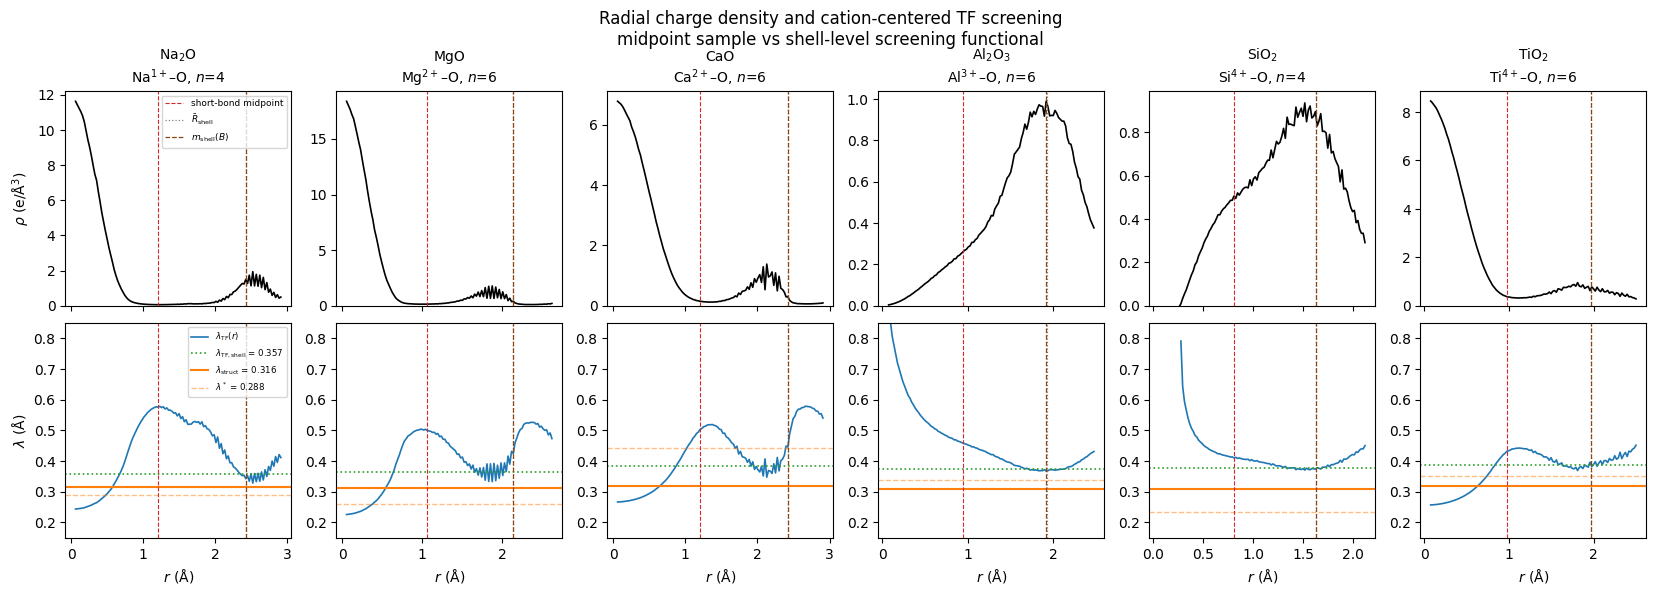

In [4]:
fig, axes = plt.subplots(2, len(benchmarks), figsize=(3.4 * len(benchmarks), 5.8),
                         sharex="col", gridspec_kw={"hspace": 0.08})

for col, b in enumerate(benchmarks):
    ax_rho = axes[0, col]
    ax_lam = axes[1, col]
    r = b["r"]
    mask = b["counts"] > 5

    # --- Top: electron density ---
    ax_rho.plot(r[mask], b["rho"][mask], "k-", lw=1.2)
    ax_rho.axvline(b["r_mid"], color="C3", ls="--", lw=0.8, label="short-bond midpoint")
    ax_rho.axvline(b["r_bar"], color="gray", ls=":", lw=0.9, label=r"$\bar R_\mathrm{shell}$")
    ax_rho.axvline(b["r_weighted"], color="saddlebrown", ls="--", lw=0.9, label=r"$m_\mathrm{shell}(B)$")
    ax_rho.set_ylabel(r"$\rho$ (e/$\mathrm{\AA}^3$)" if col == 0 else "")
    ax_rho.set_title(
        f'{b["name"]}\n{b["cation"]}$^{{{b["z"]}+}}$–O, $n$={b["n"]}',
        fontsize=10,
    )
    ax_rho.set_ylim(bottom=0)
    if col == 0:
        ax_rho.legend(fontsize=6.5, loc="upper right")

    # --- Bottom: screening lengths ---
    lam_tf = b["lam_tf_profile"]
    valid_tf = mask & np.isfinite(lam_tf) & (lam_tf < 1.5)

    ax_lam.plot(r[valid_tf], lam_tf[valid_tf], "C0-", lw=1.2, label=r"$\lambda_\mathrm{TF}(r)$")
    if np.isfinite(b["lam_tf_shell"]):
        ax_lam.axhline(
            b["lam_tf_shell"],
            color="C2",
            ls=":",
            lw=1.2,
            label=rf'$\lambda_\mathrm{{TF,shell}}$ = {b["lam_tf_shell"]:.3f}',
        )
    ax_lam.axhline(
        b["lam_struct"],
        color="C1",
        ls="-",
        lw=1.5,
        label=rf'$\lambda_\mathrm{{struct}}$ = {b["lam_struct"]:.3f}',
    )
    ax_lam.axhline(
        b["lam_star"],
        color="C1",
        ls="--",
        lw=1.0,
        alpha=0.5,
        label=rf'$\lambda^*$ = {b["lam_star"]:.3f}',
    )
    ax_lam.axvline(b["r_mid"], color="C3", ls="--", lw=0.8)
    ax_lam.axvline(b["r_bar"], color="gray", ls=":", lw=0.9)
    ax_lam.axvline(b["r_weighted"], color="saddlebrown", ls="--", lw=0.9)
    ax_lam.set_xlabel(r"$r$ ($\mathrm{\AA}$)")
    ax_lam.set_ylabel(r"$\lambda$ ($\mathrm{\AA}$)" if col == 0 else "")
    ax_lam.set_ylim(0.15, 0.85)
    if col == 0:
        ax_lam.legend(fontsize=6.2, loc="upper right")

fig.suptitle(
    "Radial charge density and cation-centered TF screening\nmidpoint sample vs shell-level screening functional",
    y=1.02,
    fontsize=12,
)
plt.tight_layout()
plt.savefig("../docs/theory/figures/thomas_fermi_radial_profiles.png", dpi=200,
            bbox_inches="tight")
plt.show()


## Figure 2: Parity — Thomas–Fermi vs structure-specific $\lambda$

Left: $\lambda_\mathrm{TF}$ (bond midpoint) vs structure-specific $\lambda$, colored by formal charge $z$.  
Right: ratio $\lambda_\mathrm{TF}/\lambda_\mathrm{struct}$ vs formal charge $z$.

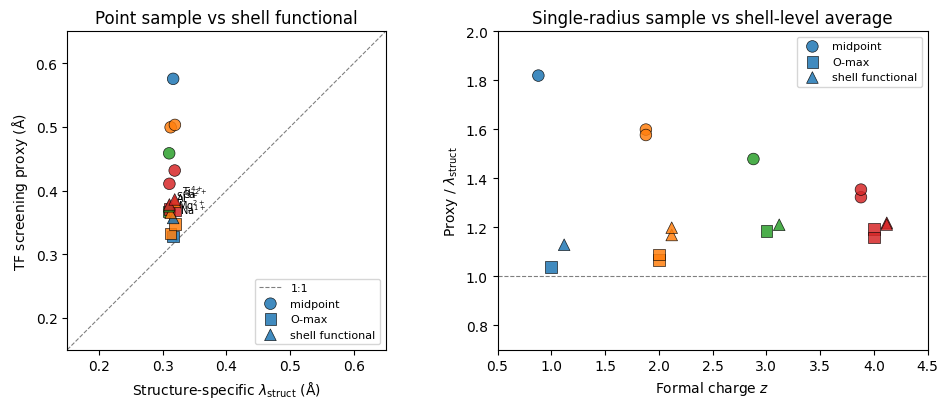

Cation      z  n   Rmin  Rmean   m(B) lam_str lam_mid  lam_om  lam_sh
----------------------------------------------------------------------------------
Na^1+       1  4 2.423 2.423 2.423 0.316   0.575 0.328 0.357
Mg^2+       2  6 2.128 2.128 2.128 0.312   0.499 0.333 0.365
Ca^2+       2  6 2.420 2.420 2.420 0.319   0.503 0.347 0.382
Al^3+       3  6 1.873 1.931 1.922 0.310   0.458 0.367 0.375
Si^4+       4  4 1.626 1.627 1.627 0.310   0.411 0.371 0.378
Ti^4+       4  6 1.949 1.969 1.967 0.319   0.431 0.369 0.386


In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.2))

lam_structs = np.array([b["lam_struct"] for b in benchmarks])
lam_mids = np.array([b["lam_tf_mid"] for b in benchmarks])
lam_omaxs = np.array([b["lam_tf_omax"] for b in benchmarks])
lam_shells = np.array([b["lam_tf_shell"] for b in benchmarks])
zs = np.array([b["z"] for b in benchmarks])
cations = [f'{b["cation"]}$^{{{b["z"]}+}}$' for b in benchmarks]
proxies = [
    ("midpoint", lam_mids, "o"),
    ("O-max", lam_omaxs, "s"),
    ("shell functional", lam_shells, "^"),
]

colors = {1: "C0", 2: "C1", 3: "C2", 4: "C3"}
cs = [colors[z] for z in zs]

# --- Left: parity plot ---
lo, hi = 0.15, 0.65
ax1.plot([lo, hi], [lo, hi], "k--", lw=0.8, alpha=0.5, label="1:1")
for label, yv, marker in proxies:
    ax1.scatter(
        lam_structs,
        yv,
        c=cs,
        s=70,
        zorder=5,
        edgecolors="k",
        lw=0.5,
        marker=marker,
        label=label,
        alpha=0.85,
    )
for i in range(len(benchmarks)):
    ax1.annotate(cations[i], (lam_structs[i], lam_shells[i]),
                 textcoords="offset points", xytext=(5, 3), fontsize=7)
ax1.set_xlabel(r"Structure-specific $\lambda_\mathrm{struct}$ ($\mathrm{\AA}$)")
ax1.set_ylabel(r"TF screening proxy ($\mathrm{\AA}$)")
ax1.set_xlim(lo, hi)
ax1.set_ylim(lo, hi)
ax1.set_aspect("equal")
ax1.legend(fontsize=8)
ax1.set_title("Point sample vs shell functional")

# --- Right: ratio vs z ---
for offset, (label, yv, marker) in zip([-0.12, 0.0, 0.12], proxies):
    ratios = yv / lam_structs
    ax2.scatter(
        zs + offset,
        ratios,
        c=cs,
        s=70,
        zorder=5,
        edgecolors="k",
        lw=0.5,
        marker=marker,
        label=label,
        alpha=0.85,
    )
ax2.axhline(1.0, color="k", ls="--", lw=0.8, alpha=0.5)
ax2.set_xlabel("Formal charge $z$")
ax2.set_ylabel(r"Proxy / $\lambda_\mathrm{struct}$")
ax2.set_xlim(0.5, 4.5)
ax2.set_ylim(0.7, 2.0)
ax2.legend(fontsize=8, loc="upper right")
ax2.set_title(r"Single-radius sample vs shell-level average")

plt.tight_layout()
plt.savefig("../docs/theory/figures/thomas_fermi_parity.png", dpi=200,
            bbox_inches="tight")
plt.show()

# Print summary table
print(
    f'{"Cation":10s} {"z":>2s} {"n":>2s} {"Rmin":>6s} {"Rmean":>6s} {"m(B)":>6s} '
    f'{"lam_str":>7s} {"lam_mid":>7s} {"lam_om":>7s} {"lam_sh":>7s}'
)
print("-" * 82)
for b in benchmarks:
    print(
        f'{b["cation"]}^{b["z"]}+{"":<5s} {b["z"]:2d} {b["n"]:2d} '
        f'{b["r_short"]:.3f} {b["r_bar"]:.3f} {b["r_weighted"]:.3f} '
        f'{b["lam_struct"]:.3f}   {b["lam_tf_mid"]:.3f} '
        f'{b["lam_tf_omax"]:.3f} {b["lam_tf_shell"]:.3f}'
    )


## Results

### Reframing $\lambda_\mathrm{struct}$ as a shell screening scale

The fitted $\lambda_\mathrm{struct}$ is **not** a pointwise screening length at a
single radius. It is a shell-level parameter obtained by re-expressing the fitted
pair $(R_0, B)$ through

$$
B = \lambda_\mathrm{struct}\,(\lambda_\mathrm{struct} + R_0)/R_0 .
$$

A fair DFT-side comparison should therefore average the local TF response over the
oxygen-rich part of the shell, rather than evaluating $\lambda_\mathrm{TF}(r)$ only
at the midpoint or at one radial maximum.

In the notebook we therefore introduce a cation-centered shell proxy
$\lambda_\mathrm{TF,shell}$: a density-weighted **harmonic** mean of
$\lambda_\mathrm{TF}(r)$ across the oxygen-shell window. Later we repeat the same
idea on each bond path, where the shell geometry is explicit.

### Why midpoint comparisons are structurally mismatched

The midpoint sample mixes two different objects:

1. $\lambda_\mathrm{struct}$, which summarizes the whole cation shell.
2. $\lambda_\mathrm{TF}(r_\mathrm{mid})$, which samples one radius on one short bond.

The midpoint is therefore expected to overshoot or undershoot in distorted shells.
The shell functional and the later bond-path functional are better proxies because
they keep the TF comparison at the same “whole-shell” level as the bond-valence fit.


---
## Expanded analysis: canonical binary oxides across the periodic table

Extend the comparison to the canonical selected binary-oxide MID table, then attach
theory fields from the oxide free-energy join where they exist. This keeps the
screening analysis tied to the canonical thermodynamic structures while retaining
species whose shell/path data are usable even when the species-level theory join is
missing.

In [6]:
import csv

def maybe_float(value):
    try:
        return float(value)
    except (TypeError, ValueError):
        return np.nan

# Load the canonical selected oxide table and attach theory fields where available.
with open("../data/processed/thermodynamics/canonical_oxide_mid_table.csv") as f:
    canonical_rows = list(csv.DictReader(f))
with open("../data/processed/thermodynamics/oxide_free_energy_comparison.csv") as f:
    comparison_rows = list(csv.DictReader(f))

comparison_lookup = {
    (r["element"], r["oxide_formula"]): r
    for r in comparison_rows
}

all_oxides = []
for r in canonical_rows:
    if r.get("selected_status") != "fitted":
        continue
    if not r.get("selected_mid") or not r.get("selected_cn"):
        continue
    try:
        R0_fit = float(r["selected_R0"])
        B_fit = float(r["selected_B"])
        z = int(r["selected_oxi_state"])
        cn = int(r["selected_cn"])
    except (ValueError, TypeError):
        continue
    if B_fit <= 0 or R0_fit <= 0:
        continue
    cmp_row = comparison_lookup.get((r["element"], r["oxide_formula"]), {})
    all_oxides.append({
        "element": r["element"],
        "formula": r["oxide_formula"],
        "mpid": r["selected_mid"],
        "z": z, "n": cn,
        "R0_fit": R0_fit, "B_fit": B_fit,
        "R0s": maybe_float(cmp_row.get("theory_R0_star")),
        "Bs": maybe_float(cmp_row.get("theory_B_star")),
        "lam_star": maybe_float(cmp_row.get("screening_lambda_star")),
        "theory_join_available": bool(cmp_row.get("theory_R0_star") and cmp_row.get("theory_B_star")),
    })

print(f"Total canonical binary oxides for analysis: {len(all_oxides)}")

Total canonical binary oxides for analysis: 38


In [7]:
import time
from tqdm import tqdm

with MPRester(API_KEY) as mpr:
    for ox in tqdm(all_oxides, desc="Downloading charge densities"):
        try:
            chgcar = get_chgcar_cached(mpr, ox["mpid"])
            if chgcar is None:
                raise ValueError("No charge density")
        except Exception as e:
            print(f"  SKIP {ox['formula']} ({ox['mpid']}): {e}")
            ox["error"] = str(e)
            time.sleep(2)
            continue

        struct = chgcar.structure
        try:
            cat_idx = next(
                i for i, s in enumerate(struct)
                if ox["element"] in s.species_string
            )
        except StopIteration:
            ox["error"] = f"cation {ox['element']} not found"
            continue

        shell_lengths = collect_oxygen_shell(struct, cat_idx, ox.get("n"))
        if not shell_lengths:
            ox["error"] = "no O neighbors"
            continue

        shell_metrics = boltzmann_shell_metrics(shell_lengths, ox["B_fit"])
        ox["shell_lengths"] = shell_lengths
        ox["r_short"] = shell_metrics["r_min"]
        ox["r_bar"] = shell_metrics["r_mean"]
        ox["r_shell_mean"] = shell_metrics["r_mean"]
        ox["r_shell_max"] = shell_metrics["r_max"]
        ox["r_weighted"] = shell_metrics["r_weighted"]
        ox["shell_entropy"] = shell_metrics["entropy"]
        ox["n_eff_shell"] = shell_metrics["n_eff"]

        # Structure-specific lambda from per-material (R0, B) fit
        R0_fit = ox["R0_fit"]
        B_fit = ox["B_fit"]
        ox["B_struct"] = B_fit

        # Flag fit quality
        flags = []
        if B_fit < 0:
            flags.append("B<0")
        if B_fit > 2:
            flags.append("B>2")
        if R0_fit < 0:
            flags.append("R0<0")
        if R0_fit > 4:
            flags.append("R0>4")
        if abs(B_fit - 0.37) < 0.001:
            flags.append("B=0.37")
        if B_fit >= 0 and B_fit < 0.05:
            flags.append("B~0")
        ox["fit_flags"] = flags
        ox["fit_ok"] = len(flags) == 0
        ox["lam_struct"] = screening_length_from_r0_b(R0_fit, B_fit)

        # Radial profile — store for plotting
        r, rho, cts = radial_charge_profile(
            chgcar,
            cat_idx,
            r_max=ox["r_shell_max"] + 0.5,
            n_bins=120,
        )
        ox["r_profile"] = r
        ox["rho_profile"] = rho
        ox["counts_profile"] = cts
        ox["lam_tf_profile"] = np.array([thomas_fermi_lambda(rr) for rr in rho])

        # Shortest-bond midpoint
        r_mid = 0.5 * ox["r_short"]
        idx_mid = np.argmin(np.abs(r - r_mid))
        ox["r_mid"] = r[idx_mid]
        ox["rho_mid"] = rho[idx_mid]
        ox["lam_tf_mid"] = thomas_fermi_lambda(rho[idx_mid])

        # Oxygen-shell maximum (caution: spherical average only)
        shell_window = (
            (r >= max(0.7 * ox["r_short"], 0.75))
            & (r <= ox["r_shell_max"] + 0.25)
            & (cts > 5)
        )
        if shell_window.any():
            idx_max = np.argmax(rho[shell_window])
            ox["r_omax"] = r[shell_window][idx_max]
            ox["rho_omax"] = rho[shell_window][idx_max]
            ox["lam_tf_omax"] = thomas_fermi_lambda(rho[shell_window][idx_max])
            baseline = np.nanmin(rho[shell_window])
        else:
            ox["r_omax"] = ox["rho_omax"] = ox["lam_tf_omax"] = np.nan
            baseline = None

        # Shell-level TF proxy from the spherical radial profile
        lam_shell, r_shell_eff, rho_shell_eff = effective_lambda_from_profile(
            r,
            ox["lam_tf_profile"],
            rho,
            start=max(0.7 * ox["r_short"], 0.75),
            stop=ox["r_shell_max"] + 0.25,
            baseline=baseline,
        )
        ox["lam_tf_shell"] = lam_shell
        ox["r_tf_shell"] = r_shell_eff
        ox["rho_tf_shell"] = rho_shell_eff

        ox["error"] = None

n_ok = sum(1 for ox in all_oxides if ox.get("error") is None)
n_err = sum(1 for ox in all_oxides if ox.get("error") is not None)
print(f"\nSuccessful: {n_ok}, Failed: {n_err}")
if n_err:
    for ox in all_oxides:
        if ox.get("error"):
            print(f"  {ox['formula']} ({ox['mpid']}): {ox['error']}")


Retrieving MaterialsDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Retrieving MaterialsDoc documents: 100%|██████████| 1/1 [00:00<00:00, 16644.06it/s]

Retrieving CoreTaskDoc documents:   0%|          | 0/14 [00:00<?, ?it/s]

Retrieving CoreTaskDoc documents: 100%|██████████| 14/14 [00:00<00:00, 188811.11it/s]

  SKIP Cr2O3 (mp-19399): No object found: s3://materialsproject-parsed/chgcars/mp-1657015.json.gz


...

  SKIP MnO (mp-1232659): No object found: s3://materialsproject-parsed/chgcars/mp-1286320.json.gz


Retrieving MaterialsDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Retrieving MaterialsDoc documents: 100%|██████████| 1/1 [00:00<00:00, 16644.06it/s]

  SKIP WO3 (mp-2383161): No charge density



Successful: 35, Failed: 3
  Cr2O3 (mp-19399): No object found: s3://materialsproject-parsed/chgcars/mp-1657015.json.gz
  MnO (mp-1232659): No object found: s3://materialsproject-parsed/chgcars/mp-1286320.json.gz
  WO3 (mp-2383161): No charge density


In [8]:
# Filter to successful results
ok = [ox for ox in all_oxides if ox.get("error") is None
      and np.isfinite(ox.get("lam_tf_omax", np.nan))
      and np.isfinite(ox.get("lam_struct", np.nan))
      and ox["lam_struct"] > 0]

print(f"{len(ok)} oxides with valid results\n")

# Summary table
print(f'{"Formula":10s} {"Ion":8s} {"z":>2s} {"n":>2s} {"R_bar":>6s} '
      f'{"lam_str":>7s} {"lam_TF_mid":>10s} {"mid/s":>6s} '
      f'{"lam_TF_Omax":>11s} {"Omax/s":>7s}')
print("-" * 85)
for ox in sorted(ok, key=lambda x: x["z"]):
    r_mid = ox["lam_tf_mid"] / ox["lam_struct"]
    r_omax = ox["lam_tf_omax"] / ox["lam_struct"]
    print(f'{ox["formula"]:10s} {ox["element"]}^{ox["z"]}+{"":<3s} '
          f'{ox["z"]:2d} {ox["n"]:2d} {ox["r_bar"]:.3f} '
          f'{ox["lam_struct"]:.3f}   {ox["lam_tf_mid"]:.3f}      {r_mid:.2f}   '
          f'{ox["lam_tf_omax"]:.3f}       {r_omax:.2f}')

35 oxides with valid results

Formula    Ion       z  n  R_bar lam_str lam_TF_mid  mid/s lam_TF_Omax  Omax/s
-------------------------------------------------------------------------------------
Li2O       Li^1+     1  4 2.017 0.307   0.517      1.68   0.337       1.10
Na2O       Na^1+     1  4 2.423 0.316   0.575      1.82   0.328       1.04
K2O        K^1+     1  4 2.809 0.324   0.567      1.75   0.358       1.11
Rb2O       Rb^1+     1  4 2.978 0.326   0.561      1.72   0.377       1.16
Cs2O       Cs^1+     1  3 2.893 0.327   0.503      1.54   0.447       1.37
Ag2O       Ag^1+     1  2 2.096 0.081   0.424      5.24   0.440       5.44
BeO        Be^2+     2  4 1.656 0.304   0.433      1.43   0.343       1.13
MgO        Mg^2+     2  6 2.128 0.312   0.499      1.60   0.333       1.07
CaO        Ca^2+     2  6 2.420 0.319   0.503      1.58   0.347       1.09
SrO        Sr^2+     2  6 2.603 0.322   0.502      1.56   0.354       1.10
BaO        Ba^2+     2  6 2.807 0.326   0.491      1.51 

## Figure 3: $\lambda_\mathrm{TF}$ at the oxygen density maximum

The radial profile $\rho(r)$ around the cation has a local maximum near $r \approx \bar R$ 
(the M–O bond distance), corresponding to the oxygen electron density peak. Evaluating 
$\lambda_\mathrm{TF}$ at this maximum — rather than at the bond midpoint — may give a 
better estimate because the oxygen electrons are the primary screening agents in ionic oxides.

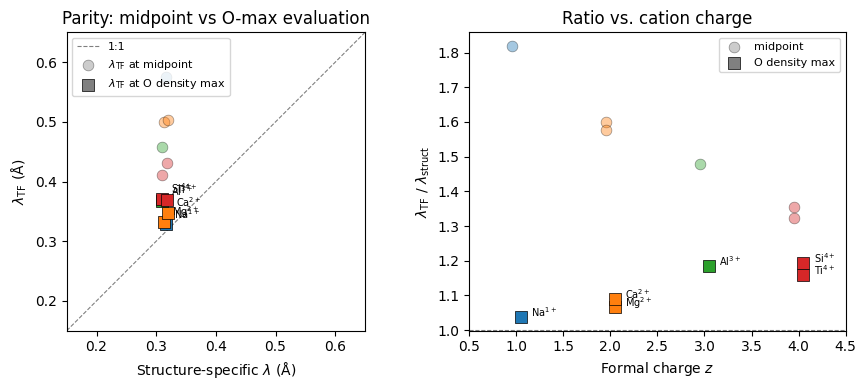


Cation    z lam_str  lam_TF_mid  ratio  rho_Omax r_Omax lam_TF_Omax  ratio
------------------------------------------------------------------------------
Na^1+     1  0.316   0.575      1.82   1.9442 2.521  0.328       1.04
Mg^2+     2  0.312   0.499      1.60   1.7878 1.873  0.333       1.07
Ca^2+     2  0.319   0.503      1.58   1.3820 2.129  0.347       1.09
Al^3+     3  0.310   0.458      1.48   0.9892 1.919  0.367       1.18
Si^4+     4  0.310   0.411      1.32   0.9354 1.517  0.371       1.19
Ti^4+     4  0.319   0.431      1.35   0.9583 1.809  0.369       1.16


In [9]:
# Find the oxygen density maximum (local max of rho beyond 1 A from the cation)
for b in benchmarks:
    r = b["r"]
    rho = b["rho"]
    cts = b["counts"]
    
    # Search for the density maximum beyond 1 A (the oxygen shell)
    mask = (r > 1.0) & (r < b["r_bar"] + 0.3) & (cts > 5)
    if mask.any():
        idx_max = np.argmax(rho[mask])
        r_omax = r[mask][idx_max]
        rho_omax = rho[mask][idx_max]
        lam_tf_omax = thomas_fermi_lambda(rho_omax)
    else:
        r_omax = rho_omax = lam_tf_omax = np.nan
    
    b["r_omax"] = r_omax
    b["rho_omax"] = rho_omax
    b["lam_tf_omax"] = lam_tf_omax

# Parity plot: lambda_TF at O density maximum vs lambda_struct
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4))

lam_structs = np.array([b["lam_struct"] for b in benchmarks])
lam_tf_mids = np.array([b["lam_tf_mid"] for b in benchmarks])
lam_tf_omaxs = np.array([b["lam_tf_omax"] for b in benchmarks])
zs = np.array([b["z"] for b in benchmarks])
cations = [f'{b["cation"]}$^{{{b["z"]}+}}$' for b in benchmarks]
cs = [colors[z] for z in zs]

# --- Left: parity ---
lo, hi = 0.15, 0.65
ax1.plot([lo, hi], [lo, hi], "k--", lw=0.8, alpha=0.5, label="1:1")
for i in range(len(benchmarks)):
    ax1.scatter(lam_structs[i], lam_tf_mids[i], c=cs[i], s=60, marker="o",
                edgecolors="k", lw=0.5, alpha=0.4)
    ax1.scatter(lam_structs[i], lam_tf_omaxs[i], c=cs[i], s=80, marker="s",
                edgecolors="k", lw=0.5, zorder=5)
    ax1.annotate(cations[i], (lam_structs[i], lam_tf_omaxs[i]),
                 textcoords="offset points", xytext=(6, 4), fontsize=7)

ax1.scatter([], [], c="gray", s=60, marker="o", edgecolors="k", lw=0.5, alpha=0.4,
            label=r"$\lambda_\mathrm{TF}$ at midpoint")
ax1.scatter([], [], c="gray", s=80, marker="s", edgecolors="k", lw=0.5,
            label=r"$\lambda_\mathrm{TF}$ at O density max")
ax1.set_xlabel(r"Structure-specific $\lambda$ ($\mathrm{\AA}$)")
ax1.set_ylabel(r"$\lambda_\mathrm{TF}$ ($\mathrm{\AA}$)")
ax1.set_xlim(lo, hi)
ax1.set_ylim(lo, hi)
ax1.set_aspect("equal")
ax1.legend(fontsize=8, loc="upper left")
ax1.set_title("Parity: midpoint vs O-max evaluation")

# --- Right: ratio vs z ---
ratios_mid = lam_tf_mids / lam_structs
ratios_omax = lam_tf_omaxs / lam_structs

for i in range(len(benchmarks)):
    ax2.scatter(zs[i] - 0.05, ratios_mid[i], c=cs[i], s=60, marker="o",
                edgecolors="k", lw=0.5, alpha=0.4)
    ax2.scatter(zs[i] + 0.05, ratios_omax[i], c=cs[i], s=80, marker="s",
                edgecolors="k", lw=0.5, zorder=5)
    ax2.annotate(cations[i], (zs[i] + 0.1, ratios_omax[i]),
                 textcoords="offset points", xytext=(4, 0), fontsize=7)

ax2.scatter([], [], c="gray", s=60, marker="o", edgecolors="k", lw=0.5, alpha=0.4,
            label="midpoint")
ax2.scatter([], [], c="gray", s=80, marker="s", edgecolors="k", lw=0.5,
            label="O density max")
ax2.axhline(1.0, color="k", ls="--", lw=0.8, alpha=0.5)
ax2.set_xlabel("Formal charge $z$")
ax2.set_ylabel(r"$\lambda_\mathrm{TF}$ / $\lambda_\mathrm{struct}$")
ax2.set_xlim(0.5, 4.5)
ax2.legend(fontsize=8, loc="upper right")
ax2.set_title("Ratio vs. cation charge")

plt.tight_layout()
plt.savefig("../docs/theory/figures/thomas_fermi_parity.png", dpi=200,
            bbox_inches="tight")
plt.show()

# Summary table
print(f'\n{"Cation":8s} {"z":>2s} {"lam_str":>7s}  {"lam_TF_mid":>10s} {"ratio":>6s}  '
      f'{"rho_Omax":>8s} {"r_Omax":>6s} {"lam_TF_Omax":>11s} {"ratio":>6s}')
print("-" * 78)
for b in benchmarks:
    r1 = b["lam_tf_mid"] / b["lam_struct"]
    r2 = b["lam_tf_omax"] / b["lam_struct"]
    print(f'{b["cation"]}^{b["z"]}+{"":<3s} {b["z"]:2d}  {b["lam_struct"]:.3f}   '
          f'{b["lam_tf_mid"]:.3f}      {r1:.2f}   '
          f'{b["rho_omax"]:.4f} {b["r_omax"]:.3f}  '
          f'{b["lam_tf_omax"]:.3f}       {r2:.2f}')

In [10]:
# ---- Fix: correct minimum-image displacement for non-orthogonal cells ----
# The bug: delta -= np.round(delta) wraps each fractional component independently,
# but in non-orthogonal cells (e.g., MgO primitive with 60 deg angles) the minimum
# Cartesian distance requires a different image. For MgO, the naive wrapping gave
# (0.5, 0.5, 0.5) = 3.69 A instead of the correct (0.5, -0.5, -0.5) = 2.13 A.
#
# Fix: check all 27 image translations and pick the shortest.

def sample_density_along_bond_v2(chgcar, site_i, site_j, n_pts=100):
    struct = chgcar.structure
    lattice = struct.lattice
    data = chgcar.data["total"]
    nx, ny, nz = data.shape
    vol = lattice.volume
    frac_i = struct[site_i].frac_coords
    frac_j = struct[site_j].frac_coords

    # Find correct nearest-image displacement (brute-force 27 images)
    best_delta, best_r = None, np.inf
    for da in [-1, 0, 1]:
        for db in [-1, 0, 1]:
            for dc in [-1, 0, 1]:
                delta = frac_j + np.array([da, db, dc]) - frac_i
                r = np.linalg.norm(lattice.get_cartesian_coords(delta))
                if 0.01 < r < best_r:
                    best_r, best_delta = r, delta

    distances = np.linspace(0, best_r, n_pts)
    densities = np.zeros(n_pts)
    for k in range(n_pts):
        t = k / (n_pts - 1)
        frac_pt = (frac_i + t * best_delta) % 1.0
        fx, fy, fz = frac_pt[0] * nx, frac_pt[1] * ny, frac_pt[2] * nz
        ix0, iy0, iz0 = int(fx) % nx, int(fy) % ny, int(fz) % nz
        ix1, iy1, iz1 = (ix0 + 1) % nx, (iy0 + 1) % ny, (iz0 + 1) % nz
        dx, dy, dz = fx - int(fx), fy - int(fy), fz - int(fz)
        c00 = data[ix0, iy0, iz0] * (1 - dx) + data[ix1, iy0, iz0] * dx
        c01 = data[ix0, iy0, iz1] * (1 - dx) + data[ix1, iy0, iz1] * dx
        c10 = data[ix0, iy1, iz0] * (1 - dx) + data[ix1, iy1, iz0] * dx
        c11 = data[ix0, iy1, iz1] * (1 - dx) + data[ix1, iy1, iz1] * dx
        c0 = c00 * (1 - dy) + c10 * dy
        c1 = c01 * (1 - dy) + c11 * dy
        densities[k] = (c0 * (1 - dz) + c1 * dz) / vol
    return distances, densities, best_r

def oxygen_side_match_radius(
    dist,
    lam_tf,
    lam_struct,
    bcp_r,
    r_ij,
    *,
    stop_frac=0.95,
    closest_above_abs_tol=0.05,
    closest_above_rel_tol=0.20,
):
    if not np.isfinite(lam_struct) or lam_struct <= 0 or not np.isfinite(bcp_r):
        return np.nan, None, np.nan

    valid = np.isfinite(lam_tf) & (dist >= bcp_r) & (dist < r_ij * stop_frac)
    d_v = dist[valid]
    lam_v = lam_tf[valid]
    if len(d_v) == 0:
        return np.nan, None, np.nan

    diff_v = lam_v - lam_struct
    for i in range(len(diff_v) - 1):
        if diff_v[i] == 0:
            return d_v[i], "crossing", 0.0
        if diff_v[i] * diff_v[i + 1] < 0:
            rc = d_v[i] + (d_v[i + 1] - d_v[i]) * abs(diff_v[i]) / (
                abs(diff_v[i]) + abs(diff_v[i + 1])
            )
            return rc, "crossing", 0.0

    above = diff_v >= 0
    if above.any():
        idx = np.argmin(np.where(above, diff_v, np.inf))
        closest_excess = diff_v[idx]
        tol = max(closest_above_abs_tol, closest_above_rel_tol * lam_struct)
        if np.isfinite(closest_excess) and closest_excess <= tol:
            return d_v[idx], "closest_above", closest_excess

    return np.nan, None, np.nan

# Re-run for all oxides
with MPRester(API_KEY) as mpr:
    for ox in tqdm(all_oxides, desc="Bond-path v2"):
        if ox.get("error") is not None:
            continue
        try:
            chgcar = get_chgcar_cached(mpr, ox["mpid"])
            if chgcar is None:
                raise ValueError("No charge density")
        except Exception:
            continue
        struct = chgcar.structure
        try:
            cat_idx = next(i for i, s in enumerate(struct) if ox["element"] in s.species_string)
        except StopIteration:
            continue

        lam_s = ox.get("lam_struct", np.nan)
        bonds_v2 = []
        for j in range(len(struct)):
            if "O" not in struct[j].species_string:
                continue
            r_ij = struct.get_distance(cat_idx, j)
            if r_ij > 3.5:
                continue
            dist, rho, r_total = sample_density_along_bond_v2(chgcar, cat_idx, j, n_pts=100)
            lam_tf = np.array([thomas_fermi_lambda(rr) for rr in rho])
            path_ok = abs(r_total - r_ij) < 0.05

            # BCP proxy: interior density minimum along the straight bond path
            interior = (dist > r_ij * 0.15) & (dist < r_ij * 0.85) & np.isfinite(rho)
            if interior.any():
                idx_min = np.argmin(rho[interior])
                bcp_r = dist[interior][idx_min]
                bcp_rho = rho[interior][idx_min]
                bcp_lam = thomas_fermi_lambda(bcp_rho)
            else:
                bcp_r = bcp_rho = bcp_lam = np.nan

            # O-max before the nuclear cusp
            near_O = (dist > r_ij * 0.6) & (dist < r_ij * 0.93)
            if near_O.any():
                idx_max = np.argmax(rho[near_O])
                omax_r = dist[near_O][idx_max]
                omax_rho = rho[near_O][idx_max]
                omax_lam = thomas_fermi_lambda(omax_rho)
            else:
                omax_r = omax_rho = omax_lam = np.nan

            # O-side shell functional: excess-density weighted harmonic mean
            if np.isfinite(bcp_r):
                lam_eff, r_eff, rho_eff = effective_lambda_from_profile(
                    dist,
                    lam_tf,
                    rho,
                    start=bcp_r,
                    stop=min(r_ij * 0.93, r_total),
                    baseline=bcp_rho,
                )
            else:
                lam_eff = r_eff = rho_eff = np.nan

            # Oxygen-side crossing or, if the profile stays above lambda_struct,
            # the closest-above point when it remains near the shell value.
            r_cross, r_cross_method, lam_excess = oxygen_side_match_radius(
                dist,
                lam_tf,
                lam_s,
                bcp_r,
                r_ij,
            )

            bonds_v2.append(
                {
                    "j": j,
                    "r_ij": r_ij,
                    "r_total": r_total,
                    "path_ok": path_ok,
                    "dist": dist,
                    "rho": rho,
                    "lam_tf": lam_tf,
                    "bcp_r": bcp_r,
                    "bcp_rho": bcp_rho,
                    "bcp_lam": bcp_lam,
                    "omax_r": omax_r,
                    "omax_rho": omax_rho,
                    "omax_lam": omax_lam,
                    "lam_eff": lam_eff,
                    "r_eff": r_eff,
                    "rho_eff": rho_eff,
                    "r_cross": r_cross,
                    "r_cross_method": r_cross_method,
                    "lam_excess": lam_excess,
                    "frac_cross": r_cross / r_ij if np.isfinite(r_cross) else np.nan,
                }
            )

        ox["bonds_v2"] = bonds_v2
        bcp_ls = [b["bcp_lam"] for b in bonds_v2 if np.isfinite(b["bcp_lam"])]
        omax_ls = [b["omax_lam"] for b in bonds_v2 if np.isfinite(b["omax_lam"])]
        eff_ls = [b["lam_eff"] for b in bonds_v2 if np.isfinite(b["lam_eff"])]
        eff_rs = [b["r_eff"] for b in bonds_v2 if np.isfinite(b["r_eff"])]
        eff_rhos = [b["rho_eff"] for b in bonds_v2 if np.isfinite(b["rho_eff"])]
        cross_fs = [b["frac_cross"] for b in bonds_v2 if np.isfinite(b["frac_cross"])]
        ox["v2_bcp_lam"] = np.mean(bcp_ls) if bcp_ls else np.nan
        ox["v2_omax_lam"] = np.mean(omax_ls) if omax_ls else np.nan
        ox["v2_eff_lam"] = np.mean(eff_ls) if eff_ls else np.nan
        ox["v2_eff_r"] = np.mean(eff_rs) if eff_rs else np.nan
        ox["v2_eff_rho"] = np.mean(eff_rhos) if eff_rhos else np.nan
        ox["v2_frac_cross"] = np.mean(cross_fs) if cross_fs else np.nan
        ox["v2_n_bonds"] = len(bonds_v2)
        ox["v2_paths_ok"] = sum(b["path_ok"] for b in bonds_v2)

n_ok = sum(1 for ox in all_oxides if "bonds_v2" in ox)
n_match = sum(ox.get("v2_paths_ok", 0) for ox in all_oxides if "bonds_v2" in ox)
n_total = sum(ox.get("v2_n_bonds", 0) for ox in all_oxides if "bonds_v2" in ox)
print(f"Done: {n_ok} oxides, {n_match}/{n_total} bond paths match get_distance")


Bond-path v2:   0%|          | 0/38 [00:00<?, ?it/s]

Bond-path v2:  92%|█████████▏| 35/38 [00:00<00:00, 332.49it/s]

Bond-path v2: 100%|██████████| 38/38 [00:00<00:00, 294.50it/s]

Done: 35 oxides, 117/117 bond paths match get_distance


35 oxides

Formula    Ion       z  Rmean   m(B)  lam_s sph_sh bp_eff  bp_Om  bp_BCP
--------------------------------------------------------------------------------------
Ag2O       Ag^1+     1  2.096  2.096  0.081  0.452  0.282  0.262   0.403
Cs2O       Cs^1+     1  2.893  2.893  0.327  0.473  0.292  0.265   0.494
K2O        K^1+     1  2.809  2.809  0.324  0.382  0.293  0.265   0.522
Li2O       Li^1+     1  2.017  2.017  0.307  0.362  0.286  0.262   0.475
Na2O       Na^1+     1  2.423  2.423  0.316  0.357  0.290  0.263   0.512
Rb2O       Rb^1+     1  2.978  2.978  0.326  0.397  0.294  0.266   0.528
BaO        Ba^2+     2  2.807  2.807  0.326  0.401  0.291  0.265   0.483
BeO        Be^2+     2  1.656  1.656  0.304  0.363  0.279  0.260   0.395
CaO        Ca^2+     2  2.420  2.420  0.319  0.382  0.287  0.263   0.463
CoO        Co^2+     2  1.991  1.991  0.406  0.404  0.282  0.262   0.409
CuO        Cu^2+     2  1.955  1.955  0.330  0.398  0.281  0.262   0.395
MgO        Mg^2+     2  2.1

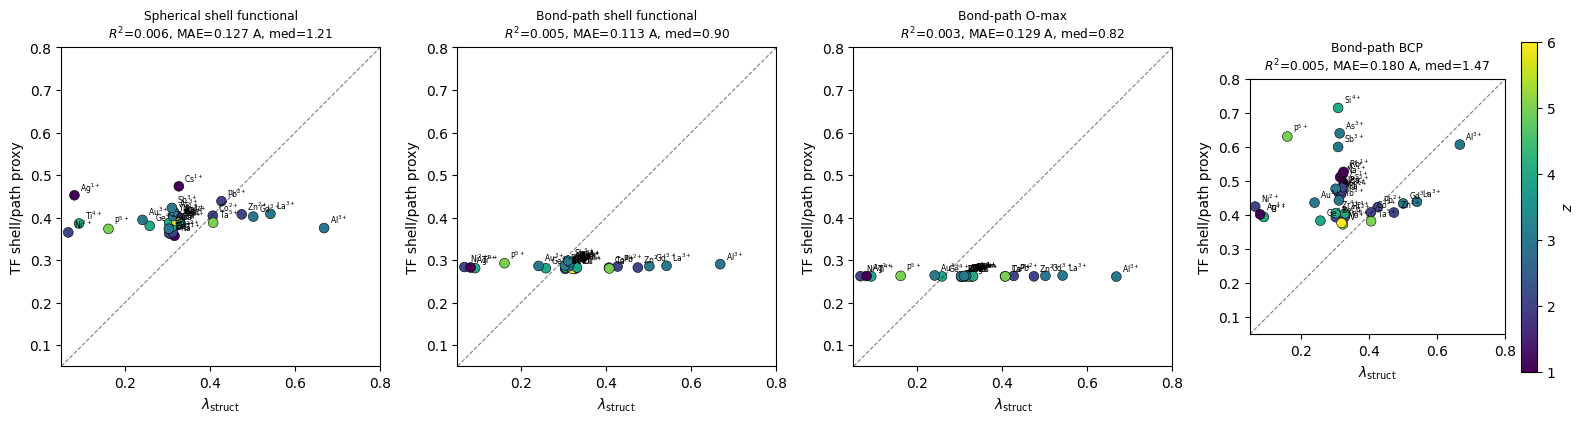

In [11]:
# Results: corrected bond-path vs spherical average
bp2 = [
    ox for ox in all_oxides
    if "bonds_v2" in ox
    and np.isfinite(ox.get("lam_struct", np.nan))
    and ox.get("lam_struct", 0) > 0
    and np.isfinite(ox.get("v2_eff_lam", np.nan))
]

print(f"{len(bp2)} oxides\n")
print(
    f'{"Formula":10s} {"Ion":8s} {"z":>2s} {"Rmean":>6s} {"m(B)":>6s} {"lam_s":>6s} '
    f'{"sph_sh":>6s} {"bp_eff":>6s} {"bp_Om":>6s} {"bp_BCP":>7s}'
)
print("-" * 86)
for ox in sorted(bp2, key=lambda x: (x["z"], x["element"])):
    print(
        f'{ox["formula"]:10s} {ox["element"]}^{ox["z"]}+{"":<3s} {ox["z"]:2d} '
        f'{ox["r_bar"]:6.3f} {ox["r_weighted"]:6.3f} {ox["lam_struct"]:6.3f} '
        f'{ox.get("lam_tf_shell", np.nan):6.3f} {ox["v2_eff_lam"]:6.3f} '
        f'{ox["v2_omax_lam"]:6.3f} {ox.get("v2_bcp_lam", np.nan):7.3f}'
    )

# Parity
fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
lam_s_a = np.array([ox["lam_struct"] for ox in bp2])
sph_shell_a = np.array([ox.get("lam_tf_shell", np.nan) for ox in bp2])
bpe_a = np.array([ox["v2_eff_lam"] for ox in bp2])
bpo_a = np.array([ox["v2_omax_lam"] for ox in bp2])
bpb_a = np.array([ox.get("v2_bcp_lam", np.nan) for ox in bp2])
zv = np.array([ox["z"] for ox in bp2])
labs = [f'{ox["element"]}$^{{{ox["z"]}+}}$' for ox in bp2]
cmap = plt.cm.viridis
norm_c = plt.Normalize(1, 6)
lo, hi = 0.05, 0.8

for ax, yv, title in [
    (axes[0], sph_shell_a, "Spherical shell functional"),
    (axes[1], bpe_a, "Bond-path shell functional"),
    (axes[2], bpo_a, "Bond-path O-max"),
    (axes[3], bpb_a, "Bond-path BCP"),
]:
    m = np.isfinite(yv)
    ax.plot([lo, hi], [lo, hi], "k--", lw=0.8, alpha=0.5)
    sc = ax.scatter(
        lam_s_a[m],
        yv[m],
        c=zv[m],
        cmap=cmap,
        norm=norm_c,
        s=50,
        edgecolors="k",
        lw=0.4,
    )
    for i in range(len(bp2)):
        if m[i]:
            ax.annotate(labs[i], (lam_s_a[i], yv[i]), textcoords="offset points",
                        xytext=(4, 3), fontsize=5.5)
    r2 = np.corrcoef(lam_s_a[m], yv[m])[0, 1] ** 2 if m.sum() > 1 else np.nan
    mae = np.mean(np.abs(yv[m] - lam_s_a[m])) if m.sum() else np.nan
    med = np.median(yv[m] / lam_s_a[m]) if m.sum() else np.nan
    ax.set_title(f"{title}\n$R^2$={r2:.3f}, MAE={mae:.3f} A, med={med:.2f}", fontsize=8.8)
    ax.set_xlabel(r"$\lambda_\mathrm{struct}$")
    ax.set_ylabel(r"TF shell/path proxy")
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect("equal")

plt.colorbar(sc, ax=axes[-1], label="$z$", shrink=0.8)
plt.tight_layout()
plt.savefig("../docs/theory/figures/thomas_fermi_bond_path_v2.png", dpi=200, bbox_inches="tight")
plt.show()


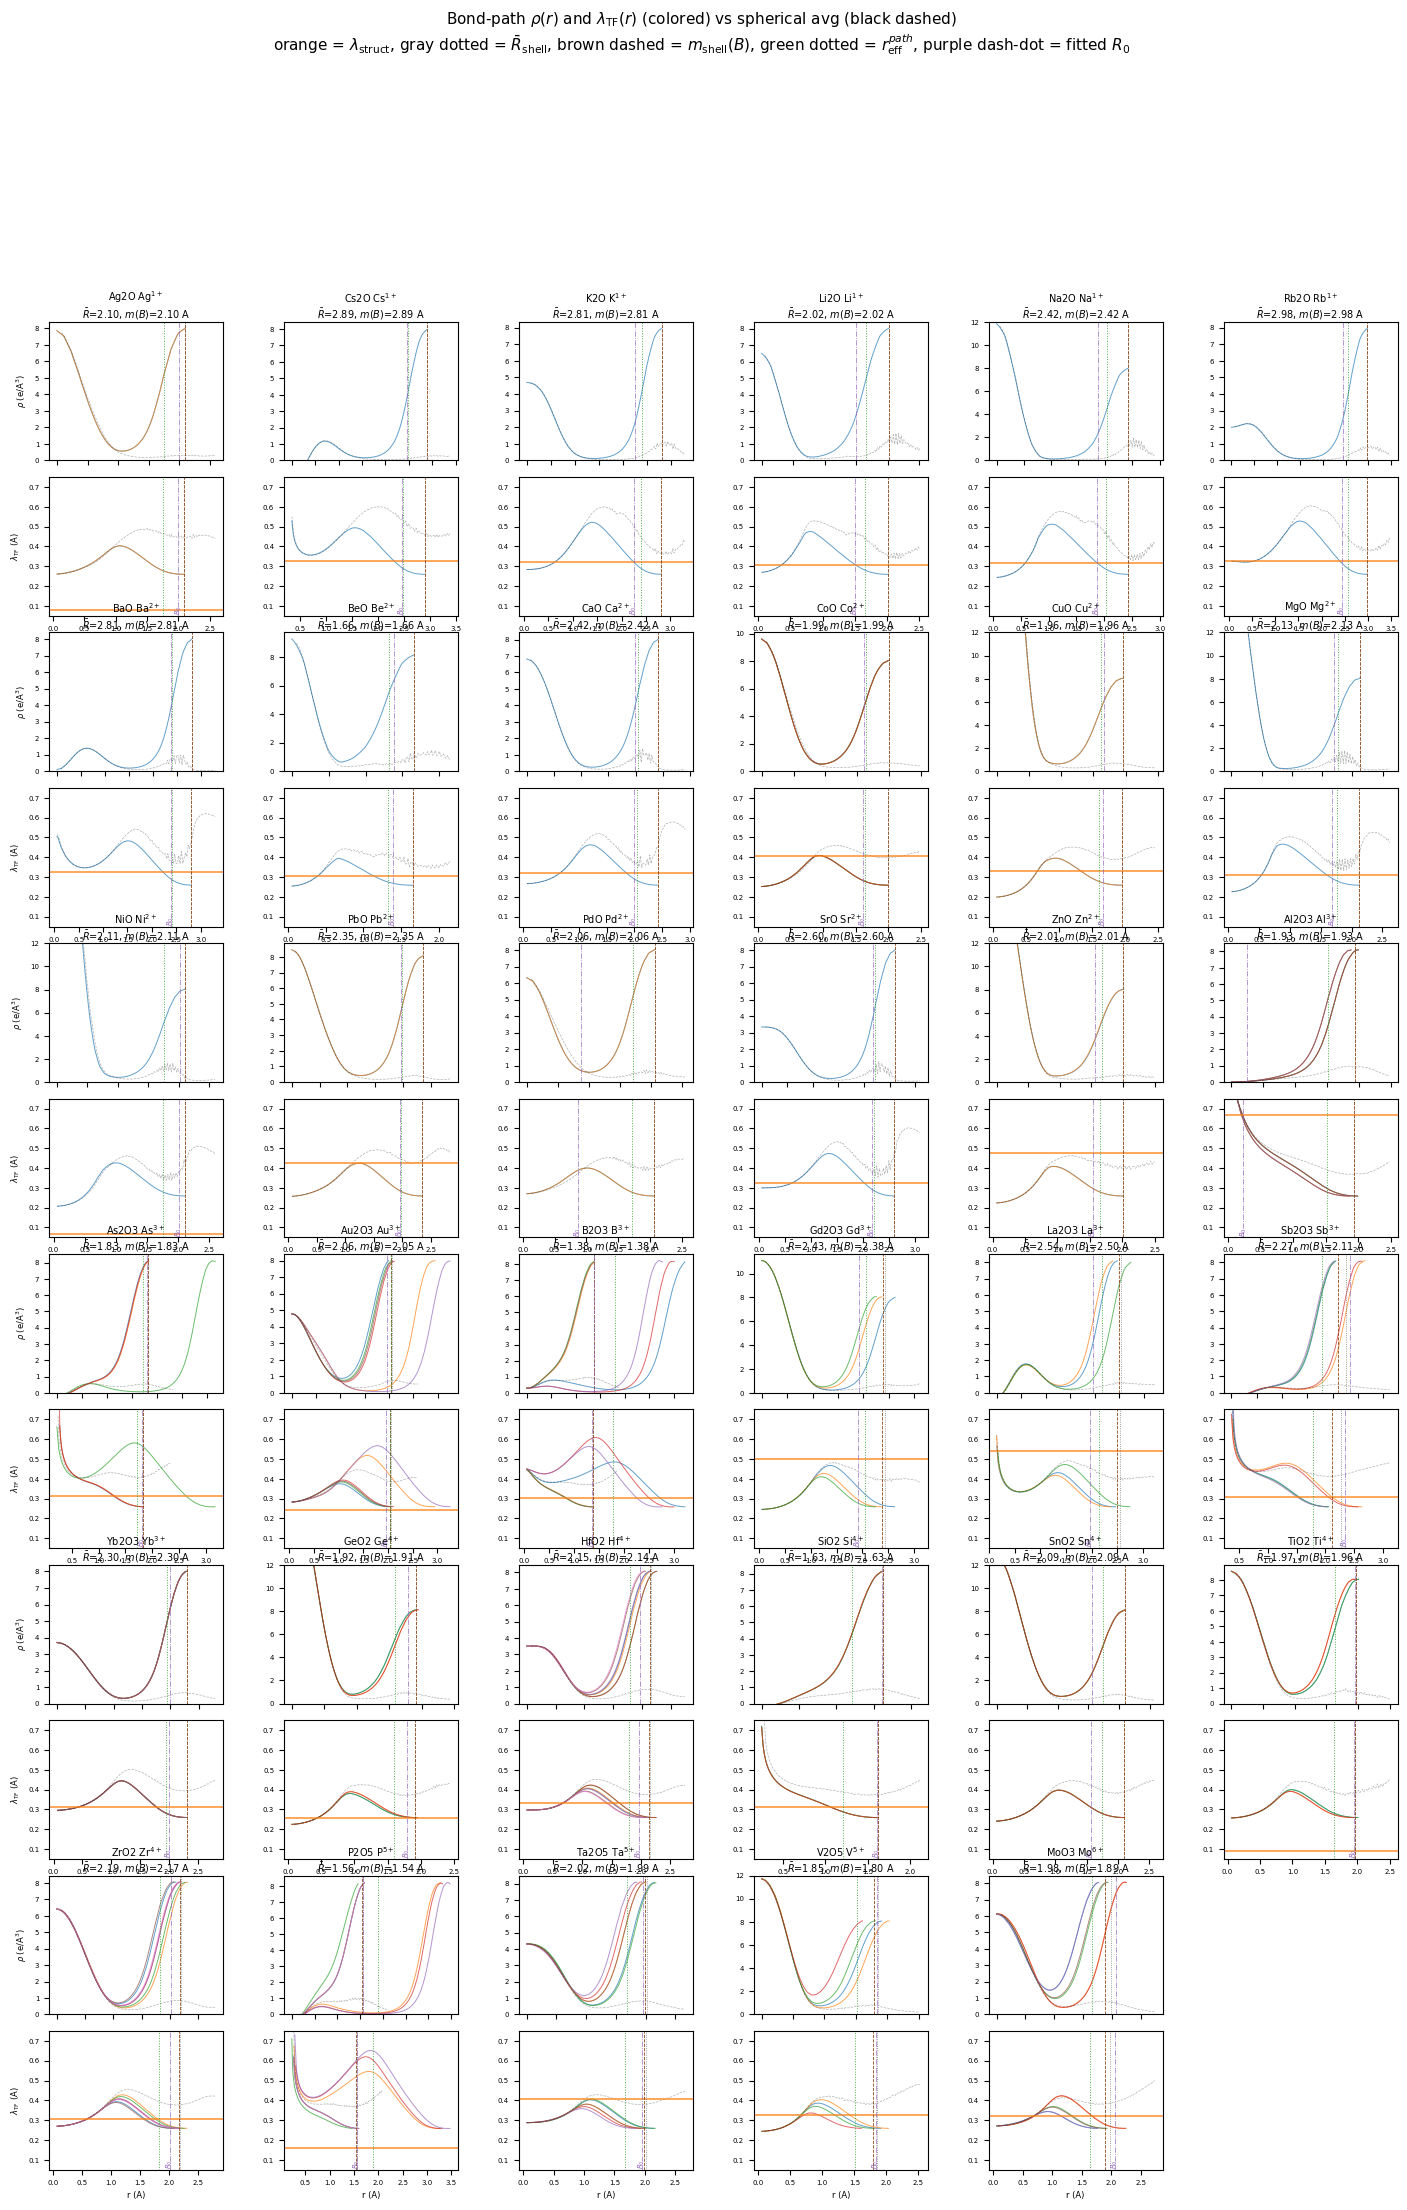

In [12]:
# Bond-path density and lambda_TF profiles for all oxides (corrected min-image)
plot_ox = sorted([ox for ox in all_oxides if "bonds_v2" in ox and ox.get("error") is None],
                 key=lambda x: (x["z"], x["element"]))

ncols = 6
nrows_per = 2  # rho + lambda_TF per oxide
n = len(plot_ox)
nrow_groups = int(np.ceil(n / ncols))
total_rows = nrow_groups * nrows_per

fig, axes = plt.subplots(
    total_rows,
    ncols,
    figsize=(2.9 * ncols, 2.0 * total_rows),
    gridspec_kw={"hspace": 0.12, "wspace": 0.35},
)

for idx, ox in enumerate(plot_ox):
    col = idx % ncols
    row_group = idx // ncols
    ax_rho = axes[row_group * nrows_per, col]
    ax_lam = axes[row_group * nrows_per + 1, col]

    lam_s = ox.get("lam_struct", np.nan)
    r0_fit = ox.get("R0_fit", np.nan)
    r_bar = ox.get("r_bar", np.nan)
    r_weighted = ox.get("r_weighted", np.nan)
    r_eff = ox.get("v2_eff_r", np.nan)

    # --- Top: density along each bond path ---
    for bond in ox["bonds_v2"]:
        d, rho = bond["dist"], bond["rho"]
        ax_rho.plot(d, rho, lw=0.7, alpha=0.7)
    if "r_profile" in ox:
        m = ox["counts_profile"] > 5
        ax_rho.plot(ox["r_profile"][m], ox["rho_profile"][m], "k--", lw=0.5, alpha=0.3)
    if np.isfinite(r_bar):
        ax_rho.axvline(r_bar, color="gray", ls=":", lw=0.6)
    if np.isfinite(r_weighted):
        ax_rho.axvline(r_weighted, color="saddlebrown", ls="--", lw=0.6)
    if np.isfinite(r_eff):
        ax_rho.axvline(r_eff, color="C2", ls=":", lw=0.7, alpha=0.85)
    if np.isfinite(r0_fit) and r0_fit > 0:
        ax_rho.axvline(r0_fit, color="C4", ls="-.", lw=0.6, alpha=0.8)
    ax_rho.set_ylim(bottom=0, top=min(12, max(ax_rho.get_ylim()[1], 2)))
    ax_rho.set_title(
        f'{ox["formula"]} {ox["element"]}$^{{{ox["z"]}+}}$\n'
        f'$\\bar R$={ox.get("r_bar", np.nan):.2f}, $m(B)$={ox.get("r_weighted", np.nan):.2f} A',
        fontsize=7,
        pad=2,
    )
    ax_rho.tick_params(labelsize=5)
    ax_rho.set_xticklabels([])
    if col == 0:
        ax_rho.set_ylabel(r"$\rho$ (e/A$^3$)", fontsize=6)

    # --- Bottom: lambda_TF along each bond path ---
    for bond in ox["bonds_v2"]:
        d = bond["dist"]
        lam_tf = bond["lam_tf"]
        valid = np.isfinite(lam_tf) & (lam_tf < 1.0) & (d > 0.05)
        ax_lam.plot(d[valid], lam_tf[valid], lw=0.7, alpha=0.7)
    if "r_profile" in ox and "lam_tf_profile" in ox:
        lam_sph = ox["lam_tf_profile"]
        m = (ox["counts_profile"] > 5) & np.isfinite(lam_sph) & (lam_sph < 1.0)
        ax_lam.plot(ox["r_profile"][m], lam_sph[m], "k--", lw=0.5, alpha=0.3)
    if np.isfinite(lam_s) and lam_s > 0:
        ax_lam.axhline(lam_s, color="C1", ls="-", lw=1.2, alpha=0.8)
    if np.isfinite(r_bar):
        ax_lam.axvline(r_bar, color="gray", ls=":", lw=0.6)
    if np.isfinite(r_weighted):
        ax_lam.axvline(r_weighted, color="saddlebrown", ls="--", lw=0.6)
    if np.isfinite(r_eff):
        ax_lam.axvline(r_eff, color="C2", ls=":", lw=0.7, alpha=0.85)
    if np.isfinite(r0_fit) and r0_fit > 0:
        ax_lam.axvline(r0_fit, color="C4", ls="-.", lw=0.6, alpha=0.8)
        ax_lam.text(r0_fit, 0.055, r"$R_0$", color="C4", fontsize=5,
                    rotation=90, ha="center", va="bottom")
    ax_lam.set_ylim(0.05, 0.75)
    ax_lam.tick_params(labelsize=5)
    if col == 0:
        ax_lam.set_ylabel(r"$\lambda_\mathrm{TF}$ (A)", fontsize=6)
    if row_group == nrow_groups - 1:
        ax_lam.set_xlabel("r (A)", fontsize=6)

# Hide unused axes
for idx in range(n, nrow_groups * ncols):
    col = idx % ncols
    row_group = idx // ncols
    axes[row_group * nrows_per, col].set_visible(False)
    axes[row_group * nrows_per + 1, col].set_visible(False)

fig.suptitle(
    r"Bond-path $\rho(r)$ and $\lambda_\mathrm{TF}(r)$ (colored) vs spherical avg (black dashed)"
    "\norange = $\\lambda_\\mathrm{struct}$, gray dotted = $\\bar R_\\mathrm{shell}$, "
    "brown dashed = $m_\\mathrm{shell}(B)$, green dotted = $r_\\mathrm{eff}^{path}$, "
    "purple dash-dot = fitted $R_0$",
    fontsize=11,
    y=1.01,
)
plt.savefig("../docs/theory/figures/thomas_fermi_bond_paths_v2_all.png",
            dpi=150, bbox_inches="tight")
plt.show()


---
## Interpreting $\lambda_\mathrm{struct}$ through path averages and crossing radii

Along each M--O bond path, the local $\lambda_\mathrm{TF}(r)$ rises from the cation
core, reaches a minimum-density / maximum-screening turning point near the bond
center, and then evolves into the oxygen-side density reservoir. This notebook now
tracks **two distinct crossing-based observables** and keeps them separate:

1. **Bond-path shell functional** $\lambda_\mathrm{TF,path}$: an excess-density
   weighted harmonic mean of $\lambda_\mathrm{TF}(r)$ from the BCP proxy out to
   the oxygen-side pre-cusp region.
2. **Shell-mean O-side match radius** $\langle r^* \rangle_\mathrm{bond}$: the
   mean over all bond-path O-side solutions of
   $\lambda_\mathrm{TF}(r)=\lambda_\mathrm{struct}$ within one oxide.
3. **Shortest-bond O-side match radius** $r^*_{\mathrm{short}}$: the match radius
   on the shortest M--O bond, used later in the entropy-corrected family analysis.

If the oxygen-side profile never crosses but stays above $\lambda_\mathrm{struct}$
and comes close, we retain the closest-above point as a **near-crossing surrogate**.
Those points are explicitly flagged downstream and should be interpreted as
approximate path matches rather than exact solutions of
$\lambda_\mathrm{TF}(r)=\lambda_\mathrm{struct}$.

The shell-mean quantity $\langle r^* \rangle_\mathrm{bond}$ is therefore a broad
path-versus-shell diagnostic, whereas the later corrected quantity
$r^*_{\mathrm{TF,corr}} = r^*_{\mathrm{short}} (n/n_\mathrm{eff})^{1/6}$ is the
more targeted DFT-side proxy for the representative shell radius entering the
manuscript derivation.


Formula    Ion       z  Rmean   m(B) R0_fit  r_eff   <r*>  r*/R0  r_eff/mB   mode
-----------------------------------------------------------------------------------------------------
Cs2O       Cs^1+     1  2.893  2.893  2.452  2.485  2.308   0.94      0.86  exact
K2O        K^1+     1  2.809  2.809  2.260  2.399  2.239   0.99      0.85  exact
Li2O       Li^1+     1  2.017  2.017  1.502  1.652  1.507   1.00      0.82  exact
Na2O       Na^1+     1  2.423  2.423  1.862  2.031  1.876   1.01      0.84  exact
Rb2O       Rb^1+     1  2.978  2.978  2.435  2.558  2.393   0.98      0.86  exact
BaO        Ba^2+     2  2.807  2.807  2.384  2.405  2.226   0.93      0.86  exact
BeO        Be^2+     2  1.656  1.656  1.388  1.324  1.146   0.83      0.80  exact
CaO        Ca^2+     2  2.420  2.420  1.997  2.040  1.861   0.93      0.84  exact
CoO        Co^2+     2  1.991  1.991  1.611  1.645  0.992   0.62      0.83  exact
CuO        Cu^2+     2  1.955  1.955  1.662  1.613  1.336   0.80      0.83  exa

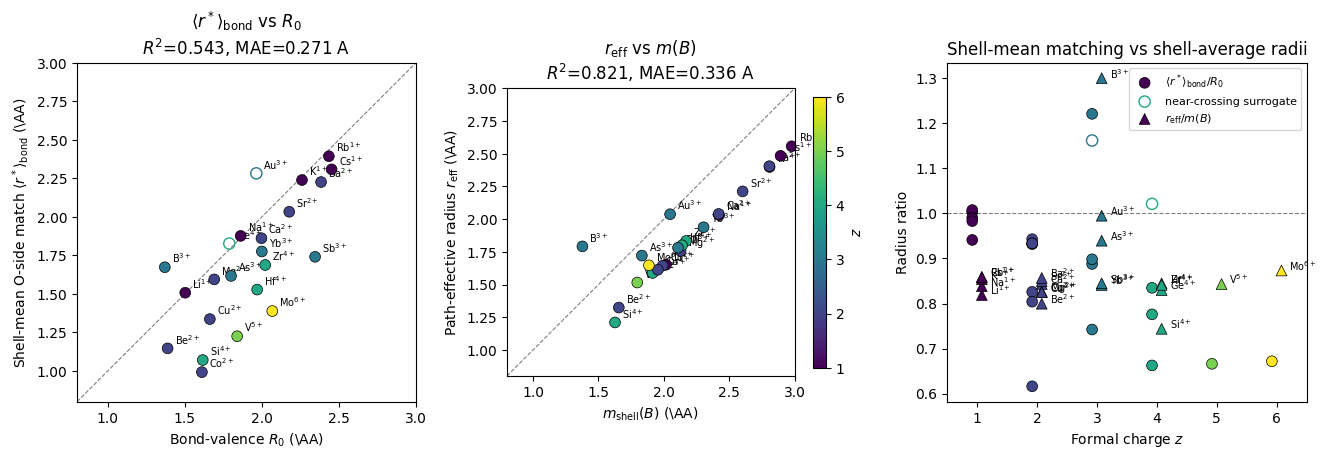


All-species mean <r*>/R0 = 0.89 +/- 0.15
All-species mean r_eff/m(B) = 0.87 +/- 0.10
z=1: <r*>/R0 = 0.99 +/- 0.02, r_eff/m(B) = 0.85 +/- 0.02 (n=5)
z=2: <r*>/R0 = 0.86 +/- 0.11, r_eff/m(B) = 0.83 +/- 0.02 (n=7)
z=3: <r*>/R0 = 0.98 +/- 0.18, r_eff/m(B) = 0.98 +/- 0.17 (n=5)
z=4: <r*>/R0 = 0.82 +/- 0.13, r_eff/m(B) = 0.81 +/- 0.04 (n=4)
z=5: <r*>/R0 = 0.67 +/- 0.00, r_eff/m(B) = 0.84 +/- 0.00 (n=1)
z=6: <r*>/R0 = 0.67 +/- 0.00, r_eff/m(B) = 0.87 +/- 0.00 (n=1)


In [13]:
# Find the O-side shell-mean match radius <r*>_bond where lambda_TF = lambda_struct
# along each bond path and compare it to both R0 and the B-weighted shell radius m(B).

all_crossing_data = []

for ox in all_oxides:
    if "bonds_v2" not in ox or ox.get("error") is not None:
        continue
    lam_s = ox.get("lam_struct", np.nan)
    if not np.isfinite(lam_s) or lam_s <= 0:
        continue

    crossings_per_bond = []
    for bond in ox["bonds_v2"]:
        d, lam_tf = bond["dist"], bond["lam_tf"]
        r_ij = bond["r_ij"]

        # Find the first oxygen-side crossing, or the closest-above match when the
        # profile remains just above lambda_struct.
        bcp_r = bond.get("bcp_r", np.nan)
        if not np.isfinite(bcp_r):
            continue
        rc, rc_method, rc_excess = oxygen_side_match_radius(
            d,
            lam_tf,
            lam_s,
            bcp_r,
            r_ij,
        )
        if np.isfinite(rc):
            crossings_per_bond.append((rc, rc_method, rc_excess))

    if crossings_per_bond and np.isfinite(ox.get("v2_eff_r", np.nan)):
        r_star_values = [value for value, _method, _excess in crossings_per_bond]
        r_star_shell_mean = np.mean(r_star_values)
        shell_methods = [method for _value, method, _excess in crossings_per_bond]
        shell_excesses = [excess for _value, _method, excess in crossings_per_bond]
        finite_excesses = [ex for ex in shell_excesses if np.isfinite(ex)]
        ox["r_star_shell_mean"] = r_star_shell_mean
        ox["r_star_shell_methods"] = shell_methods
        ox["r_star_shell_has_surrogate"] = any(method != "crossing" for method in shell_methods)
        ox["r_star_shell_mean_excess"] = np.mean(finite_excesses) if finite_excesses else np.nan
        all_crossing_data.append(ox)

print(
    f'{"Formula":10s} {"Ion":8s} {"z":>2s} {"Rmean":>6s} {"m(B)":>6s} {"R0_fit":>6s} '
    f'{"r_eff":>6s} {"<r*>":>6s} {"r*/R0":>6s} {"r_eff/mB":>9s} {"mode":>6s}'
)
print("-" * 101)
for ox in sorted(all_crossing_data, key=lambda x: (x["z"], x["element"])):
    ratio_cross = ox["r_star_shell_mean"] / ox["R0_fit"]
    ratio_eff = ox["v2_eff_r"] / ox["r_weighted"]
    mode = "mixed" if ox["r_star_shell_has_surrogate"] else "exact"
    print(
        f'{ox["formula"]:10s} {ox["element"]}^{ox["z"]}+{"":<3s} {ox["z"]:2d} '
        f'{ox["r_bar"]:6.3f} {ox["r_weighted"]:6.3f} {ox["R0_fit"]:6.3f} '
        f'{ox["v2_eff_r"]:6.3f} {ox["r_star_shell_mean"]:6.3f} {ratio_cross:6.2f} {ratio_eff:9.2f} {mode:>6s}'
    )

# Figure: shell-mean match radius vs R0, effective radius vs m(B), and z-dependence
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(13.5, 4.5))

r0_vals = np.array([ox["R0_fit"] for ox in all_crossing_data])
rs_vals = np.array([ox["r_star_shell_mean"] for ox in all_crossing_data])
r_weighted = np.array([ox["r_weighted"] for ox in all_crossing_data])
r_eff_vals = np.array([ox["v2_eff_r"] for ox in all_crossing_data])
zv = np.array([ox["z"] for ox in all_crossing_data])
has_surrogate = np.array([ox["r_star_shell_has_surrogate"] for ox in all_crossing_data], dtype=bool)
labs = [f'{ox["element"]}$^{{{ox["z"]}+}}$' for ox in all_crossing_data]
cmap = plt.cm.viridis
norm_c = plt.Normalize(1, 6)
lo, hi = 0.8, 3.0

sc = ax1.scatter(r0_vals[~has_surrogate], rs_vals[~has_surrogate], c=zv[~has_surrogate], cmap=cmap, norm=norm_c,
                 s=60, edgecolors="k", lw=0.5, zorder=5)
if has_surrogate.any():
    ax1.scatter(r0_vals[has_surrogate], rs_vals[has_surrogate],
                s=65, facecolors="none", edgecolors=cmap(norm_c(zv[has_surrogate])), lw=1.0, zorder=6)
ax1.plot([lo, hi], [lo, hi], "k--", lw=0.8, alpha=0.5)
for i, lbl in enumerate(labs):
    ax1.annotate(lbl, (r0_vals[i], rs_vals[i]), textcoords="offset points",
                 xytext=(5, 3), fontsize=7)
r2_cross = np.corrcoef(r0_vals, rs_vals)[0, 1] ** 2
mae_cross = np.mean(np.abs(rs_vals - r0_vals))
ax1.set_xlabel(r"Bond-valence $R_0$ (\AA)")
ax1.set_ylabel(r"Shell-mean O-side match $\langle r^* \rangle_\mathrm{bond}$ (\AA)")
ax1.set_xlim(lo, hi)
ax1.set_ylim(lo, hi)
ax1.set_aspect("equal")
ax1.set_title(f"$\\langle r^* \\rangle_{{\\rm bond}}$ vs $R_0$\n$R^2$={r2_cross:.3f}, MAE={mae_cross:.3f} A")

sc2 = ax2.scatter(r_weighted, r_eff_vals, c=zv, cmap=cmap, norm=norm_c,
                  s=60, edgecolors="k", lw=0.5, zorder=5)
ax2.plot([lo, hi], [lo, hi], "k--", lw=0.8, alpha=0.5)
for i, lbl in enumerate(labs):
    ax2.annotate(lbl, (r_weighted[i], r_eff_vals[i]), textcoords="offset points",
                 xytext=(5, 3), fontsize=7)
r2_eff = np.corrcoef(r_weighted, r_eff_vals)[0, 1] ** 2
mae_eff = np.mean(np.abs(r_eff_vals - r_weighted))
ax2.set_xlabel(r"$m_\mathrm{shell}(B)$ (\AA)")
ax2.set_ylabel(r"Path-effective radius $r_\mathrm{eff}$ (\AA)")
ax2.set_xlim(lo, hi)
ax2.set_ylim(lo, hi)
ax2.set_aspect("equal")
ax2.set_title(f"$r_\\mathrm{{eff}}$ vs $m(B)$\n$R^2$={r2_eff:.3f}, MAE={mae_eff:.3f} A")

ratios_cross = rs_vals / r0_vals
ratios_eff = r_eff_vals / r_weighted
ax3.scatter(zv[~has_surrogate] - 0.08, ratios_cross[~has_surrogate], c=zv[~has_surrogate], cmap=cmap, norm=norm_c,
            s=60, edgecolors="k", lw=0.5, marker="o", label=r"$\langle r^* \rangle_\mathrm{bond}/R_0$")
if has_surrogate.any():
    ax3.scatter(zv[has_surrogate] - 0.08, ratios_cross[has_surrogate],
                s=65, facecolors="none", edgecolors=cmap(norm_c(zv[has_surrogate])), lw=1.0, marker="o",
                label=r"near-crossing surrogate")
ax3.scatter(zv + 0.08, ratios_eff, c=zv, cmap=cmap, norm=norm_c,
            s=60, edgecolors="k", lw=0.5, marker="^", label=r"$r_\mathrm{eff}/m(B)$")
for i, lbl in enumerate(labs):
    ax3.annotate(lbl, (zv[i] + 0.12, ratios_eff[i]), textcoords="offset points",
                 xytext=(4, 0), fontsize=7)
ax3.axhline(1.0, color="k", ls="--", lw=0.8, alpha=0.5)
ax3.set_xlabel("Formal charge $z$")
ax3.set_ylabel("Radius ratio")
ax3.set_xlim(0.5, 6.5)
ax3.set_title(r"Shell-mean matching vs shell-average radii")
ax3.legend(fontsize=8, loc="best")

plt.colorbar(sc2, ax=ax2, label="$z$", shrink=0.8)
plt.tight_layout()
plt.savefig("../docs/theory/figures/thomas_fermi_r0_crossing.png",
            dpi=200, bbox_inches="tight")
plt.show()

print(f"\nAll-species mean <r*>/R0 = {np.mean(ratios_cross):.2f} +/- {np.std(ratios_cross):.2f}")
print(f"All-species mean r_eff/m(B) = {np.mean(ratios_eff):.2f} +/- {np.std(ratios_eff):.2f}")
for zg in sorted(set(zv)):
    m = zv == zg
    print(
        f"z={zg:.0f}: <r*>/R0 = {np.mean(ratios_cross[m]):.2f} +/- {np.std(ratios_cross[m]):.2f}, "
        f"r_eff/m(B) = {np.mean(ratios_eff[m]):.2f} +/- {np.std(ratios_eff[m]):.2f} (n={m.sum()})"
    )


Per-bond crossing: structures with multiple bond lengths

Formula    Ion       z  R_ij  R0fit lam_s bcp_lam    r* r*/R0 note    
----------------------------------------------------------------------
Ag2O       Ag^1+     1 2.096  2.000 0.081   0.403   nan   nan below   
Ag2O       Ag^1+     1 2.096  2.000 0.081   0.403   nan   nan below   

CoO        Co^2+     2 1.990  1.611 0.406   0.409 0.994  0.62         
CoO        Co^2+     2 1.991  1.611 0.406   0.409 0.984  0.61         
CoO        Co^2+     2 1.991  1.611 0.406   0.409 0.994  0.62         
CoO        Co^2+     2 1.992  1.611 0.406   0.409 0.996  0.62         

CuO        Cu^2+     2 1.950  1.662 0.330   0.395 1.336  0.80         
CuO        Cu^2+     2 1.950  1.662 0.330   0.395 1.336  0.80         

PbO        Pb^2+     2 2.354  1.966 0.427   0.424   nan   nan no cross
PbO        Pb^2+     2 2.354  1.966 0.427   0.424   nan   nan no cross

PdO        Pd^2+     2 2.061  0.870 0.849   0.400   nan   nan no cross
PdO        Pd^2

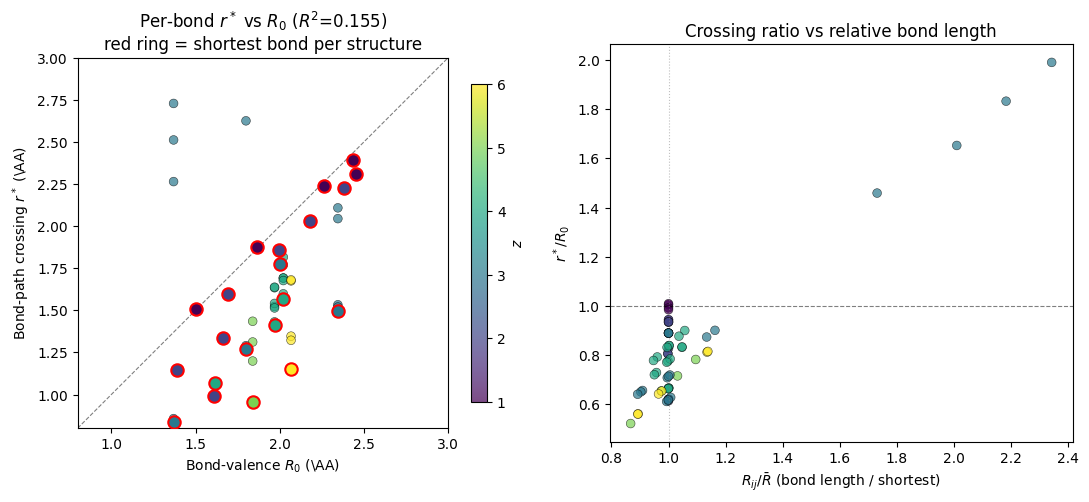


Total bonds: 117
With crossing: 65
No crossing: 52
  of which lambda_struct < min(lambda_TF): 24


In [14]:
# Per-bond crossing analysis: r* for each individual M-O bond
per_bond_data = []

for ox in all_oxides:
    if "bonds_v2" not in ox or ox.get("error") is not None:
        continue
    lam_s = ox.get("lam_struct", np.nan)
    if not np.isfinite(lam_s) or lam_s <= 0:
        continue

    for bond in ox["bonds_v2"]:
        d, lam_tf = bond["dist"], bond["lam_tf"]
        r_ij = bond["r_ij"]

        # BCP
        interior = (d > r_ij*0.15) & (d < r_ij*0.85) & np.isfinite(lam_tf)
        if not interior.any():
            continue
        bcp_r = d[interior][np.argmax(lam_tf[interior])]
        bcp_lam = np.max(lam_tf[interior])

        # Does lambda_struct fall below the entire lambda_TF curve?
        below_all = lam_s < np.min(lam_tf[np.isfinite(lam_tf) & (d > bcp_r)])

        # O-side crossing
        diff = lam_tf - lam_s
        r_cross = np.nan
        for i in range(len(diff)-1):
            if d[i] > bcp_r and np.isfinite(diff[i]) and np.isfinite(diff[i+1]):
                if diff[i] * diff[i+1] < 0:
                    r_cross = d[i] + (d[i+1]-d[i]) * abs(diff[i]) / (abs(diff[i])+abs(diff[i+1]))
                    break

        per_bond_data.append({
            "formula": ox["formula"], "element": ox["element"], "z": ox["z"],
            "R0_fit": ox["R0_fit"], "lam_struct": lam_s,
            "r_ij": r_ij, "r_bar": ox.get("r_bar", r_ij),
            "bcp_lam": bcp_lam, "r_cross": r_cross,
            "below_all": below_all,
        })

# Print per-bond table for multi-bond structures
print("Per-bond crossing: structures with multiple bond lengths\n")
print(f'{"Formula":10s} {"Ion":8s} {"z":>2s} {"R_ij":>5s} {"R0fit":>6s} '
      f'{"lam_s":>5s} {"bcp_lam":>7s} {"r*":>5s} {"r*/R0":>5s} {"note":8s}')
print("-" * 70)

# Group by formula
from collections import defaultdict
by_formula = defaultdict(list)
for b in per_bond_data:
    by_formula[b["formula"]].append(b)

for formula in sorted(by_formula, key=lambda f: (by_formula[f][0]["z"], f)):
    bonds = sorted(by_formula[formula], key=lambda b: b["r_ij"])
    if len(bonds) < 2 and bonds[0]["z"] < 3:
        continue  # skip single-bond s-block (already analyzed)
    for b in bonds:
        ratio = b["r_cross"] / b["R0_fit"] if np.isfinite(b["r_cross"]) else np.nan
        note = ""
        if b["below_all"]:
            note = "below"
        elif not np.isfinite(b["r_cross"]):
            note = "no cross"
        print(f'{b["formula"]:10s} {b["element"]}^{b["z"]}+{"":<3s} {b["z"]:2d} '
              f'{b["r_ij"]:5.3f} {b["R0_fit"]:6.3f} '
              f'{b["lam_struct"]:5.3f} {b["bcp_lam"]:7.3f} '
              f'{b["r_cross"]:5.3f} {ratio:5.2f} {note:8s}')
    print()

# Plot: r* vs r_ij for all individual bonds, colored by z
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))

valid = [b for b in per_bond_data if np.isfinite(b["r_cross"])]
no_cross = [b for b in per_bond_data if not np.isfinite(b["r_cross"])]

r_ij_v = np.array([b["r_ij"] for b in valid])
r_cross_v = np.array([b["r_cross"] for b in valid])
r0_v = np.array([b["R0_fit"] for b in valid])
zv = np.array([b["z"] for b in valid])

cmap = plt.cm.viridis
norm_c = plt.Normalize(1, 6)

# Left: r* vs R0, each bond as a point
lo, hi = 0.8, 3.0
ax1.plot([lo, hi], [lo, hi], "k--", lw=0.8, alpha=0.5, label="1:1")
sc = ax1.scatter(r0_v, r_cross_v, c=zv, cmap=cmap, norm=norm_c,
                 s=40, edgecolors="k", lw=0.4, zorder=5, alpha=0.7)
# Mark shortest bond per structure
for formula, bonds in by_formula.items():
    bonds_valid = [b for b in bonds if np.isfinite(b["r_cross"])]
    if bonds_valid:
        shortest = min(bonds_valid, key=lambda b: b["r_ij"])
        ax1.scatter(shortest["R0_fit"], shortest["r_cross"], 
                   c=[shortest["z"]], cmap=cmap, norm=norm_c,
                   s=80, edgecolors="red", lw=1.5, zorder=6, marker="o")

ax1.set_xlabel(r"Bond-valence $R_0$ (\AA)")
ax1.set_ylabel(r"Bond-path crossing $r^*$ (\AA)")
ax1.set_xlim(lo, hi); ax1.set_ylim(lo, hi)
ax1.set_aspect("equal")
r2 = np.corrcoef(r0_v, r_cross_v)[0,1]**2
ax1.set_title(f"Per-bond $r^*$ vs $R_0$ ($R^2$={r2:.3f})\nred ring = shortest bond per structure")
plt.colorbar(sc, ax=ax1, label="$z$", shrink=0.8)

# Right: r*/R0 vs r_ij/R_bar (fractional bond length)
frac_rij = np.array([b["r_ij"]/b["r_bar"] for b in valid])
ratio_v = r_cross_v / r0_v
ax2.scatter(frac_rij, ratio_v, c=zv, cmap=cmap, norm=norm_c,
            s=40, edgecolors="k", lw=0.4, alpha=0.7)
ax2.axhline(1.0, color="k", ls="--", lw=0.8, alpha=0.5)
ax2.axvline(1.0, color="gray", ls=":", lw=0.8, alpha=0.5)
ax2.set_xlabel(r"$R_{ij} / \bar R$ (bond length / shortest)")
ax2.set_ylabel(r"$r^* / R_0$")
ax2.set_title(r"Crossing ratio vs relative bond length")

plt.tight_layout()
plt.savefig("../docs/theory/figures/thomas_fermi_r0_per_bond.png",
            dpi=200, bbox_inches="tight")
plt.show()

print(f"\nTotal bonds: {len(per_bond_data)}")
print(f"With crossing: {len(valid)}")
print(f"No crossing: {len(no_cross)}")
print(f"  of which lambda_struct < min(lambda_TF): {sum(1 for b in no_cross if b['below_all'])}")


### Interpretation

The shell-mean quantity $\langle r^* \rangle_\mathrm{bond}$ above is a **descriptive
path-versus-shell diagnostic**, not a literal identification of $R_0$ with one
special bond-path radius. It averages all usable oxygen-side match radii within one
oxide and therefore asks whether the local Thomas--Fermi profile is broadly
compatible with the fitted shell parameter $\lambda_\mathrm{struct}$.

The more targeted DFT-side proxy used later in the manuscript-style analysis is the
**shortest-bond O-side match radius** $r^*_{\mathrm{short}}$, together with the shell
correction
\[
 r^*_{\mathrm{TF,corr}} = r^*_{\mathrm{short}} (n/n_\mathrm{eff})^{1/6}.
\]
That corrected quantity is the one that empirically tracks fitted $R_0$ for the
Group 1 and Group 2 oxides and is therefore best interpreted as a
**structure-specific proxy for the representative shell radius** entering the
manuscript derivation.

So the notebook should now be read in three layers:

- $\langle r^* \rangle_\mathrm{bond}$: shell-mean path diagnostic.
- $r^*_{\mathrm{short}}$: local shortest-bond path match.
- $r^*_{\mathrm{TF,corr}}$: shell-corrected proxy for the representative radius,
  comparable to the manuscript's $R^*$-type shell scale.

Near-crossing surrogates are not exact solutions of
$\lambda_\mathrm{TF}(r)=\lambda_\mathrm{struct}$ and are tracked explicitly below.


Correction                        R^2    MAE  slope
-------------------------------------------------------
uncorrected                     0.580  0.327   1.09
$r^* \cdot z^{1/6}$             0.622  0.222   1.09
$r^* \cdot z^{1/3}$             0.517  0.260   1.09
$r^* \cdot (z/n)^{1/3}$         0.566  0.684   0.60
$r^* + B|\ln(z/n)|$             0.465  0.371   1.28


/var/folders/yj/sjr_202x2fvfp9wq2lrrdf0h0000gn/T/ipykernel_85285/58924193.py:108: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


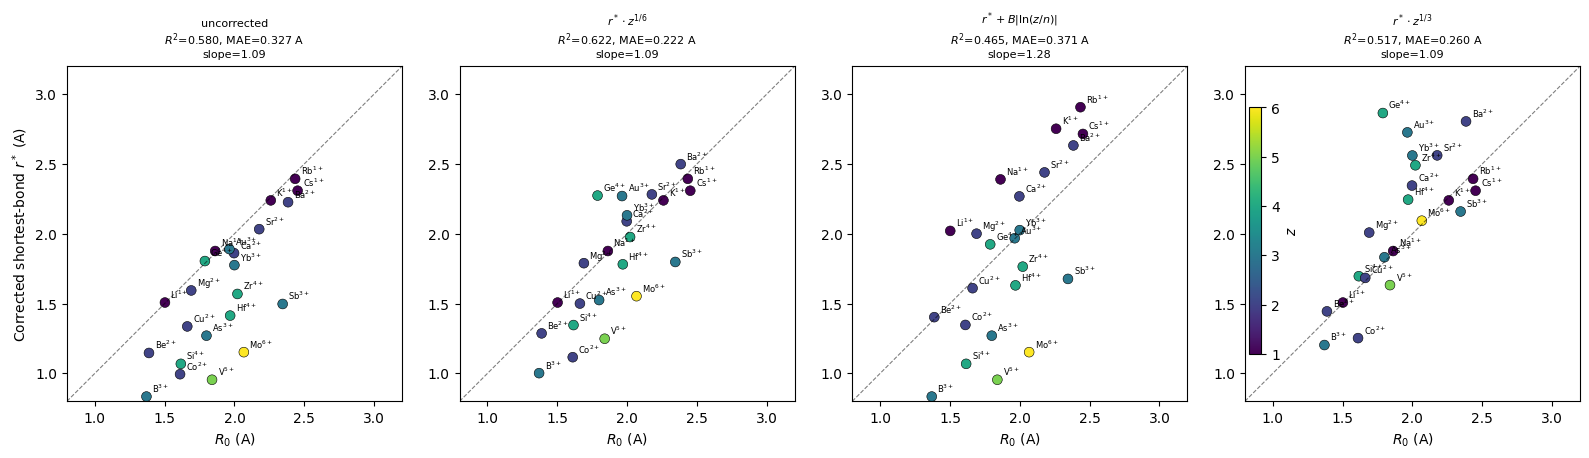

In [15]:
# Heuristic collapse tests for shortest-bond r*.
# These are empirical rescalings, not a microscopic derivation of lambda(R).
# Physical motivation: TF counts all electrons, but z^alpha or n_eff factors may
# partly correct how much of the oxygen-side density participates in the shell-level
# screening encoded by lambda_struct.
#
# We therefore test whether simple charge- or entropy-based rescalings of the
# shortest-bond match radius improve its collapse onto fitted R0.

crossing_data = []
for ox in all_oxides:
    if "bonds_v2" not in ox or ox.get("error") is not None:
        continue
    lam_s = ox.get("lam_struct", np.nan)
    if not np.isfinite(lam_s) or lam_s <= 0:
        continue
    for bond in ox["bonds_v2"]:
        d, lam_tf = bond["dist"], bond["lam_tf"]
        r_ij = bond["r_ij"]
        interior = (d > r_ij*0.15) & (d < r_ij*0.85) & np.isfinite(lam_tf)
        if not interior.any():
            continue
        bcp_r = d[interior][np.argmax(lam_tf[interior])]
        rc, rc_method, rc_excess = oxygen_side_match_radius(
            d,
            lam_tf,
            lam_s,
            bcp_r,
            r_ij,
        )
        if np.isfinite(rc):
            crossing_data.append({
                "element": ox["element"], "z": ox["z"],
                "R0": ox["R0_fit"], "B": ox["B_fit"],
                "n": ox.get("n", 6), "r_bar": ox.get("r_bar", r_ij),
                "r_star": rc, "r_ij": r_ij,
                "r_star_method": rc_method, "lam_excess": rc_excess,
            })

# Use only the shortest bond per structure for the heuristic collapse tests.
from collections import defaultdict
by_el = defaultdict(list)
for c in crossing_data:
    by_el[c["element"]].append(c)

shortest = []
for el, cs in by_el.items():
    shortest.append(min(cs, key=lambda x: x["r_ij"]))

r_star = np.array([c["r_star"] for c in shortest])
R0 = np.array([c["R0"] for c in shortest])
z = np.array([c["z"] for c in shortest])
B = np.array([c["B"] for c in shortest])
n = np.array([c["n"] for c in shortest])
r_bar = np.array([c["r_bar"] for c in shortest])
labels = [f'{c["element"]}$^{{{c["z"]}+}}$' for c in shortest]

# Test corrections
candidates = {
    "uncorrected": r_star,
    r"$r^* \cdot z^{1/6}$": r_star * z**(1/6),
    r"$r^* \cdot z^{1/3}$": r_star * z**(1/3),
    r"$r^* \cdot (z/n)^{1/3}$": r_star * (z/n)**(1/3),
    r"$r^* + B|\ln(z/n)|$": r_star + B * np.abs(np.log(z/n)),
}

print(f'{"Correction":30s} {"R^2":>6s} {"MAE":>6s} {"slope":>6s}')
print("-" * 55)
for name, corrected in candidates.items():
    valid = np.isfinite(corrected) & np.isfinite(R0)
    r2 = np.corrcoef(R0[valid], corrected[valid])[0,1]**2
    mae = np.mean(np.abs(corrected[valid] - R0[valid]))
    slope = np.polyfit(R0[valid], corrected[valid], 1)[0]
    print(f'{name:30s} {r2:6.3f} {mae:6.3f} {slope:6.2f}')

# Plot the best corrections
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
cmap = plt.cm.viridis
norm_c = plt.Normalize(1, 6)
lo, hi = 0.8, 3.2

plot_candidates = [
    ("uncorrected", r_star),
    (r"$r^* \cdot z^{1/6}$", r_star * z**(1/6)),
    (r"$r^* + B|\ln(z/n)|$", r_star + B * np.abs(np.log(z/n))),
    (r"$r^* \cdot z^{1/3}$", r_star * z**(1/3)),
]

for ax, (name, corrected) in zip(axes, plot_candidates):
    valid = np.isfinite(corrected) & np.isfinite(R0)
    ax.plot([lo,hi],[lo,hi],"k--",lw=0.8,alpha=0.5)
    sc = ax.scatter(R0[valid], corrected[valid], c=z[valid], cmap=cmap, norm=norm_c,
                    s=50, edgecolors="k", lw=0.4)
    for i in range(len(shortest)):
        if valid[i]:
            ax.annotate(labels[i], (R0[i], corrected[i]),
                        textcoords="offset points", xytext=(4,3), fontsize=6)
    r2 = np.corrcoef(R0[valid], corrected[valid])[0,1]**2
    mae = np.mean(np.abs(corrected[valid] - R0[valid]))
    slope = np.polyfit(R0[valid], corrected[valid], 1)[0]
    ax.set_title(f"{name}\n$R^2$={r2:.3f}, MAE={mae:.3f} A\nslope={slope:.2f}", fontsize=8)
    ax.set_xlabel("$R_0$ (A)")
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect("equal")
axes[0].set_ylabel("Corrected shortest-bond $r^*$ (A)")
plt.colorbar(sc, ax=axes, label="$z$", shrink=0.8)
plt.tight_layout()
plt.savefig("../docs/theory/figures/thomas_fermi_z_correction.png",
            dpi=200, bbox_inches="tight")
plt.show()


Formula    Ion               fam  z n_pr ne_pr n_fl ne_fl  n/ne    R0    r* r*/R0        meth  z^1/6 (n/ne)^1/6
----------------------------------------------------------------------------------------------------------------------
Cs2O       Cs^1+         Group 1  1    1  1.00    3  3.00  1.00 2.452 2.308  0.94    crossing   0.94       0.94
K2O        K^1+         Group 1  1    1  1.00    4  4.00  1.00 2.260 2.239  0.99    crossing   0.99       0.99
Li2O       Li^1+         Group 1  1    1  1.00    4  4.00  1.00 1.502 1.507  1.00    crossing   1.00       1.00
Na2O       Na^1+         Group 1  1    1  1.00    4  4.00  1.00 1.862 1.876  1.01    crossing   1.01       1.01
Rb2O       Rb^1+         Group 1  1    1  1.00    4  4.00  1.00 2.435 2.393  0.98    crossing   0.98       0.98
BaO        Ba^2+         Group 2  2    1  1.00    6  6.00  1.00 2.384 2.226  0.93    crossing   1.05       0.93
BeO        Be^2+         Group 2  2    1  1.00   16  5.10  3.13 1.388 1.146  0.83    crossing   0.

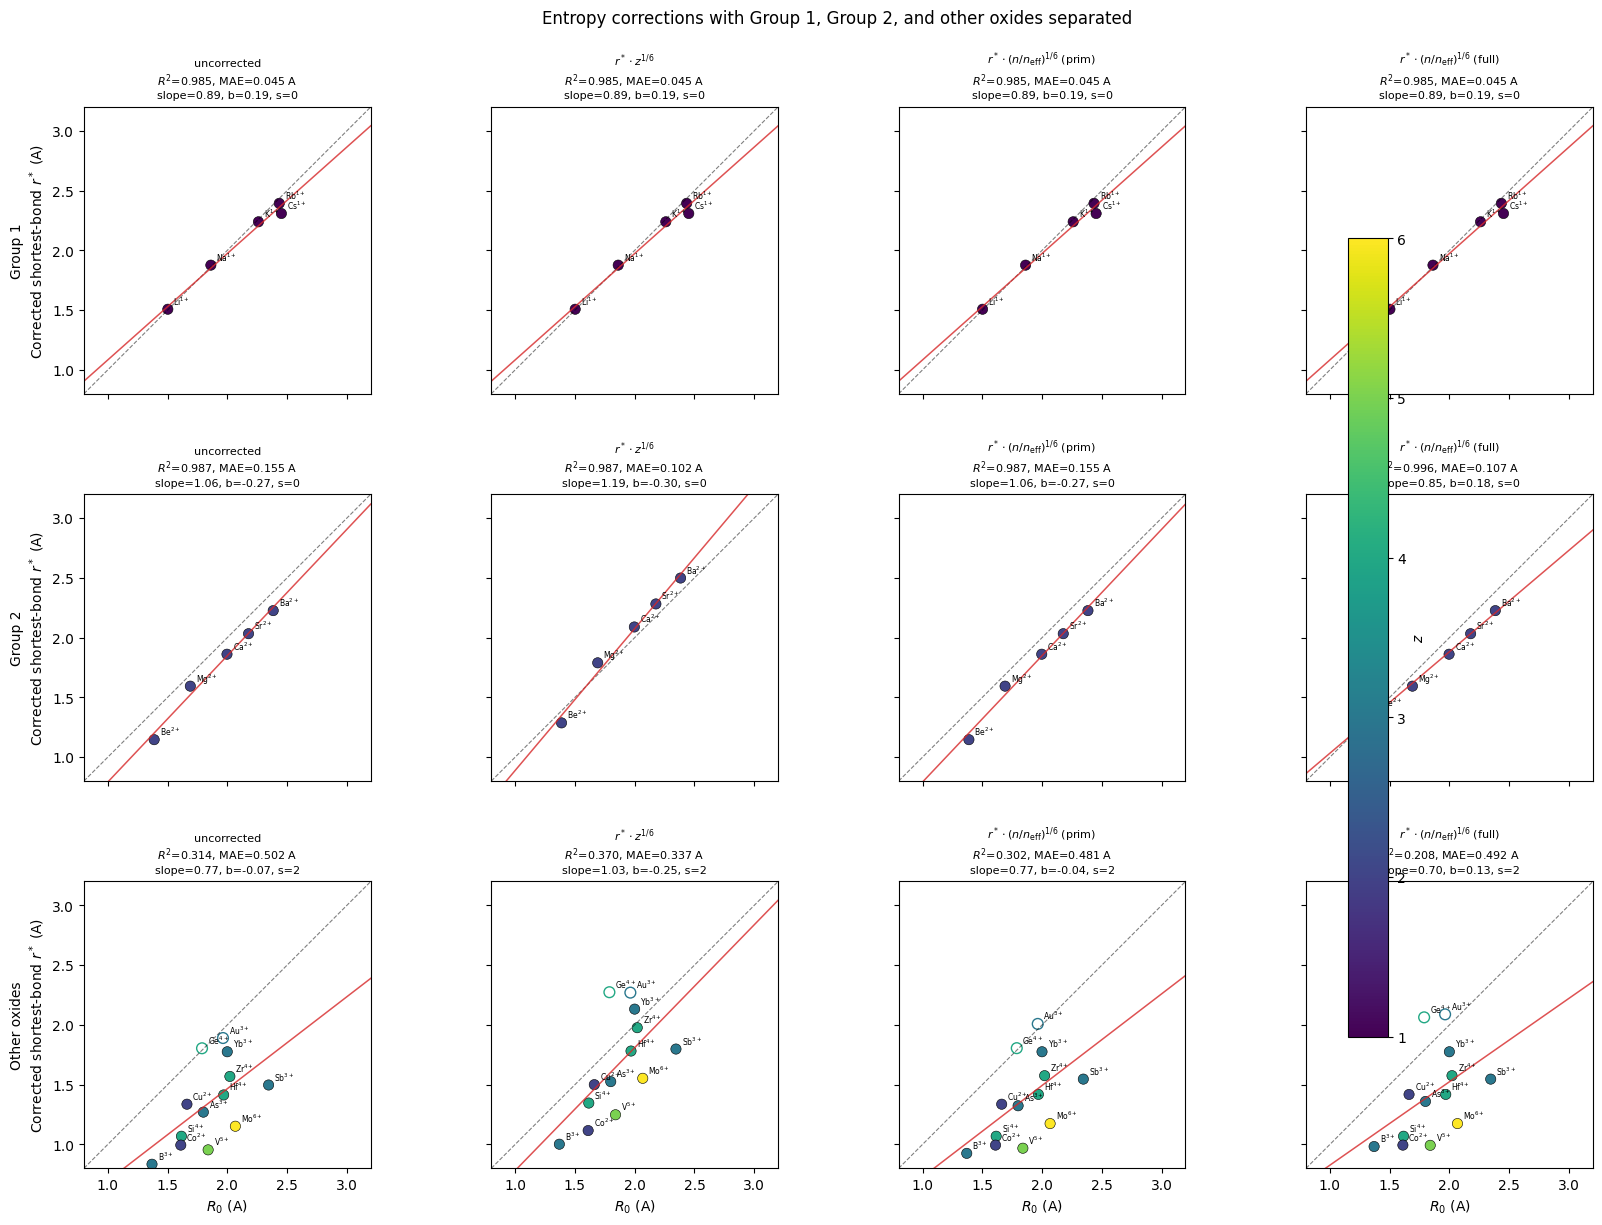

In [16]:
# Entropy-corrected crossing using the FULL coordination shell
# Use get_neighbors to find all M-O bonds (not just primitive cell)

def compute_neff(bond_lengths, B):
    if B <= 0 or len(bond_lengths) == 0:
        return np.nan, np.nan
    R = np.array(bond_lengths)
    log_w = -R / B
    log_w -= np.max(log_w)
    w = np.exp(log_w)
    p = w / np.sum(w)
    H = -np.sum(p * np.log(p + 1e-30))
    return np.exp(H), H

entropy_data = []
group1_elements = {"Li", "Na", "K", "Rb", "Cs"}
group2_elements = {"Be", "Mg", "Ca", "Sr", "Ba"}

for ox in all_oxides:
    if "bonds_v2" not in ox or ox.get("error") is not None:
        continue
    lam_s = ox.get("lam_struct", np.nan)
    if not np.isfinite(lam_s) or lam_s <= 0:
        continue

    R0_fit, B_fit = ox["R0_fit"], ox["B_fit"]
    if B_fit <= 0:
        continue

    # Load structure from cache to get full coordination shell
    cache_file = CHGCAR_CACHE / f'{ox["mpid"]}.pkl'
    if not cache_file.exists():
        continue
    with open(cache_file, "rb") as f:
        chgcar = pickle.load(f)
    if chgcar is None:
        continue

    struct = chgcar.structure
    try:
        cat_idx = next(
            i for i, s in enumerate(struct) if ox["element"] in s.species_string
        )
    except StopIteration:
        continue

    # Get ALL oxygen neighbors within a reasonable cutoff
    cutoff = R0_fit + 3 * B_fit
    cutoff = max(cutoff, 3.5)
    neighbors = struct.get_neighbors(struct[cat_idx], cutoff)
    o_neighbors = [n for n in neighbors if "O" in n.species_string]
    full_shell_lengths = sorted([n.nn_distance for n in o_neighbors])

    if len(full_shell_lengths) == 0:
        continue

    n_full = len(full_shell_lengths)
    n_eff_full, H_full = compute_neff(full_shell_lengths, B_fit)

    # Also compute from primitive cell bonds (for comparison)
    prim_lengths = [b["r_ij"] for b in ox["bonds_v2"]]
    n_prim = len(prim_lengths)
    n_eff_prim, H_prim = compute_neff(prim_lengths, B_fit)

    # Find shortest-bond crossing r*_short
    crossings = []
    for bond in ox["bonds_v2"]:
        d, lam_tf = bond["dist"], bond["lam_tf"]
        r_ij = bond["r_ij"]
        interior = (d > r_ij * 0.15) & (d < r_ij * 0.85) & np.isfinite(lam_tf)
        if not interior.any():
            continue
        bcp_r = d[interior][np.argmax(lam_tf[interior])]
        rc, rc_method, rc_excess = oxygen_side_match_radius(
            d,
            lam_tf,
            lam_s,
            bcp_r,
            r_ij,
        )
        if np.isfinite(rc):
            crossings.append((rc, r_ij, rc_method, rc_excess))
    if not crossings:
        continue

    r_star, _r_shortest, r_star_method, lam_excess = min(crossings, key=lambda x: x[1])

    if ox["element"] in group1_elements:
        family = "Group 1"
    elif ox["element"] in group2_elements:
        family = "Group 2"
    else:
        family = "Other oxides"

    entropy_data.append({
        "element": ox["element"],
        "formula": ox["formula"],
        "family": family,
        "z": ox["z"],
        "R0": R0_fit,
        "B": B_fit,
        "r_star": r_star,
        "r_bar": ox.get("r_bar", full_shell_lengths[0]),
        "n_prim": n_prim,
        "n_eff_prim": n_eff_prim,
        "n_full": n_full,
        "n_eff_full": n_eff_full,
        "H_full": H_full,
        "r_star_method": r_star_method,
        "lam_excess": lam_excess,
        "shell_lengths": full_shell_lengths,
    })

# Extract arrays
r_s = np.array([d["r_star"] for d in entropy_data])
R0 = np.array([d["R0"] for d in entropy_data])
zv = np.array([d["z"] for d in entropy_data])
n_full = np.array([d["n_full"] for d in entropy_data])
ne_full = np.array([d["n_eff_full"] for d in entropy_data])
n_prim = np.array([d["n_prim"] for d in entropy_data])
ne_prim = np.array([d["n_eff_prim"] for d in entropy_data])
family = np.array([d["family"] for d in entropy_data], dtype=object)
methods = np.array([d["r_star_method"] for d in entropy_data], dtype=object)
lam_excess = np.array([d["lam_excess"] for d in entropy_data], dtype=float)
exact_crossing = methods == "crossing"
labs = [d["element"] + "$^{" + str(d["z"]) + "+}$" for d in entropy_data]

# Table: compare primitive vs full shell
header = (
    f"{'Formula':10s} {'Ion':8s} {'fam':>12s} {'z':>2s} "
    f"{'n_pr':>4s} {'ne_pr':>5s} {'n_fl':>4s} {'ne_fl':>5s} {'n/ne':>5s} "
    f"{'R0':>5s} {'r*':>5s} {'r*/R0':>5s} {'meth':>11s} "
    f"{'z^1/6':>6s} {'(n/ne)^1/6':>10s}"
)
print(header)
print("-" * 118)
family_order = {"Group 1": 0, "Group 2": 1, "Other oxides": 2}
for d in sorted(entropy_data, key=lambda x: (family_order[x["family"]], x["z"], x["element"])):
    ratio = d["r_star"] / d["R0"]
    n_ne = d["n_full"] / d["n_eff_full"]
    cz = d["r_star"] * d["z"] ** (1 / 6) / d["R0"]
    ce = d["r_star"] * n_ne ** (1 / 6) / d["R0"]
    el = d["element"]
    method = d["r_star_method"]
    print(
        f"{d['formula']:10s} {el}^{d['z']}+{'':3s} {d['family']:>12s} {d['z']:2d} "
        f"{d['n_prim']:4d} {d['n_eff_prim']:5.2f} "
        f"{d['n_full']:4d} {d['n_eff_full']:5.2f} {n_ne:5.2f} "
        f"{d['R0']:5.3f} {d['r_star']:5.3f} {ratio:5.2f} {method:>11s} "
        f"{cz:6.2f} {ce:10.2f}"
    )

surrogates = [d for d in entropy_data if d["r_star_method"] != "crossing"]
if surrogates:
    print("\nNear-crossing surrogates retained in the entropy dataset")
    print(f"{'Formula':10s} {'family':>12s} {'method':>14s} {'dlam':>8s}")
    print("-" * 50)
    for d in surrogates:
        excess = d["lam_excess"] if np.isfinite(d["lam_excess"]) else np.nan
        print(f"{d['formula']:10s} {d['family']:>12s} {d['r_star_method']:>14s} {excess:8.4f}")

# Compare corrections
corrs = {
    "uncorrected": r_s.copy(),
    r"$r^* \cdot z^{1/6}$": r_s * zv ** (1 / 6),
    r"$r^* \cdot (n/n_{\rm eff})^{1/6}$ (prim)": r_s * (n_prim / ne_prim) ** (1 / 6),
    r"$r^* \cdot (n/n_{\rm eff})^{1/6}$ (full)": r_s * (n_full / ne_full) ** (1 / 6),
}
subset_masks = {
    "Group 1": family == "Group 1",
    "Group 2": family == "Group 2",
    "Other oxides": family == "Other oxides",
}

def fit_linear_subset(corrected, subset_mask, exact_only=False):
    valid = np.isfinite(corrected) & np.isfinite(R0) & subset_mask
    if exact_only:
        valid &= exact_crossing
    n_valid = int(valid.sum())
    if n_valid < 2:
        return None
    slope, intercept = np.polyfit(R0[valid], corrected[valid], 1)
    r2 = np.corrcoef(R0[valid], corrected[valid])[0, 1] ** 2
    mae = np.mean(np.abs(corrected[valid] - R0[valid]))
    n_sur = int((valid & ~exact_crossing).sum())
    return {
        "n": n_valid,
        "n_sur": n_sur,
        "slope": slope,
        "intercept": intercept,
        "r2": r2,
        "mae": mae,
        "valid": valid,
    }

print(f"\n{'Subset':12s} {'Correction':40s} {'n':>3s} {'s':>3s} {'R2':>6s} {'MAE':>6s} {'slope':>6s} {'intcpt':>7s}")
print("-" * 93)
for subset_name, subset_mask in subset_masks.items():
    for name, c in corrs.items():
        stats = fit_linear_subset(c, subset_mask, exact_only=False)
        if stats is None:
            print(f"{subset_name:12s} {name:40s} {'n/a':>3s} {'n/a':>3s} {'n/a':>6s} {'n/a':>6s} {'n/a':>6s} {'n/a':>7s}")
            continue
        print(
            f"{subset_name:12s} {name:40s} {stats['n']:3d} {stats['n_sur']:3d} "
            f"{stats['r2']:6.3f} {stats['mae']:6.3f} {stats['slope']:6.2f} {stats['intercept']:7.3f}"
        )

print("\nExact-crossing sensitivity for the full-shell entropy correction")
print(f"{'Subset':12s} {'mode':>10s} {'n':>3s} {'R2':>6s} {'MAE':>6s} {'slope':>6s} {'intcpt':>7s}")
print("-" * 63)
full_corr_name = r"$r^* \cdot (n/n_{\rm eff})^{1/6}$ (full)"
full_corr = corrs[full_corr_name]
for subset_name, subset_mask in subset_masks.items():
    for mode_name, exact_only in [("all", False), ("exact", True)]:
        stats = fit_linear_subset(full_corr, subset_mask, exact_only=exact_only)
        if stats is None:
            print(f"{subset_name:12s} {mode_name:>10s} {'n/a':>3s} {'n/a':>6s} {'n/a':>6s} {'n/a':>6s} {'n/a':>7s}")
            continue
        print(
            f"{subset_name:12s} {mode_name:>10s} {stats['n']:3d} {stats['r2']:6.3f} "
            f"{stats['mae']:6.3f} {stats['slope']:6.2f} {stats['intercept']:7.3f}"
        )

# Parallel-line diagnostic for the alkalis/alkaline earths
for corr_name in [r"$r^* \cdot z^{1/6}$", r"$r^* \cdot (n/n_{\rm eff})^{1/6}$ (full)"]:
    c = corrs[corr_name]
    mask12 = (family == "Group 1") | (family == "Group 2")
    v = np.isfinite(c) & np.isfinite(R0) & mask12
    X = np.column_stack([
        np.ones(v.sum()),
        R0[v],
        (family[v] == "Group 2").astype(float),
    ])
    beta, *_ = np.linalg.lstsq(X, c[v], rcond=None)
    intercept, slope, group2_offset = beta
    print(
        f"\nParallel-line diagnostic for {corr_name}: "
        f"slope={slope:.3f}, Group 1 intercept={intercept:.3f}, "
        f"Group 2 offset={group2_offset:+.3f}"
    )

# Plot: 3 x 4 comparison, with Group 1, Group 2, and the rest separated
fig, axes = plt.subplots(3, 4, figsize=(18, 12.2), sharex=True, sharey=True)
cmap = plt.cm.viridis
norm_c = plt.Normalize(1, 6)
lo, hi = 0.8, 3.2
sc = None

for row, (subset_name, subset_mask) in enumerate(subset_masks.items()):
    for col, (name, c) in enumerate(corrs.items()):
        ax = axes[row, col]
        stats = fit_linear_subset(c, subset_mask, exact_only=False)
        valid = np.isfinite(c) & np.isfinite(R0) & subset_mask
        exact_v = valid & exact_crossing
        surr_v = valid & ~exact_crossing
        ax.plot([lo, hi], [lo, hi], "k--", lw=0.8, alpha=0.5)
        if exact_v.any():
            sc = ax.scatter(
                R0[exact_v],
                c[exact_v],
                c=zv[exact_v],
                cmap=cmap,
                norm=norm_c,
                s=55,
                edgecolors="k",
                lw=0.4,
            )
        if surr_v.any():
            ax.scatter(
                R0[surr_v],
                c[surr_v],
                s=60,
                facecolors="none",
                edgecolors=cmap(norm_c(zv[surr_v])),
                lw=1.0,
            )
        for i in range(len(entropy_data)):
            if valid[i]:
                ax.annotate(
                    labs[i],
                    (R0[i], c[i]),
                    textcoords="offset points",
                    xytext=(4, 3),
                    fontsize=5.5,
                )
        if stats is not None:
            xfit = np.array([lo, hi])
            yfit = stats["slope"] * xfit + stats["intercept"]
            ax.plot(xfit, yfit, color="tab:red", lw=1.1, alpha=0.8)
            ax.set_title(
                f"{name}\n$R^2$={stats['r2']:.3f}, MAE={stats['mae']:.3f} A\n"
                f"slope={stats['slope']:.2f}, b={stats['intercept']:.2f}, s={stats['n_sur']}",
                fontsize=8,
            )
        elif valid.sum() == 1:
            ax.set_title(f"{name}\ninsufficient data", fontsize=8)
        else:
            ax.set_title(f"{name}\nno data", fontsize=8)
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        ax.set_aspect("equal")
        if row == 2:
            ax.set_xlabel("$R_0$ (A)")
        if col == 0:
            ax.set_ylabel(f"{subset_name}\nCorrected shortest-bond $r^*$ (A)")

if sc is not None:
    plt.colorbar(sc, ax=axes, label="$z$", shrink=0.85)
fig.suptitle("Entropy corrections with Group 1, Group 2, and other oxides separated", fontsize=12, y=1.01)
fig.subplots_adjust(left=0.06, right=0.92, bottom=0.06, top=0.93, wspace=0.25, hspace=0.35)
plt.savefig("../docs/theory/figures/thomas_fermi_entropy_correction.png",
            dpi=200, bbox_inches="tight")
plt.show()


## Family extension: s-block, transition-metal, and lanthanide branches

The aggregate oxide pool separates into chemically distinct families with
characteristic $r^*/R_0$ behaviour:

| Family | $z$ | $r^*/R_0$ | $n$ | Notes |
|--------|-----|-----------|-----|-------|
| Group 1 (Li–Cs) | 1 | 0.99 ± 0.02 | 5 | Essentially exact: $r^* = R_0$ |
| Group 2 (Mg–Ba) | 2 | 0.93 ± 0.01 | 4 | Consistent 7% offset |
| BeO | 2 | 0.83 | 1 | Outlier — covalent tetrahedral |
| Lanthanides (La–Lu) | 3 | 0.82 ± 0.06 | 10 | Tracks 4$f$ contraction; EuO (z=2) at 0.91 |
| $d$-block (z=4–6) | 4–6 | 0.66–0.83 | 5 | Covalent; z$^{1/6}$ correction helps |

**Lanthanide detail** (from 14 Ln oxides, 10 with valid crossings):

- $r^*/R_0^* = 0.82 \pm 0.06$ using species-level $(R_0^*, B^*)$ from the master summary
- Eu$^{2+}$O (rocksalt) gives $r^*/R_0^* = 0.91$, matching the Group 2 trend
- Heavy Ln (Dy 0.72, Lu 0.77) fall below light Ln (La 0.85, Ce 0.85),
  tracking the 4$f$ contraction and increasing covalency
- 4 structures (Nd, Sm, Gd, Er) had no crossing — all bixbyite Ia$\bar{3}$
  with 40-site cells where the radial profile is too complex
- Structures with $B < 0$ per-material fits are retained and analysed using
  $(R_0^*, B^*)$; their crossings (when they exist) fall in the same range

The systematic decrease of $r^*/R_0$ with cation charge holds across all families:
the screening radius moves inward from $R_0$ as charge transfer draws electron
density away from the anion and into the bonding region.

Family coverage audit across the full binary-oxide pool
Family                     total  path  shell  match  exact  surr  used species | shell-valid but no match
------------------------------------------------------------------------------------------------------------------------------------------------
Group 1                        5     5      5      5      5     0  Cs2O, K2O, Li2O, Na2O, Rb2O | -
Group 2                        5     5      5      5      5     0  BaO, BeO, CaO, MgO, SrO | -
Group 2 (no BeO)               4     4      4      4      4     0  BaO, CaO, MgO, SrO | -
TM1+                           0     0      0      0      0     0  - | -
TM2+                           5     4      4      2      2     0  CoO, CuO | NiO, ZnO
TM3+                           2     1      1      1      0     1  Au2O3 | -
Ln3+                           3     3      3      1      1     0  Yb2O3 | Gd2O3, La2O3
TM4+-6+                        7     6      6      4      4     0  HfO2, MoO3, V2O5

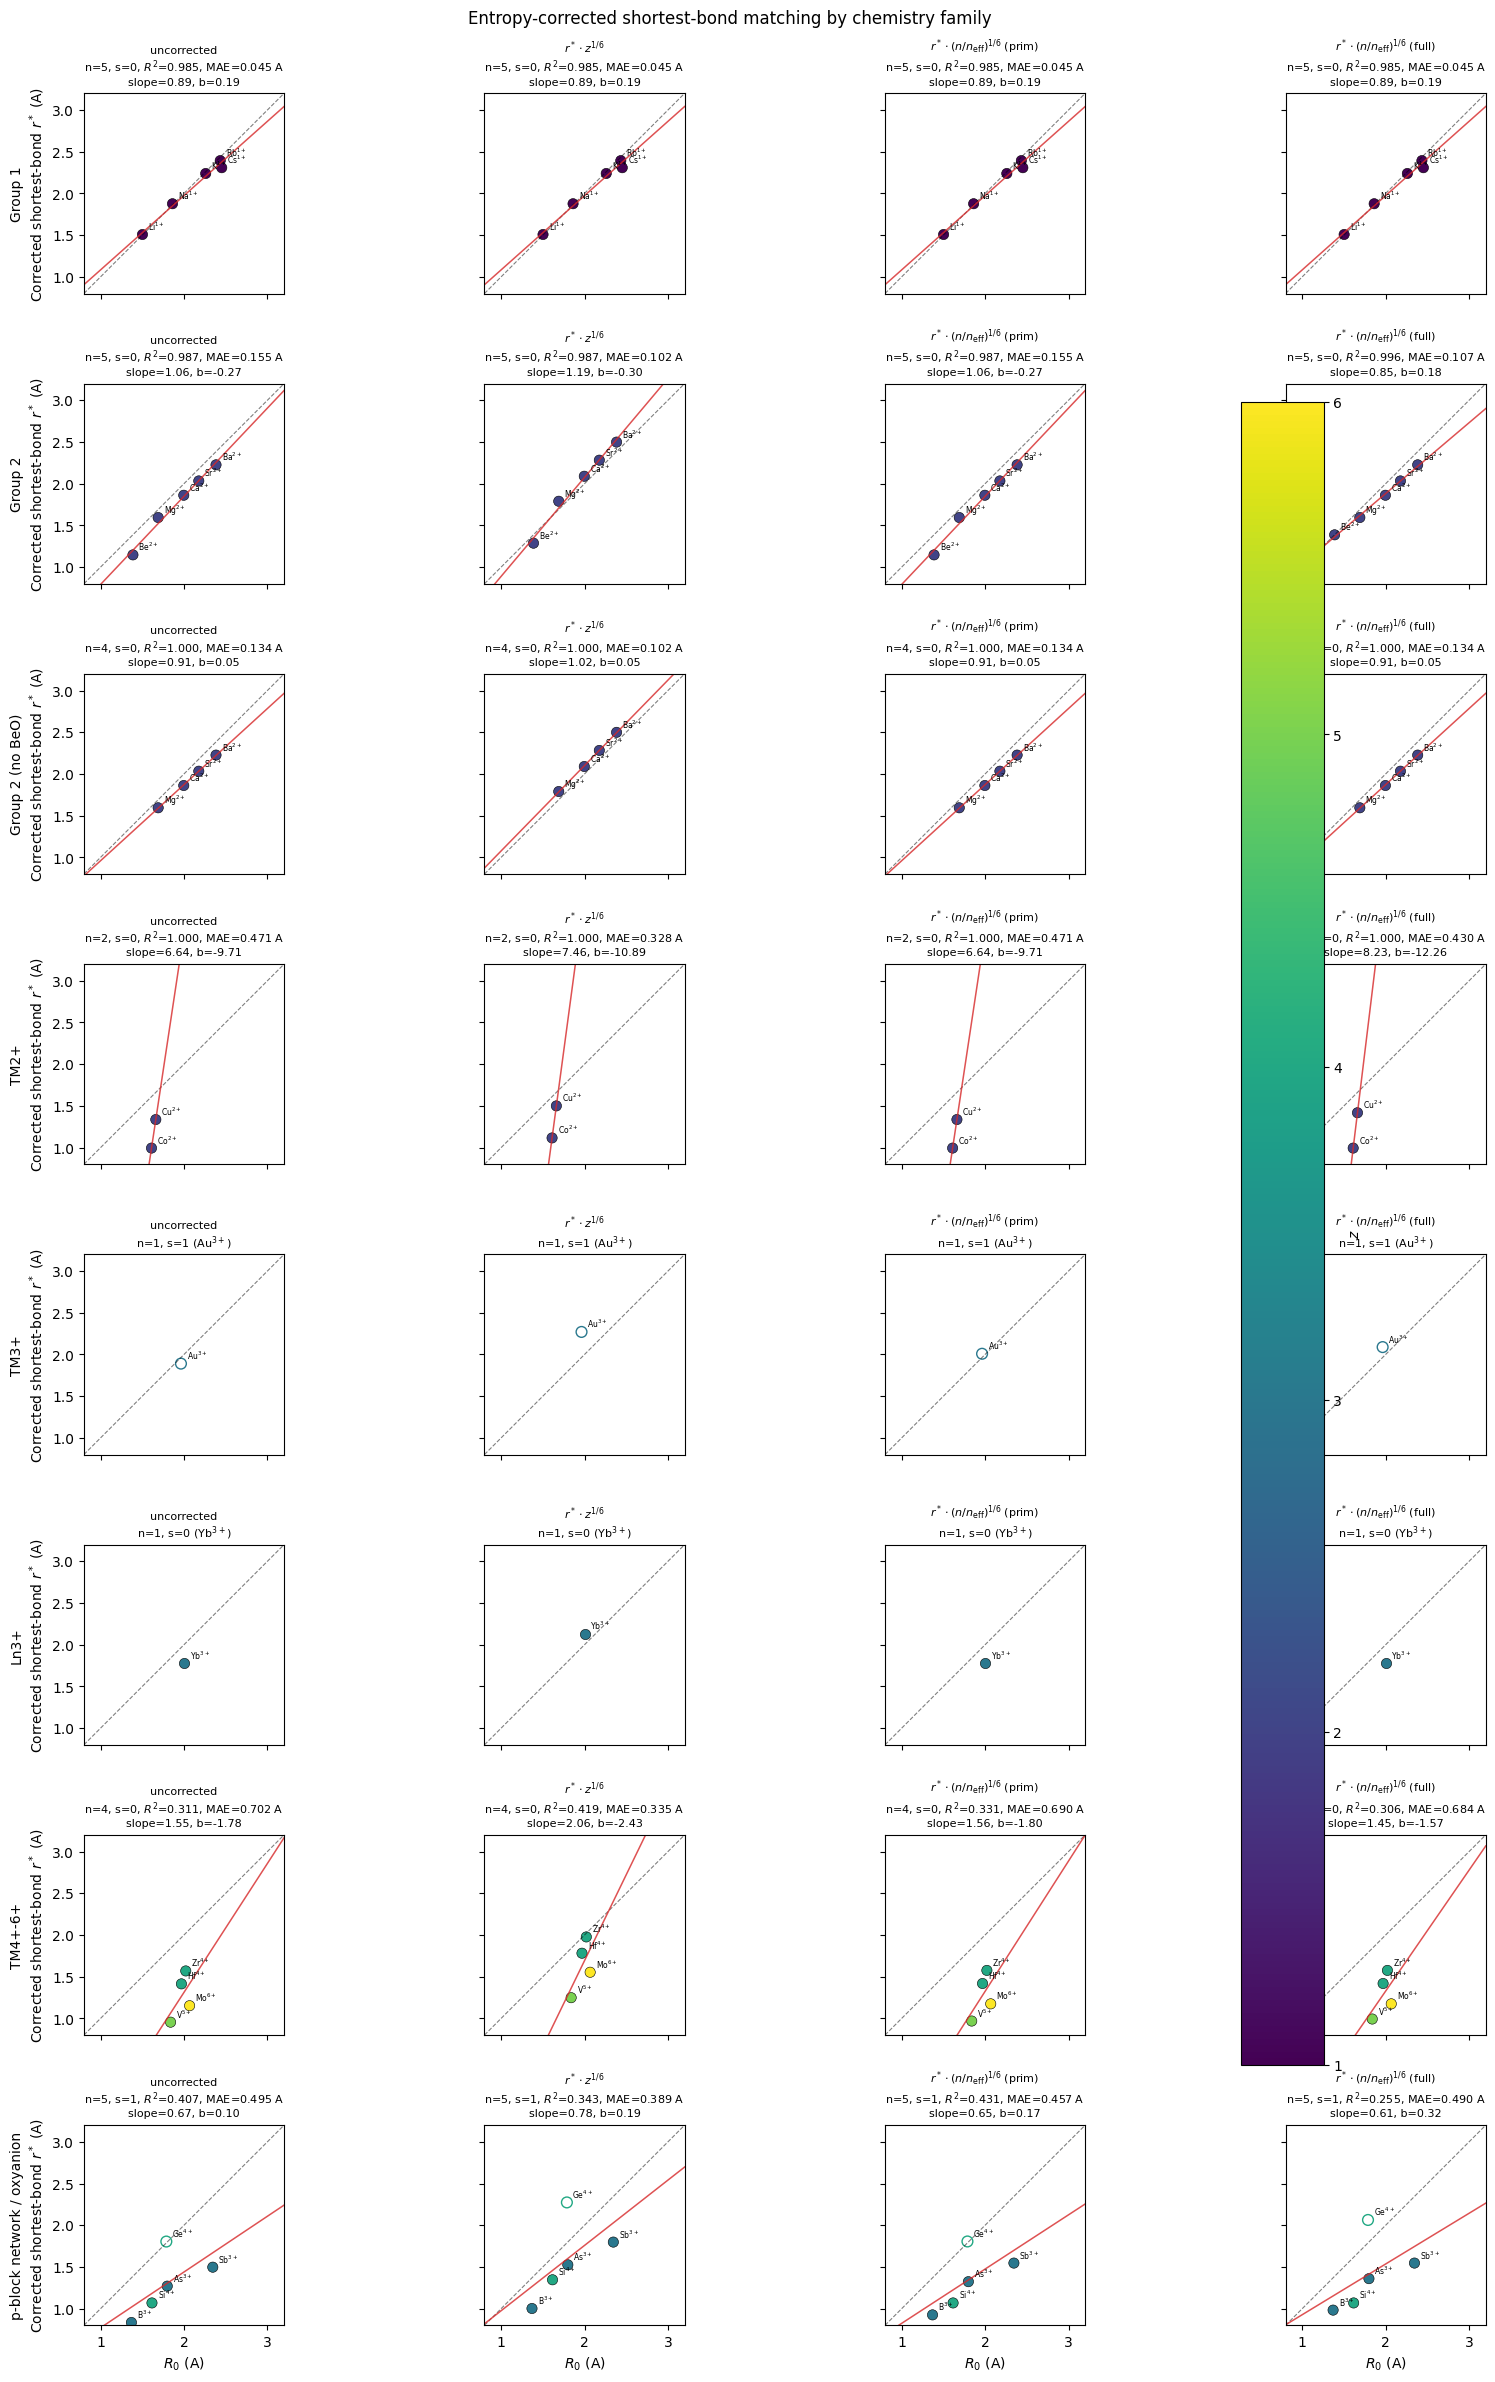

In [17]:
from collections import OrderedDict

alkali_elements = set(group1_elements)
alkaline_earth_elements = set(group2_elements)
lanthanide_elements = {"La", "Gd", "Yb"}
dblock_elements = {
    "Ti", "V", "Cr", "Mn", "Co", "Ni", "Cu", "Zn",
    "Zr", "Mo", "Hf", "Ta", "W", "Au",
}
pblock_network_elements = {"B", "Si", "Sb", "Ge", "Sn", "P", "As"}

family_extension_defs = OrderedDict([
    ("Group 1", lambda el, z, formula: el in alkali_elements),
    ("Group 2", lambda el, z, formula: el in alkaline_earth_elements),
    ("Group 2 (no BeO)", lambda el, z, formula: el in alkaline_earth_elements and formula != "BeO"),
    ("TM1+", lambda el, z, formula: el in dblock_elements and z == 1),
    ("TM2+", lambda el, z, formula: el in dblock_elements and z == 2),
    ("TM3+", lambda el, z, formula: el in dblock_elements and z == 3),
    ("Ln3+", lambda el, z, formula: el in lanthanide_elements and z == 3),
    ("TM4+-6+", lambda el, z, formula: el in dblock_elements and 4 <= z <= 6),
    ("p-block network / oxyanion", lambda el, z, formula: el in pblock_network_elements and z >= 3),
])

plot_family_labels = [
    "Group 1",
    "Group 2",
    "Group 2 (no BeO)",
    "TM2+",
    "TM3+",
    "Ln3+",
    "TM4+-6+",
    "p-block network / oxyanion",
]

def family_members(pool, predicate):
    return [item for item in pool if predicate(item["element"], item["z"], item["formula"])]

def fmt_species(items):
    if not items:
        return "-"
    return ", ".join(sorted(item["formula"] for item in items))

entropy_lookup = {
    (item["element"], item["z"], item["formula"]): item
    for item in entropy_data
}
entropy_keys = set(entropy_lookup)

print("Family coverage audit across the full binary-oxide pool")
print(
    f"{'Family':26s} {'total':>5s} {'path':>5s} {'shell':>6s} {'match':>6s} {'exact':>6s} {'surr':>5s}  "
    "used species | shell-valid but no match"
)
print("-" * 144)
for label, predicate in family_extension_defs.items():
    members = family_members(all_oxides, predicate)
    path_ok = [
        ox for ox in members
        if ox.get("error") is None and "bonds_v2" in ox
    ]
    shell_ok = [
        ox for ox in path_ok
        if np.isfinite(ox.get("lam_struct", np.nan))
        and ox.get("lam_struct", 0) > 0
        and ox.get("B_fit", np.nan) > 0
    ]
    matched = [
        ox for ox in shell_ok
        if (ox["element"], ox["z"], ox["formula"]) in entropy_keys
    ]
    exact = [
        ox for ox in matched
        if entropy_lookup[(ox["element"], ox["z"], ox["formula"])] ["r_star_method"] == "crossing"
    ]
    surrogates = [
        ox for ox in matched
        if entropy_lookup[(ox["element"], ox["z"], ox["formula"])] ["r_star_method"] != "crossing"
    ]
    missing_cross = [
        ox for ox in shell_ok
        if (ox["element"], ox["z"], ox["formula"]) not in entropy_keys
    ]
    print(
        f"{label:26s} {len(members):5d} {len(path_ok):5d} {len(shell_ok):6d} {len(matched):6d} {len(exact):6d} {len(surrogates):5d}  "
        f"{fmt_species(matched)} | {fmt_species(missing_cross)}"
    )

family_masks_ext = OrderedDict()
for label in plot_family_labels:
    predicate = family_extension_defs[label]
    family_masks_ext[label] = np.array([
        predicate(item["element"], item["z"], item["formula"])
        for item in entropy_data
    ], dtype=bool)

print(
    f"\n{'Subset':26s} {'Correction':40s} {'n':>3s} {'s':>3s} {'R2':>6s} {'MAE':>6s} {'slope':>6s} {'intcpt':>7s}"
)
print("-" * 107)
for subset_name, subset_mask in family_masks_ext.items():
    for corr_name, corrected in corrs.items():
        stats = fit_linear_subset(corrected, subset_mask, exact_only=False)
        if stats is None:
            print(
                f"{subset_name:26s} {corr_name:40s} {'n/a':>3s} {'n/a':>3s} {'n/a':>6s} {'n/a':>6s} {'n/a':>6s} {'n/a':>7s}"
            )
            continue
        print(
            f"{subset_name:26s} {corr_name:40s} {stats['n']:3d} {stats['n_sur']:3d} {stats['r2']:6.3f} {stats['mae']:6.3f} {stats['slope']:6.2f} {stats['intercept']:7.3f}"
        )

print("\nExact-crossing sensitivity for the full-shell correction by chemistry family")
print(f"{'Subset':26s} {'mode':>10s} {'n':>3s} {'R2':>6s} {'MAE':>6s} {'slope':>6s} {'intcpt':>7s}")
print("-" * 77)
full_corr_name = r"$r^* \cdot (n/n_{\rm eff})^{1/6}$ (full)"
full_corr = corrs[full_corr_name]
for subset_name, subset_mask in family_masks_ext.items():
    for mode_name, exact_only in [("all", False), ("exact", True)]:
        stats = fit_linear_subset(full_corr, subset_mask, exact_only=exact_only)
        if stats is None:
            print(f"{subset_name:26s} {mode_name:>10s} {'n/a':>3s} {'n/a':>6s} {'n/a':>6s} {'n/a':>6s} {'n/a':>7s}")
            continue
        print(
            f"{subset_name:26s} {mode_name:>10s} {stats['n']:3d} {stats['r2']:6.3f} {stats['mae']:6.3f} {stats['slope']:6.2f} {stats['intercept']:7.3f}"
        )

parallel_diag_names = [
    name for name in corrs
    if "z^{1/6}" in name or "(full)" in name
]
for corr_name in parallel_diag_names:
    corrected = corrs[corr_name]
    mask = family_masks_ext["Group 1"] | family_masks_ext["Group 2 (no BeO)"]
    valid = np.isfinite(corrected) & np.isfinite(R0) & mask
    if valid.sum() >= 3:
        X = np.column_stack([
            np.ones(valid.sum()),
            R0[valid],
            family_masks_ext["Group 2 (no BeO)"][valid].astype(float),
        ])
        beta, *_ = np.linalg.lstsq(X, corrected[valid], rcond=None)
        intercept, slope, group2_offset = beta
        print(
            f"\nParallel-line diagnostic without BeO for {corr_name}: "
            f"slope={slope:.3f}, Group 1 intercept={intercept:.3f}, "
            f"Group 2 offset={group2_offset:+.3f}"
        )

fig, axes = plt.subplots(
    len(plot_family_labels),
    len(corrs),
    figsize=(18, 3.0 * len(plot_family_labels)),
    sharex=True,
    sharey=True,
)
axes = np.atleast_2d(axes)
cmap = plt.cm.viridis
norm_c = plt.Normalize(1, 6)
lo, hi = 0.8, 3.2
sc = None

for row, subset_name in enumerate(plot_family_labels):
    subset_mask = family_masks_ext[subset_name]
    for col, (corr_name, corrected) in enumerate(corrs.items()):
        ax = axes[row, col]
        stats = fit_linear_subset(corrected, subset_mask, exact_only=False)
        valid = np.isfinite(corrected) & np.isfinite(R0) & subset_mask
        exact_v = valid & exact_crossing
        surr_v = valid & ~exact_crossing
        n_valid = int(valid.sum())
        ax.plot([lo, hi], [lo, hi], "k--", lw=0.8, alpha=0.5)
        if exact_v.any():
            sc = ax.scatter(
                R0[exact_v],
                corrected[exact_v],
                c=zv[exact_v],
                cmap=cmap,
                norm=norm_c,
                s=55,
                edgecolors="k",
                lw=0.4,
            )
        if surr_v.any():
            ax.scatter(
                R0[surr_v],
                corrected[surr_v],
                s=60,
                facecolors="none",
                edgecolors=cmap(norm_c(zv[surr_v])),
                lw=1.0,
            )
        for idx in range(len(entropy_data)):
            if valid[idx]:
                ax.annotate(
                    labs[idx],
                    (R0[idx], corrected[idx]),
                    textcoords="offset points",
                    xytext=(4, 3),
                    fontsize=5.5,
                )
        if stats is not None:
            xfit = np.array([lo, hi])
            ax.plot(xfit, stats["slope"] * xfit + stats["intercept"], color="tab:red", lw=1.1, alpha=0.8)
            ax.set_title(
                f"{corr_name}\n"
                f"n={n_valid}, s={stats['n_sur']}, $R^2$={stats['r2']:.3f}, MAE={stats['mae']:.3f} A\n"
                f"slope={stats['slope']:.2f}, b={stats['intercept']:.2f}",
                fontsize=8,
            )
        elif n_valid == 1:
            only_label = np.array(labs)[valid][0]
            surr_only = int(surr_v.sum())
            ax.set_title(f"{corr_name}\nn=1, s={surr_only} ({only_label})", fontsize=8)
        else:
            ax.set_title(f"{corr_name}\nn=0", fontsize=8)
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        ax.set_aspect("equal")
        if row == len(plot_family_labels) - 1:
            ax.set_xlabel("$R_0$ (A)")
        if col == 0:
            ax.set_ylabel(f"{subset_name}\nCorrected shortest-bond $r^*$ (A)")

if sc is not None:
    plt.colorbar(sc, ax=axes, label="$z$", shrink=0.9)
fig.suptitle(
    "Entropy-corrected shortest-bond matching by chemistry family",
    fontsize=12,
    y=1.005,
)
fig.subplots_adjust(left=0.07, right=0.92, bottom=0.04, top=0.97, wspace=0.22, hspace=0.45)
plt.savefig(
    "../docs/theory/figures/thomas_fermi_entropy_family_extension.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()


Formula    Ion       R_ij   B_j lam_j r*_glob r*_ctl r*/R0 r*c/R0
----------------------------------------------------------------------
Al2O3      Al^3+    1.873 0.459 0.381     nan  1.010   nan   4.19
Al2O3      Al^3+    1.873 0.459 0.381     nan  1.010   nan   4.19
Al2O3      Al^3+    1.873 0.459 0.381     nan  1.010   nan   4.19
Al2O3      Al^3+    1.989 0.454 0.381     nan  1.141   nan   4.74
Al2O3      Al^3+    1.989 0.454 0.381     nan  1.141   nan   4.74
Al2O3      Al^3+    1.989 0.454 0.381     nan  1.141   nan   4.74
  -> spread=0.116 A, B_long/B_short=0.9901 (pred 1.87*(0.38+1.99)/(1.99*(0.38+1.87)))

Au2O3      Au^3+    1.991 0.368 0.318     nan  1.444   nan   0.74
Au2O3      Au^3+    2.047 0.367 0.318     nan  1.494   nan   0.76
Au2O3      Au^3+    2.074 0.366 0.318     nan  1.520   nan   0.77
Au2O3      Au^3+    2.109 0.365 0.318     nan  1.552   nan   0.79
Au2O3      Au^3+    2.947 0.352 0.318     nan  2.376   nan   1.21
Au2O3      Au^3+    3.254 0.349 0.318     nan  2.7

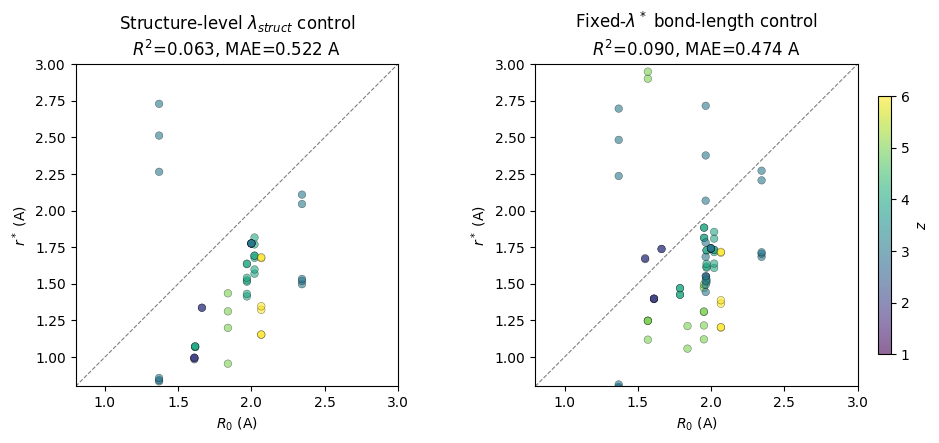

In [18]:
# Fixed-lambda* bond-length control, not a true lambda(R) inference.
#
# This section does NOT fit a radius-dependent screening law. Instead it asks a
# narrower question: if one encodes the same fixed species-level lambda* into
# bond-length-dependent B_j values,
#     B_j = lambda*(lambda* + R_ij) / R_ij,
# does that fixed-lambda control better organize the per-bond O-side TF matches in
# distorted shells than using a single structure-level lambda_struct for every bond?
#
# Because the inversion from B_j back to lambda_j returns the same lambda* by
# construction, this is a consistency/null-model test rather than evidence for a
# nonconstant lambda(R).

multi_bond_data = []

for ox in all_oxides:
    if "bonds_v2" not in ox or ox.get("error") is not None:
        continue
    if len(ox["bonds_v2"]) < 2:
        continue

    lam_star = ox.get("lam_star", np.nan)
    R0_fit = ox["R0_fit"]
    B_fit = ox["B_fit"]
    if not np.isfinite(lam_star) or lam_star <= 0 or B_fit <= 0:
        continue

    bond_results = []
    disc = R0_fit**2 + 4 * B_fit * R0_fit
    lam_struct = (-R0_fit + np.sqrt(disc)) / 2 if disc > 0 else np.nan

    for bond in ox["bonds_v2"]:
        r_ij = bond["r_ij"]
        d, lam_tf = bond["dist"], bond["lam_tf"]

        # Fixed-lambda control: encode the same lambda* into a bond-length-dependent Bj.
        B_j = lam_star * (lam_star + r_ij) / r_ij

        # Inverting Bj returns the same fixed lambda*; retained only to make the
        # control explicit rather than to infer lambda(R).
        disc_j = r_ij**2 + 4 * B_j * r_ij
        lam_j = (-r_ij + np.sqrt(disc_j)) / 2 if disc_j > 0 else np.nan

        # Find O-side matches to both (a) the global structure-level lambda_struct and
        # (b) the fixed-lambda bond-length control.
        interior = (d > r_ij * 0.15) & (d < r_ij * 0.85) & np.isfinite(lam_tf)
        if not interior.any():
            continue
        bcp_r = d[interior][np.argmax(lam_tf[interior])]

        r_cross_global = np.nan
        r_cross_control = np.nan
        diff_g = lam_tf - lam_struct
        diff_l = lam_tf - lam_j

        for i in range(len(d) - 1):
            if d[i] > bcp_r:
                if np.isfinite(diff_g[i]) and np.isfinite(diff_g[i+1]):
                    if diff_g[i] * diff_g[i+1] < 0 and np.isnan(r_cross_global):
                        r_cross_global = d[i] + (d[i+1]-d[i]) * abs(diff_g[i]) / (abs(diff_g[i]) + abs(diff_g[i+1]))
                if np.isfinite(diff_l[i]) and np.isfinite(diff_l[i+1]):
                    if diff_l[i] * diff_l[i+1] < 0 and np.isnan(r_cross_control):
                        r_cross_control = d[i] + (d[i+1]-d[i]) * abs(diff_l[i]) / (abs(diff_l[i]) + abs(diff_l[i+1]))

        bond_results.append({
            "r_ij": r_ij,
            "B_j": B_j,
            "lam_j": lam_j,
            "lam_struct": lam_struct,
            "r_cross_global": r_cross_global,
            "r_cross_control": r_cross_control,
        })

    if len(bond_results) >= 2:
        multi_bond_data.append({
            "element": ox["element"],
            "formula": ox["formula"],
            "z": ox["z"],
            "R0": R0_fit,
            "B_fit": B_fit,
            "lam_star": lam_star,
            "bonds": sorted(bond_results, key=lambda b: b["r_ij"]),
        })

# Print results for structures with significant bond-length spread
print(f"{'Formula':10s} {'Ion':8s} {'R_ij':>5s} {'B_j':>5s} {'lam_j':>5s} "
      f"{'r*_glob':>7s} {'r*_ctl':>6s} {'r*/R0':>5s} {'r*c/R0':>6s}")
print("-" * 70)

for ox in sorted(multi_bond_data, key=lambda x: (x["z"], x["element"])):
    bonds = ox["bonds"]
    spread = bonds[-1]["r_ij"] - bonds[0]["r_ij"]
    if spread < 0.05:
        continue  # skip nearly uniform shells

    for b in bonds:
        ratio_g = b["r_cross_global"] / ox["R0"] if np.isfinite(b["r_cross_global"]) else np.nan
        ratio_c = b["r_cross_control"] / ox["R0"] if np.isfinite(b["r_cross_control"]) else np.nan
        print(f'{ox["formula"]:10s} {ox["element"]}^{ox["z"]}+{"":<3s} '
              f'{b["r_ij"]:5.3f} {b["B_j"]:5.3f} {b["lam_j"]:5.3f} '
              f'{b["r_cross_global"]:7.3f} {b["r_cross_control"]:6.3f} '
              f'{ratio_g:5.2f} {ratio_c:6.2f}')
    B_short = bonds[0]["B_j"]
    B_long = bonds[-1]["B_j"]
    pred_ratio = B_long / B_short
    print(f'  -> spread={spread:.3f} A, B_long/B_short={pred_ratio:.4f} '
          f'(pred {bonds[0]["r_ij"]:.2f}*({ox["lam_star"]:.2f}+{bonds[-1]["r_ij"]:.2f})'
          f'/({bonds[-1]["r_ij"]:.2f}*({ox["lam_star"]:.2f}+{bonds[0]["r_ij"]:.2f})))')
    print()

# Summary: does the fixed-lambda bond-length control improve R0 prediction?
all_global = []
all_R0_global = []
all_z_global = []
all_control = []
all_R0_control = []
all_z_control = []
for ox in multi_bond_data:
    for b in ox["bonds"]:
        if np.isfinite(b["r_cross_global"]):
            all_global.append(b["r_cross_global"])
            all_R0_global.append(ox["R0"])
            all_z_global.append(ox["z"])
        if np.isfinite(b["r_cross_control"]):
            all_control.append(b["r_cross_control"])
            all_R0_control.append(ox["R0"])
            all_z_control.append(ox["z"])

all_global = np.array(all_global)
all_R0_global = np.array(all_R0_global)
all_z_global = np.array(all_z_global)
all_control = np.array(all_control)
all_R0_control = np.array(all_R0_control)
all_z_control = np.array(all_z_control)

if len(all_global) > 3 and len(all_control) > 3:
    r2_g = np.corrcoef(all_R0_global, all_global)[0, 1]**2
    r2_c = np.corrcoef(all_R0_control, all_control)[0, 1]**2
    mae_g = np.mean(np.abs(all_global - all_R0_global))
    mae_c = np.mean(np.abs(all_control - all_R0_control))
    print(f"\nStructure-level lambda_struct control: R2={r2_g:.3f}, MAE={mae_g:.3f} A")
    print(f"Fixed-lambda bond-length control:      R2={r2_c:.3f}, MAE={mae_c:.3f} A")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.5))
    cmap = plt.cm.viridis
    norm_c = plt.Normalize(1, 6)
    lo, hi = 0.8, 3.0

    ax1.plot([lo, hi], [lo, hi], "k--", lw=0.8, alpha=0.5)
    ax1.scatter(all_R0_global, all_global, c=all_z_global, cmap=cmap, norm=norm_c,
                s=30, edgecolors="k", lw=0.3, alpha=0.6)
    ax1.set_title(f"Structure-level $\\lambda_{{struct}}$ control\n$R^2$={r2_g:.3f}, MAE={mae_g:.3f} A")
    ax1.set_xlabel("$R_0$ (A)")
    ax1.set_ylabel("$r^*$ (A)")
    ax1.set_xlim(lo, hi)
    ax1.set_ylim(lo, hi)
    ax1.set_aspect("equal")

    ax2.plot([lo, hi], [lo, hi], "k--", lw=0.8, alpha=0.5)
    sc = ax2.scatter(all_R0_control, all_control, c=all_z_control, cmap=cmap, norm=norm_c,
                     s=30, edgecolors="k", lw=0.3, alpha=0.6)
    ax2.set_title(f"Fixed-$\\lambda^*$ bond-length control\n$R^2$={r2_c:.3f}, MAE={mae_c:.3f} A")
    ax2.set_xlabel("$R_0$ (A)")
    ax2.set_ylabel("$r^*$ (A)")
    ax2.set_xlim(lo, hi)
    ax2.set_ylim(lo, hi)
    ax2.set_aspect("equal")
    plt.colorbar(sc, ax=ax2, label="$z$", shrink=0.8)

    plt.tight_layout()
    plt.savefig("../docs/theory/figures/thomas_fermi_variable_B.png",
                dpi=200, bbox_inches="tight")
    plt.show()


El    Z Formula  flag    R_MO   R0*    B*  lam*  R0fit   Bfit    r* r*/R0*
---------------------------------------------------------------------------
La   57 La2O3    ok     2.369 2.171 0.404 0.348  1.963  0.692 1.846   0.85
Ce   58 CeO2     B<0    2.367 2.142 0.360 0.314  2.526 -0.229 1.824   0.85
Pr   59 Pr2O3    no_fit 2.344 2.112 0.427 0.364    nan    nan 1.756   0.83
Nd   60 Nd2O3    B<0    2.374 2.307 0.207 0.191 13.220 -15.570   nan    nan
Sm   62 Sm2O3    B<0    2.369 1.971 0.522 0.429  6.062 -5.303   nan    nan
Eu   63 EuO      no_fit 2.542 2.088 0.396 0.340    nan    nan 1.900   0.91
Gd   64 Gd2O3    ok     2.253 1.784 0.688 0.530  1.906  0.634   nan    nan
Tb   65 Tb2O3    no_fit 2.227 1.862 0.598 0.476    nan    nan   nan    nan
Dy   66 Dy2O3    B<0    2.265 1.938 0.486 0.403  3.301 -1.431 1.386   0.72
Ho   67 Ho2O3    no_fit 2.197 1.967 0.444 0.373    nan    nan 1.580   0.80
Er   68 Er2O3    B<0    2.237 1.854 0.564 0.453  2.613 -0.479   nan    nan
Tm   69 Tm2O3    no_fit

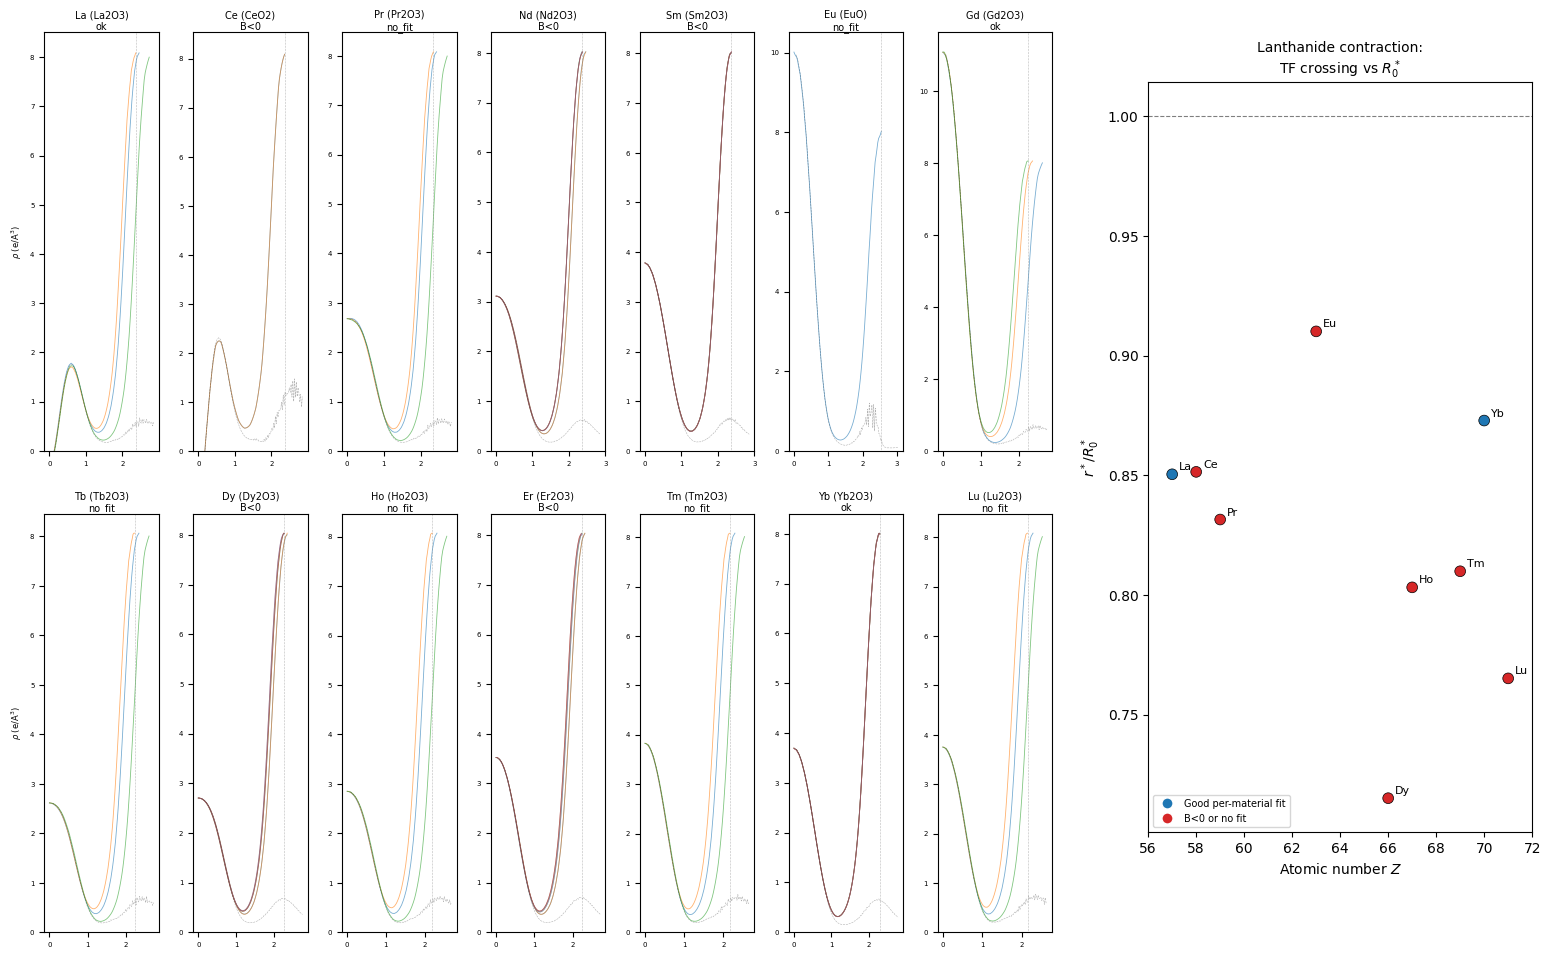


Lanthanide r*/R0*: mean=0.82 +/- 0.06
  Range: [0.72, 0.91]


In [19]:
# Full lanthanide analysis: TF screening across the 4f series
# Use species-level (R0*, B*) from the master summary for lambda*
# Include structures with negative per-material B — these are real data

import json as _json

with open("../data/processed/theory/master_oxygen_summary_theory.json") as f:
    master = _json.load(f)

# Build lanthanide dataset: combine oxide CSV structures + new A-type structures
lanthanide_oxides = [
    # From oxide_free_energy_comparison CSV (existing)
    {"element": "La", "formula": "La2O3", "mpid": "mp-1968",  "z": 3, "R0_fit": 1.963, "B_fit": 0.692},
    {"element": "Ce", "formula": "CeO2",  "mpid": "mp-20194", "z": 4, "R0_fit": 2.526, "B_fit": -0.229},
    {"element": "Nd", "formula": "Nd2O3", "mpid": "mp-1045",  "z": 3, "R0_fit": 13.22, "B_fit": -15.57},
    {"element": "Sm", "formula": "Sm2O3", "mpid": "mp-218",   "z": 3, "R0_fit": 6.062, "B_fit": -5.303},
    {"element": "Gd", "formula": "Gd2O3", "mpid": "mp-20470", "z": 3, "R0_fit": 1.906, "B_fit": 0.634},
    {"element": "Dy", "formula": "Dy2O3", "mpid": "mp-2345",  "z": 3, "R0_fit": 3.301, "B_fit": -1.431},
    {"element": "Er", "formula": "Er2O3", "mpid": "mp-679",   "z": 3, "R0_fit": 2.613, "B_fit": -0.479},
    {"element": "Yb", "formula": "Yb2O3", "mpid": "mp-2814",  "z": 3, "R0_fit": 2.000, "B_fit": 0.362},
    # New A-type structures (missing from CSV)
    {"element": "Pr", "formula": "Pr2O3", "mpid": "mp-2063",  "z": 3, "R0_fit": None, "B_fit": None},
    {"element": "Eu", "formula": "EuO",   "mpid": "mp-21394", "z": 2, "R0_fit": None, "B_fit": None},
    {"element": "Tb", "formula": "Tb2O3", "mpid": "mp-13063", "z": 3, "R0_fit": None, "B_fit": None},
    {"element": "Ho", "formula": "Ho2O3", "mpid": "mp-13065", "z": 3, "R0_fit": None, "B_fit": None},
    {"element": "Tm", "formula": "Tm2O3", "mpid": "mp-13067", "z": 3, "R0_fit": None, "B_fit": None},
    {"element": "Lu", "formula": "Lu2O3", "mpid": "mp-13068", "z": 3, "R0_fit": None, "B_fit": None},
]

# Attach species-level (R0*, B*, lambda*) from master summary
lant_rows = {r["element"]: r for r in master["families"]["lanthanides"]["rows"]}
for ox in lanthanide_oxides:
    mr = lant_rows.get(ox["element"])
    if mr:
        ox["R0_star"] = mr["R0_star"]
        ox["B_star"] = mr["B_star"]
        ox["lam_star"] = fitted_lambda_star(mr["R0_star"], mr["B_star"])
    else:
        ox["R0_star"] = ox["B_star"] = ox["lam_star"] = np.nan

    # Flag fit quality
    B = ox["B_fit"]
    if B is None:
        ox["fit_flag"] = "no_fit"
    elif B < 0:
        ox["fit_flag"] = "B<0"
    elif abs(B - 0.37) < 0.001:
        ox["fit_flag"] = "B=0.37"
    else:
        ox["fit_flag"] = "ok"

# Download charge densities and compute profiles + bond paths
with MPRester(API_KEY) as mpr:
    for ox in lanthanide_oxides:
        chgcar = get_chgcar_cached(mpr, ox["mpid"])
        if chgcar is None:
            ox["error"] = "no CHGCAR"
            continue

        struct = chgcar.structure
        try:
            cat_idx = next(i for i, s in enumerate(struct)
                          if ox["element"] in s.species_string)
        except StopIteration:
            ox["error"] = "cation not found"
            continue

        # Shortest M-O distance
        r_mo = min(struct.get_distance(cat_idx, j)
                   for j in range(len(struct))
                   if "O" in struct[j].species_string)
        ox["r_bar"] = r_mo

        # Lambda from per-material fit (even if B < 0)
        R0f = ox["R0_fit"]
        Bf = ox["B_fit"]
        if R0f is not None and Bf is not None and R0f > 0 and Bf > 0:
            disc = R0f**2 + 4 * Bf * R0f
            ox["lam_material"] = (-R0f + np.sqrt(disc)) / 2
        else:
            ox["lam_material"] = np.nan

        # Lambda from species-level (R0*, B*)
        # Use B^eff = lam*(lam* + R_bar)/R_bar for this structure
        lam_s = ox["lam_star"]
        if np.isfinite(lam_s):
            ox["B_from_star"] = lam_s * (lam_s + r_mo) / r_mo
            disc2 = r_mo**2 + 4 * ox["B_from_star"] * r_mo
            ox["lam_from_star"] = (-r_mo + np.sqrt(disc2)) / 2
        else:
            ox["B_from_star"] = ox["lam_from_star"] = np.nan

        # Spherical radial profile
        r, rho, cts = radial_charge_profile(chgcar, cat_idx,
                                             r_max=r_mo + 0.5, n_bins=120)
        ox["r_profile"] = r
        ox["rho_profile"] = rho
        ox["counts_profile"] = cts
        ox["lam_tf_profile"] = np.array([thomas_fermi_lambda(rr) for rr in rho])

        # Bond paths (corrected min-image)
        bonds = []
        for j in range(len(struct)):
            if "O" not in struct[j].species_string:
                continue
            r_ij = struct.get_distance(cat_idx, j)
            if r_ij > 3.5:
                continue
            dist, rho_bp, r_total = sample_density_along_bond_v2(chgcar, cat_idx, j, n_pts=100)
            lam_tf_bp = np.array([thomas_fermi_lambda(rr) for rr in rho_bp])
            bonds.append({"r_ij": r_ij, "dist": dist, "rho": rho_bp, "lam_tf": lam_tf_bp})
        ox["bonds"] = bonds

        # Find crossings using lambda from species-level
        lam_target = ox["lam_from_star"]
        crossings = []
        for bond in bonds:
            d, lam_tf = bond["dist"], bond["lam_tf"]
            r_ij = bond["r_ij"]
            interior = (d > r_ij * 0.15) & (d < r_ij * 0.85) & np.isfinite(lam_tf)
            if not interior.any():
                continue
            bcp_r = d[interior][np.argmax(lam_tf[interior])]
            diff = lam_tf - lam_target
            for i in range(len(diff) - 1):
                if d[i] > bcp_r and np.isfinite(diff[i]) and np.isfinite(diff[i+1]):
                    if diff[i] * diff[i+1] < 0:
                        rc = d[i] + (d[i+1]-d[i]) * abs(diff[i]) / (abs(diff[i])+abs(diff[i+1]))
                        crossings.append(rc)
                        break

        ox["r_star"] = np.mean(crossings) if crossings else np.nan
        ox["error"] = None

# Print results
Z_MAP = {"La":57,"Ce":58,"Pr":59,"Nd":60,"Pm":61,"Sm":62,"Eu":63,
         "Gd":64,"Tb":65,"Dy":66,"Ho":67,"Er":68,"Tm":69,"Yb":70,"Lu":71}

print(f'{"El":3s} {"Z":>3s} {"Formula":8s} {"flag":6s} {"R_MO":>5s} '
      f'{"R0*":>5s} {"B*":>5s} {"lam*":>5s} '
      f'{"R0fit":>6s} {"Bfit":>6s} '
      f'{"r*":>5s} {"r*/R0*":>6s}')
print("-" * 75)
for ox in sorted(lanthanide_oxides, key=lambda x: Z_MAP.get(x["element"], 99)):
    if ox.get("error"):
        print(f'{ox["element"]:3s} {Z_MAP[ox["element"]]:3d} {ox["formula"]:8s} {ox.get("error","?")}')
        continue
    r_star = ox.get("r_star", np.nan)
    ratio = r_star / ox["R0_star"] if np.isfinite(r_star) else np.nan
    R0f = ox["R0_fit"] if ox["R0_fit"] is not None else np.nan
    Bf = ox["B_fit"] if ox["B_fit"] is not None else np.nan
    print(f'{ox["element"]:3s} {Z_MAP[ox["element"]]:3d} {ox["formula"]:8s} {ox["fit_flag"]:6s} '
          f'{ox["r_bar"]:5.3f} '
          f'{ox["R0_star"]:5.3f} {ox["B_star"]:5.3f} {ox["lam_star"]:5.3f} '
          f'{R0f:6.3f} {Bf:6.3f} '
          f'{r_star:5.3f} {ratio:6.2f}')

# Plot: two panels
# Left: radial profiles for all 14 (2 rows: rho + lambda_TF)
# Right: r*/R0* vs atomic number across the lanthanide contraction
fig = plt.figure(figsize=(16, 10))

# Top: bond-path profiles
ax_grid = fig.add_gridspec(2, 7, left=0.05, right=0.68, hspace=0.15, wspace=0.3,
                            top=0.95, bottom=0.05)

sorted_lant = sorted([ox for ox in lanthanide_oxides if ox.get("error") is None],
                      key=lambda x: Z_MAP[x["element"]])

for idx, ox in enumerate(sorted_lant[:14]):
    row = idx // 7
    col = idx % 7
    ax = fig.add_subplot(ax_grid[row, col])

    # Plot bond paths
    for bond in ox["bonds"]:
        ax.plot(bond["dist"], bond["rho"], lw=0.6, alpha=0.6)
    # Spherical avg
    m = ox["counts_profile"] > 5
    ax.plot(ox["r_profile"][m], ox["rho_profile"][m], "k--", lw=0.4, alpha=0.3)
    ax.axvline(ox["r_bar"], color="gray", ls=":", lw=0.4)
    ax.set_title(f'{ox["element"]} ({ox["formula"]})\n{ox["fit_flag"]}', fontsize=7, pad=2)
    ax.set_ylim(bottom=0, top=min(12, ax.get_ylim()[1]))
    ax.tick_params(labelsize=5)
    if col == 0:
        ax.set_ylabel(r"$\rho$ (e/A$^3$)", fontsize=6)

# Right: r*/R0* across lanthanide contraction
ax_right = fig.add_axes([0.74, 0.15, 0.24, 0.75])

z_nums = []
ratios = []
r0_stars = []
labels_ln = []
colors_ln = []

for ox in sorted_lant:
    r_star = ox.get("r_star", np.nan)
    if np.isfinite(r_star):
        z_num = Z_MAP[ox["element"]]
        ratio = r_star / ox["R0_star"]
        z_nums.append(z_num)
        ratios.append(ratio)
        r0_stars.append(ox["R0_star"])
        labels_ln.append(ox["element"])
        colors_ln.append("C3" if ox["fit_flag"] in ("B<0", "no_fit") else "C0")

ax_right.scatter(z_nums, ratios, c=colors_ln, s=60, edgecolors="k", lw=0.5, zorder=5)
for i, lbl in enumerate(labels_ln):
    ax_right.annotate(lbl, (z_nums[i], ratios[i]),
                      textcoords="offset points", xytext=(5, 3), fontsize=8)
ax_right.axhline(1.0, color="k", ls="--", lw=0.8, alpha=0.5)
ax_right.set_xlabel("Atomic number $Z$", fontsize=10)
ax_right.set_ylabel("$r^* / R_0^*$", fontsize=10)
ax_right.set_title("Lanthanide contraction:\nTF crossing vs $R_0^*$", fontsize=10)
ax_right.set_xlim(56, 72)

# Legend
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor='C0',
                          markersize=8, label='Good per-material fit'),
                   Line2D([0], [0], marker='o', color='w', markerfacecolor='C3',
                          markersize=8, label='B<0 or no fit')]
ax_right.legend(handles=legend_elements, fontsize=7, loc="lower left")

plt.savefig("../docs/theory/figures/thomas_fermi_lanthanides.png",
            dpi=200, bbox_inches="tight")
plt.show()

# Summary stats
ratios_arr = np.array(ratios)
print(f"\nLanthanide r*/R0*: mean={np.mean(ratios_arr):.2f} +/- {np.std(ratios_arr):.2f}")
print(f"  Range: [{np.min(ratios_arr):.2f}, {np.max(ratios_arr):.2f}]")


Formula    Ion       z    m_i  r_eff r_eff/m_i status 
----------------------------------------------------------
Cs2O       Cs^1+     1  2.893  2.480    0.857 Group 1
K2O        K^1+     1  2.809  2.395    0.852 Group 1
Li2O       Li^1+     1  2.017  1.649    0.817 Group 1
Na2O       Na^1+     1  2.423  2.027    0.837 Group 1
Rb2O       Rb^1+     1  2.978  2.553    0.857 Group 1
BaO        Ba^2+     2  2.807  2.401    0.855 Group 2
BeO        Be^2+     2  1.656  1.321    0.798 Group 2
CaO        Ca^2+     2  2.420  2.036    0.842 Group 2
MgO        Mg^2+     2  2.128  1.754    0.824 Group 2
SrO        Sr^2+     2  2.603  2.208    0.848 Group 2
Ag2O       Ag^1+     1  2.096  1.746    0.833 Other  
CoO        Co^2+     2  1.991  1.642    0.825 Other  
CuO        Cu^2+     2  1.955  1.610    0.824 Other  
NiO        Ni^2+     2  2.108  1.750    0.830 Other  
PbO        Pb^2+     2  2.354  1.985    0.843 Other  
PdO        Pd^2+     2  2.061  1.711    0.830 Other  
ZnO        Zn^2+     2 

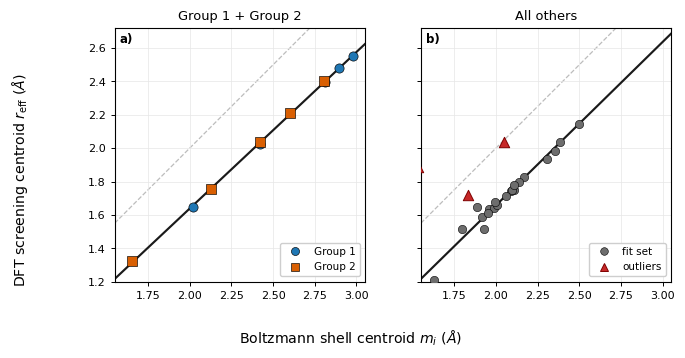

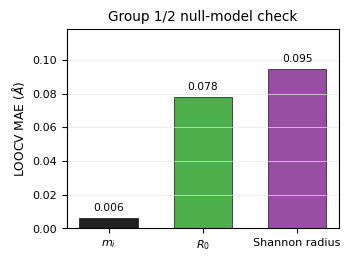

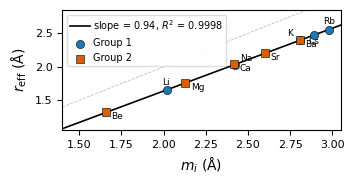

In [20]:
# Canonical-oxide screening-centroid figures for PRL and SI
# Build the manuscript panels here first, then export the rendered assets.
# Panel b includes all valid species; B, P, As, and Au are shown as explicit outliers.

import csv
import pickle
from pathlib import Path
from matplotlib.lines import Line2D
from pymatgen.io.vasp.outputs import Chgcar  # noqa: F401 - needed for pickle loads

CANONICAL_TABLE = Path("../data/processed/thermodynamics/canonical_oxide_mid_table.csv")
CHGCAR_CACHE = Path("../data/cache/chgcar")
GROUP1 = {"Li", "Na", "K", "Rb", "Cs"}
GROUP2 = {"Be", "Mg", "Ca", "Sr", "Ba"}
DROP_ELEMENTS = set()
OUTLIER_ELEMENTS = {"B", "P", "As", "Au"}
SHANNON_RADII = {
    "Li": 0.76,
    "Na": 1.02,
    "K": 1.38,
    "Rb": 1.52,
    "Cs": 1.67,
    "Be": 0.45,
    "Mg": 0.72,
    "Ca": 1.00,
    "Sr": 1.18,
    "Ba": 1.35,
}


def boltzmann_centroid(bond_lengths, b_value):
    """Compute the bond-valence shell centroid m_i."""
    if b_value <= 0 or len(bond_lengths) == 0:
        return np.nan
    distances = np.asarray(bond_lengths, dtype=float)
    log_w = -distances / float(b_value)
    log_w -= np.max(log_w)
    weights = np.exp(log_w)
    weights /= np.sum(weights)
    return float(np.sum(weights * distances))


def oxygen_side_path_centroid(dist, rho, r_ij):
    """Return the oxygen-side screening centroid and inward oxygen shift."""
    lam_tf = np.array([thomas_fermi_lambda(rr) for rr in rho], dtype=float)
    interior = (dist > r_ij * 0.15) & (dist < r_ij * 0.85) & np.isfinite(rho)
    if not interior.any():
        return np.nan, np.nan
    idx_min = np.argmin(rho[interior])
    bcp_r = float(dist[interior][idx_min])
    bcp_rho = float(rho[interior][idx_min])
    stop = min(r_ij * 0.93, float(dist[-1]))

    mask = (
        np.isfinite(dist)
        & np.isfinite(rho)
        & np.isfinite(lam_tf)
        & (lam_tf > 0)
        & (dist >= bcp_r)
        & (dist <= stop)
    )
    if mask.sum() < 2:
        return np.nan, np.nan

    d = dist[mask]
    dens = rho[mask]
    weights = np.clip(dens - bcp_rho, 0.0, None)
    if np.sum(weights) <= 0.0:
        weights = dens.copy()
    if np.sum(weights) <= 0.0:
        return np.nan, np.nan

    r_eff = float(np.sum(weights * d) / np.sum(weights))
    oxygen_shift = float(r_ij - r_eff)
    return r_eff, oxygen_shift


def fit_line(xs, ys):
    slope, intercept = np.polyfit(xs, ys, 1)
    r2 = float(np.corrcoef(xs, ys)[0, 1] ** 2)
    return float(slope), float(intercept), r2


def loocv_mae(xs, ys):
    preds = np.zeros_like(ys)
    for idx in range(len(xs)):
        mask = np.ones(len(xs), dtype=bool)
        mask[idx] = False
        slope, intercept = np.polyfit(xs[mask], ys[mask], 1)
        preds[idx] = slope * xs[idx] + intercept
    return float(np.mean(np.abs(ys - preds)))


def load_screening_centroid_points():
    with CANONICAL_TABLE.open() as handle:
        canonical_rows = list(csv.DictReader(handle))

    points = []
    for row in canonical_rows:
        if row.get("selected_status") != "fitted":
            continue
        if not row.get("selected_mid") or not row.get("selected_cn"):
            continue

        element = str(row["element"])
        if element in DROP_ELEMENTS:
            continue

        try:
            r0 = float(row["selected_R0"])
            b_value = float(row["selected_B"])
            z = int(float(row["selected_oxi_state"]))
            cn = int(float(row["selected_cn"]))
        except (TypeError, ValueError):
            continue
        if r0 <= 0 or b_value <= 0:
            continue

        cache_file = CHGCAR_CACHE / f"{row['selected_mid']}.pkl"
        if not cache_file.exists():
            continue
        with cache_file.open("rb") as handle:
            chgcar = pickle.load(handle)

        struct = chgcar.structure
        try:
            cat_idx = next(idx for idx, site in enumerate(struct) if element in site.species_string)
        except StopIteration:
            continue

        shell_lengths = collect_oxygen_shell(struct, cat_idx, cn)
        if not shell_lengths:
            continue
        m_i = boltzmann_centroid(shell_lengths, b_value)
        if not np.isfinite(m_i):
            continue

        r_eff_values = []
        oxygen_shift_values = []
        for site_j, site in enumerate(struct):
            if "O" not in site.species_string:
                continue
            r_ij = float(struct.get_distance(cat_idx, site_j))
            if r_ij > 3.5:
                continue
            dist, rho, _ = sample_density_along_bond_v2(chgcar, cat_idx, site_j, n_pts=200)
            r_eff_path, oxygen_shift_path = oxygen_side_path_centroid(dist, rho, r_ij)
            if np.isfinite(r_eff_path):
                r_eff_values.append(r_eff_path)
                oxygen_shift_values.append(oxygen_shift_path)

        if not r_eff_values:
            continue

        family = "Other"
        if element in GROUP1:
            family = "Group 1"
        elif element in GROUP2:
            family = "Group 2"

        points.append({
            "formula": str(row["oxide_formula"]),
            "element": element,
            "z": z,
            "family": family,
            "m_i": float(m_i),
            "r_eff": float(np.mean(r_eff_values)),
            "R0": r0,
            "B": b_value,
            "shannon_radius": float(SHANNON_RADII.get(element, np.nan)),
            "oxygen_shift": float(np.mean(oxygen_shift_values)),
        })

    return points


reff_data = load_screening_centroid_points()

m_arr = np.array([d["m_i"] for d in reff_data], dtype=float)
reff_arr = np.array([d["r_eff"] for d in reff_data], dtype=float)
r0_arr = np.array([d["R0"] for d in reff_data], dtype=float)
shift_arr = np.array([d["oxygen_shift"] for d in reff_data], dtype=float)
shannon_arr = np.array([d["shannon_radius"] for d in reff_data], dtype=float)
els = [d["element"] for d in reff_data]
labs = [f'{d["element"]}$^{{{d["z"]}+}}$' for d in reff_data]

finite = np.isfinite(m_arr) & np.isfinite(reff_arr)
g1 = np.array([d["family"] == "Group 1" for d in reff_data], dtype=bool)
g2 = np.array([d["family"] == "Group 2" for d in reff_data], dtype=bool)
sblock_mask = g1 | g2
other_mask = np.array([d["family"] == "Other" for d in reff_data], dtype=bool)
outlier_mask = np.array([d["element"] in OUTLIER_ELEMENTS for d in reff_data], dtype=bool)
other_fit_mask = other_mask & (~outlier_mask) & finite
outlier_plot = other_mask & outlier_mask & finite

print(f'{"Formula":10s} {"Ion":8s} {"z":>2s} {"m_i":>6s} {"r_eff":>6s} {"r_eff/m_i":>8s} {"status":7s}')
print("-" * 58)
for d in sorted(reff_data, key=lambda x: (x["family"], x["z"], x["element"])):
    ratio = d["r_eff"] / d["m_i"] if d["m_i"] > 0 else np.nan
    status = "OUTLIER" if d["element"] in OUTLIER_ELEMENTS else d["family"]
    print(
        f'{d["formula"]:10s} {d["element"]}^{d["z"]}+{"":<3s} {d["z"]:2d} '
        f'{d["m_i"]:6.3f} {d["r_eff"]:6.3f} {ratio:8.3f} {status:7s}'
    )

sblock_slope, sblock_intercept, sblock_r2 = fit_line(m_arr[sblock_mask], reff_arr[sblock_mask])
other_slope, other_intercept, other_r2 = fit_line(m_arr[other_fit_mask], reff_arr[other_fit_mask])
shift_slope, shift_intercept, shift_r2 = fit_line(m_arr[sblock_mask], shift_arr[sblock_mask])
mean_shift = float(np.mean(shift_arr[sblock_mask]))
std_shift = float(np.std(shift_arr[sblock_mask], ddof=1))

mae_mi = loocv_mae(m_arr[sblock_mask], reff_arr[sblock_mask])
mae_r0 = loocv_mae(r0_arr[sblock_mask], reff_arr[sblock_mask])
mae_shannon = loocv_mae(shannon_arr[sblock_mask], reff_arr[sblock_mask])

print(f"\nPanel a (Group 1/2): r_eff = {sblock_slope:.4f} * m_i + ({sblock_intercept:.4f}), R^2 = {sblock_r2:.6f}")
print(f"Panel a oxygen shift: Delta_O = {shift_slope:.4f} * m_i + ({shift_intercept:.4f}), R^2 = {shift_r2:.6f}")
print(f"Panel a mean shift: {mean_shift:.4f} +/- {std_shift:.4f} A")
print(f"Panel b (all others; B/P/As/Au excluded): r_eff = {other_slope:.4f} * m_i + ({other_intercept:.4f}), R^2 = {other_r2:.6f}")
print(f"Panel a LOOCV MAE: m_i = {mae_mi:.4f} A, R0 = {mae_r0:.4f} A, Shannon = {mae_shannon:.4f} A")

main_rc = {
    "font.size": 8.5,
    "axes.labelsize": 9.2,
    "axes.titlesize": 9.4,
    "xtick.labelsize": 8.0,
    "ytick.labelsize": 8.0,
    "legend.fontsize": 7.5,
}

with plt.rc_context(main_rc):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.1, 3.5), sharex=True, sharey=True)
    lo, hi = 1.55, 3.05
    fit_x = np.linspace(lo, hi, 200)

    for ax in (ax1, ax2):
        ax.plot([lo, hi], [lo, hi], "--", color="0.65", lw=0.9, alpha=0.75, zorder=1)
        ax.set_xlim(lo, hi)
        ax.set_ylim(1.20, 2.72)
        ax.set_aspect("equal")
        ax.grid(True, color="0.90", linewidth=0.5)
        ax.tick_params(direction="out", length=3.0, width=0.7)

    ax1.text(0.02, 0.98, "a)", transform=ax1.transAxes, ha="left", va="top", fontweight="bold")
    ax2.text(0.02, 0.98, "b)", transform=ax2.transAxes, ha="left", va="top", fontweight="bold")

    ax1.plot(fit_x, sblock_slope * fit_x + sblock_intercept, color="0.10", lw=1.55, zorder=2)
    ax1.scatter(m_arr[g1], reff_arr[g1], s=44, marker="o", c="#1f77b4", edgecolors="black", linewidths=0.45, zorder=4)
    ax1.scatter(m_arr[g2], reff_arr[g2], s=48, marker="s", c="#d95f02", edgecolors="black", linewidths=0.45, zorder=4)

    ax1.legend(
        handles=[
            Line2D([0], [0], marker="o", linestyle="None", markerfacecolor="#1f77b4", markeredgecolor="black", markeredgewidth=0.45, markersize=5.8, label="Group 1"),
            Line2D([0], [0], marker="s", linestyle="None", markerfacecolor="#d95f02", markeredgecolor="black", markeredgewidth=0.45, markersize=6.0, label="Group 2"),
        ],
        loc="lower right",
        frameon=True,
        framealpha=0.95,
        edgecolor="0.80",
    )
    ax1.set_title("Group 1 + Group 2")

    ax2.plot(fit_x, other_slope * fit_x + other_intercept, color="0.10", lw=1.55, zorder=2)
    ax2.scatter(m_arr[other_fit_mask], reff_arr[other_fit_mask], s=36, marker="o", c="#6d6d6d", edgecolors="black", linewidths=0.40, zorder=4)
    ax2.scatter(m_arr[outlier_plot], reff_arr[outlier_plot], s=56, marker="^", facecolors="#c62828", edgecolors="#7f0000", linewidths=0.70, zorder=5)
    ax2.legend(
        handles=[
            Line2D([0], [0], marker="o", linestyle="None", markerfacecolor="#6d6d6d", markeredgecolor="black", markeredgewidth=0.40, markersize=5.5, label="fit set"),
            Line2D([0], [0], marker="^", linestyle="None", markerfacecolor="#c62828", markeredgecolor="#7f0000", markeredgewidth=0.70, markersize=6.0, label="outliers"),
        ],
        loc="lower right",
        frameon=True,
        framealpha=0.95,
        edgecolor="0.80",
    )
    ax2.set_title("All others")

    fig.supxlabel(r"Boltzmann shell centroid $m_i$ ($\AA$)", y=0.02)
    fig.supylabel(r"DFT screening centroid $r_{\rm eff}$ ($\AA$)", x=0.02)
    fig.tight_layout(rect=(0.04, 0.05, 1.0, 1.0), w_pad=1.0)

    fig.savefig("../docs/theory/figures/thomas_fermi_reff_vs_mi.png", dpi=240, bbox_inches="tight")
    fig.savefig("../docs/theory/figures/thomas_fermi_reff_prl.png", dpi=300, bbox_inches="tight", pad_inches=0.02)
    plt.show()

with plt.rc_context({"font.size": 8.2, "axes.labelsize": 8.8, "xtick.labelsize": 8.0, "ytick.labelsize": 8.0}):
    fig_si, ax_si = plt.subplots(figsize=(3.4, 2.5))
    metric_labels = [r"$m_i$", r"$R_0$", "Shannon radius"]
    metric_values = [mae_mi, mae_r0, mae_shannon]
    metric_colors = ["#202020", "#4daf4a", "#984ea3"]
    bars = ax_si.bar(metric_labels, metric_values, color=metric_colors, edgecolor="black", linewidth=0.45, width=0.62)
    for bar, value in zip(bars, metric_values):
        ax_si.text(bar.get_x() + bar.get_width() / 2, value + 0.003, f"{value:.3f}", ha="center", va="bottom", fontsize=7.7)
    ax_si.set_ylabel(r"LOOCV MAE ($\AA$)")
    ax_si.set_title("Group 1/2 null-model check")
    ax_si.set_ylim(0.0, max(metric_values) * 1.25)
    ax_si.grid(axis="y", color="0.90", linewidth=0.5)
    fig_si.tight_layout(pad=0.35)
    fig_si.savefig("../docs/theory/figures/thomas_fermi_reff_null_models_si.png", dpi=300, bbox_inches="tight", pad_inches=0.02)
    plt.show()

# PRL Figure 2: 1:2 height:width, symbol-only axis labels
with plt.rc_context({"font.size": 9, "axes.labelsize": 10, "legend.fontsize": 7,
                      "xtick.labelsize": 8, "ytick.labelsize": 8}):
    fig_prb, ax = plt.subplots(figsize=(3.4, 1.7))
    fit_x = np.linspace(1.35, 3.05, 100)
    ax.plot([1.35, 3.05], [1.35, 3.05], color="0.75", ls="--", lw=0.6)
    ax.plot(fit_x, sblock_slope * fit_x + sblock_intercept, color="black", lw=1.2,
            label=f"slope = {sblock_slope:.2f}, $R^2$ = {sblock_r2:.4f}")
    ax.scatter(m_arr[g1], reff_arr[g1], c="#1f77b4", s=35, edgecolors="k", lw=0.4,
               zorder=5, label="Group 1", clip_on=False)
    ax.scatter(m_arr[g2], reff_arr[g2], c="#d95f02", s=35, edgecolors="k", lw=0.4,
               zorder=5, marker="s", label="Group 2", clip_on=False)
    label_offsets = {
        "Be": (4, -5), "Li": (-3, 4), "Mg": (4, -5), "Ca": (4, -5), "Na": (4, 3),
        "Sr": (4, -5), "K": (-9, 3), "Ba": (4, -5), "Rb": (-4, 4), "Cs": (-4, -7),
    }
    for idx, element in enumerate(els):
        if not (g1[idx] or g2[idx]):
            continue
        dx, dy = label_offsets.get(element, (4, 3))
        ax.annotate(element, (m_arr[idx], reff_arr[idx]),
                    textcoords="offset points", xytext=(dx, dy), fontsize=6.5, clip_on=True)
    ax.set_xlabel(r"$m_i$ ($\mathrm{\AA}$)")
    ax.set_ylabel(r"$r_{\mathrm{eff}}$ ($\mathrm{\AA}$)")
    ax.set_xlim(1.4, 3.05)
    ax.set_ylim(1.05, 2.85)
    ax.legend(loc="upper left", frameon=True, framealpha=0.9, edgecolor="0.85",
              handletextpad=0.3, borderpad=0.3)
    fig_prb.tight_layout(pad=0.2)
    fig_prb.savefig("../docs/theory/figures/thomas_fermi_reff_group12_prb.png",
                    dpi=300, bbox_inches="tight", pad_inches=0.02)
    plt.show()


### PRL Figure 2 layout notes (2026-04-26)

The production figure is generated by `scripts/make_group12_reff_prb_figure.py`.
Current layout decisions for the compact PRL two-column format:

- **Half-height panels**: `panel_height_ratio=0.55` with no `set_aspect("equal")`
  constraint, giving landscape-oriented panels.
- **No boxed fit summaries**: regression equations and R² reported in the main
  text only; annotation boxes removed to reduce clutter.
- **Legends in lower-right corners** so they do not occlude the **a)** / **b)**
  panel letters.
- **All four outliers shown in panel b**: B³⁺, P⁵⁺, As³⁺, and Au³⁺ plotted as
  open red diamonds and excluded from the panel-b regression.  Previously B and
  P were dropped entirely; they are now retained as explicit outlier markers.
- **No shift curve in panel a**: the brown dashed
  `r_eff = m_i − ⟨Δ_O,val⟩` line removed for compactness.
- **Null-model inset removed**: the LOOCV MAE bar chart is in SI Fig. S4.
- **Short axis labels**: `m_i (Å)` and `r_eff (Å)` instead of full descriptors.